# 📖 Bölüm 1: Chatbot Nedir ve Nasıl Çalışır?

<div style="background-color: #f0f7ff; border-left: 5px solid #2196F3; padding: 20px; margin: 20px 0; border-radius: 5px;">
    <h3>💡 Temel Kavram</h3>
    <p><strong>Chatbot</strong>, kullanıcılarla doğal dilde iletişim kurabilen yapay zeka destekli bir programdır. Modern chatbot'lar, büyük dil modelleri (LLM - Large Language Models) kullanarak insan benzeri konuşmalar yapabilir.</p>
</div>

## 🔍 Chatbot Türleri

| Tür | Açıklama | Örnek Kullanım |
|-----|----------|----------------|
| **🎯 Kural Tabanlı** | Önceden tanımlı kurallar ve kalıplar | FAQ botları |
| **🧠 AI Tabanlı** | Makine öğrenimi ve dil modelleri | Müşteri desteği |
| **🎭 Retrieval-Based** | Hazır cevap veritabanı | Basit soru-cevap |
| **🚀 Generative** | Dinamik cevap üretimi | ChatGPT, Claude |

---

## 🏗️ Chatbot Mimarisi

```
┌─────────────┐
│  Kullanıcı  │
└──────┬──────┘
       │ Mesaj
       ▼
┌─────────────────────┐
│  Input Processing   │ ← Mesaj işleme
└──────────┬──────────┘
           │
           ▼
┌─────────────────────┐
│   Context Manager   │ ← Geçmiş konuşmalar
└──────────┬──────────┘
           │
           ▼
┌─────────────────────┐
│    LLM (GPT-4)      │ ← Cevap üretimi
└──────────┬──────────┘
           │
           ▼
┌─────────────────────┐
│ Output Formatting   │ ← Cevap formatı
└──────────┬──────────┘
           │ Cevap
           ▼
      ┌─────────────┐
      │  Kullanıcı  │
      └─────────────┘
```

---

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 25px; border-radius: 15px; color: white; margin: 30px 0;">
    <h2 style="margin: 0;">🎴 Flashcard #1: API Nedir?</h2>
    <hr style="border: 1px solid rgba(255,255,255,0.3);">
    <p style="font-size: 1.1em; line-height: 1.6;">
        <strong>API (Application Programming Interface)</strong>, farklı yazılımların birbirleriyle iletişim kurmasını sağlayan bir arayüzdür. OpenAI API'si, GPT modellerine HTTP istekleri göndererek chatbot özellikleri eklememizi sağlar.
    </p>
    <p style="margin-top: 15px;"><strong>🔑 Anahtar Nokta:</strong> API key'inizi <strong>GİZLİ</strong> tutun ve GitHub'a yüklemeyin!</p>
</div>

## 📦 Gerekli Kütüphanelerin Kurulumu

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; margin: 15px 0; border-radius: 5px;">
    <h4>⚠️ Önemli Not</h4>
    <p>Bu notebook'u çalıştırmadan önce aşağıdaki kütüphaneleri kurmanız gerekmektedir.</p>
</div>

In [1]:
# Gerekli kütüphanelerin kurulumu
# Not: Eğer kurulu değilse, ! işareti ile pip komutlarını çalıştırın

!pip install openai==1.12.0        # OpenAI API istemcisi
!pip install python-dotenv==1.0.0  # Güvenli API key yönetimi
!pip install pandas==2.1.4         # Veri işleme
!pip install numpy==1.26.3         # Sayısal hesaplamalar
!pip install matplotlib==3.8.2     # Görselleştirme
!pip install seaborn==0.13.1       # İleri seviye görselleştirme
!pip install tqdm==4.66.1          # İlerleme çubuğu

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [2]:
# Kütüphanelerin import edilmesi ve versiyon kontrolü
import sys
import openai
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import os
from typing import List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Versiyon bilgilerini yazdır
print("🔧 Kurulu Kütüphane Versiyonları:")
print("="*50)
print(f"🐍 Python: {sys.version.split()[0]}")
print(f"🤖 OpenAI: {openai.__version__}")
print(f"📊 Pandas: {pd.__version__}")
print(f"🔢 NumPy: {np.__version__}")
print("="*50)
print("✅ Tüm kütüphaneler başarıyla yüklendi!")

🔧 Kurulu Kütüphane Versiyonları:
🐍 Python: 3.13.7
🤖 OpenAI: 1.109.1
📊 Pandas: 2.3.0
🔢 NumPy: 2.3.3
✅ Tüm kütüphaneler başarıyla yüklendi!


---

## 🔐 API Key Yönetimi ve Güvenlik

<div style="background-color: #ffebee; border-left: 5px solid #f44336; padding: 20px; margin: 20px 0; border-radius: 5px;">
    <h3>🚨 GÜVENLİK UYARISI</h3>
    <p><strong>API anahtarınızı ASLA doğrudan koda yazmayın!</strong></p>
    <ul>
        <li>❌ Kodu GitHub'a yüklerseniz anahtarınız çalınabilir</li>
        <li>❌ Yetkisiz kullanımlar fatura şoku yaratabilir</li>
        <li>✅ Environment variables veya .env dosyası kullanın</li>
        <li>✅ .gitignore dosyasına .env ekleyin</li>
    </ul>
</div>

### 🎯 Güvenli API Key Yönetimi - 3 Yöntem

#### 📝 Yöntem 1: .env Dosyası (ÖNERİLEN) ⭐

```bash
# .env dosyası oluşturun (proje ana dizininde)
OPENAI_API_KEY=sk-your-api-key-here
OPENAI_MODEL=gpt-3.5-turbo
```

In [3]:
# .env dosyası oluşturma (ilk kez çalıştırılacak)
# Bu kod bloğunu çalıştırdıktan sonra .env dosyasını düzenleyip API key'inizi ekleyin

env_file_path = ".env"

if not os.path.exists(env_file_path):
    with open(env_file_path, "w", encoding="utf-8") as f:
        f.write("# OpenAI API Ayarları\n")
        f.write("OPENAI_API_KEY=your-api-key-here\n")
        f.write("OPENAI_MODEL=gpt-3.5-turbo\n")
        f.write("\n# Diğer ayarlar\n")
        f.write("MAX_TOKENS=1000\n")
        f.write("TEMPERATURE=0.7\n")
    print("✅ .env dosyası oluşturuldu!")
    print("📝 Lütfen .env dosyasını açıp API key'inizi ekleyin.")
else:
    print("ℹ️ .env dosyası zaten mevcut.")

ℹ️ .env dosyası zaten mevcut.


In [4]:
# .env dosyasından API key'i yükleme
from dotenv import load_dotenv

# .env dosyasını yükle (override=True ile eski değerleri üzerine yaz)
load_dotenv(override=True)

# API key'i environment variable'dan al
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-3.5-turbo")  # Varsayılan değer

# API key kontrolü
if OPENAI_API_KEY and OPENAI_API_KEY != "your-api-key-here":
    print("✅ API key başarıyla yüklendi!")
    print(f"🤖 Kullanılacak model: {OPENAI_MODEL}")
    print(f"🔑 API key preview: {OPENAI_API_KEY[:8]}...{OPENAI_API_KEY[-4:]}")
    
    # OpenAI client'ı başlat
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
else:
    print("❌ API key bulunamadı!")
    print("📝 Lütfen .env dosyasına API key'inizi ekleyin.")
    print("🔗 API key almak için: https://platform.openai.com/api-keys")

✅ API key başarıyla yüklendi!
🤖 Kullanılacak model: gpt-3.5-turbo
🔑 API key preview: sk-proj-...cFwA


#### 🖥️ Yöntem 2: System Environment Variables

**Windows PowerShell:**
```powershell
$env:OPENAI_API_KEY="your-api-key-here"
```

**Linux/Mac:**
```bash
export OPENAI_API_KEY="your-api-key-here"
```

#### 💻 Yöntem 3: Jupyter Notebook İçi (Sadece Test İçin)

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; margin: 15px 0; border-radius: 5px;">
    <h4>⚠️ Dikkat</h4>
    <p>Bu yöntem sadece test ve öğrenme amaçlı kullanılmalıdır. Production ortamında <strong>ASLA</strong> bu yöntemi kullanmayın!</p>
</div>

In [5]:
# Bu kod bloğunu SADECE .env dosyası oluşturamıyorsanız kullanın
# NOT: Bu notebook'u GitHub'a yüklemeden önce bu hücreyi SİLİN!

# OPENAI_API_KEY = "sk-your-api-key-here"  # Buraya API key'inizi yazın
# OPENAI_MODEL = "gpt-3.5-turbo"
# from openai import OpenAI
# client = OpenAI(api_key=OPENAI_API_KEY)

print("⚠️ Bu yöntemi sadece test için kullanın!")
print("🔒 Production'da mutlaka .env dosyası kullanın!")

⚠️ Bu yöntemi sadece test için kullanın!
🔒 Production'da mutlaka .env dosyası kullanın!


---

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 30px 0;">
    <h2 style="margin: 0;">🎴 Flashcard #2: OpenAI API Nasıl Çalışır?</h2>
    <hr style="border: 1px solid rgba(255,255,255,0.3);">
    <div style="font-size: 1.1em; line-height: 1.6;">
        <p><strong>İstek Akışı:</strong></p>
        <ol>
            <li>📤 Kullanıcı mesajını API'ye gönderirsiniz</li>
            <li>🤖 OpenAI sunucuları GPT modelini çalıştırır</li>
            <li>💬 Model cevabı üretir</li>
            <li>📥 Cevap JSON formatında size geri döner</li>
        </ol>
        <p style="margin-top: 15px;"><strong>💰 Maliyet:</strong> Token başına ücretlendirilir (1 token ≈ 0.75 kelime)</p>
    </div>
</div>

## 🧪 API Bağlantı Testi

API key'inizin çalıştığını doğrulayalım:

In [6]:
def test_api_connection():
    """
    OpenAI API bağlantısını test eder.
    
    Returns:
        bool: Bağlantı başarılıysa True, değilse False
    """
    try:
        print("🔍 API bağlantısı test ediliyor...")
        print("-" * 50)
        
        # Basit bir test mesajı gönder
        response = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {"role": "system", "content": "Sen yardımcı bir asistansın."},
                {"role": "user", "content": "Merhaba! API testi yapıyorum. Kısaca yanıt verir misin?"}
            ],
            max_tokens=50
        )
        
        # Yanıtı al
        answer = response.choices[0].message.content
        
        print("✅ API Bağlantısı Başarılı!")
        print("-" * 50)
        print(f"🤖 Model: {response.model}")
        print(f"💬 Test Yanıtı: {answer}")
        print(f"🎯 Kullanılan Token: {response.usage.total_tokens}")
        print(f"   ├─ Prompt: {response.usage.prompt_tokens}")
        print(f"   └─ Completion: {response.usage.completion_tokens}")
        print("-" * 50)
        
        return True
        
    except Exception as e:
        print("❌ API Bağlantısı Başarısız!")
        print("-" * 50)
        print(f"🔴 Hata: {str(e)}")
        print("\n💡 Çözüm Önerileri:")
        print("   1. API key'inizin doğru olduğundan emin olun")
        print("   2. İnternet bağlantınızı kontrol edin")
        print("   3. OpenAI hesabınızda kredi olduğunu doğrulayın")
        print("   4. API key'inizin aktif olduğundan emin olun")
        print("-" * 50)
        
        return False

# Testi çalıştır
if 'client' in globals():
    test_api_connection()
else:
    print("⚠️ Önce API key'i yüklemelisiniz!")

🔍 API bağlantısı test ediliyor...
--------------------------------------------------
✅ API Bağlantısı Başarılı!
--------------------------------------------------
🤖 Model: gpt-3.5-turbo-0125
💬 Test Yanıtı: Tabii, API testi yaparken karşılaştığın herhangi bir sorunu veya sorunu detaylı şekilde açıklamak istersen yardımcı olabilirim. Ne tür bir API testi
🎯 Kullanılan Token: 94
   ├─ Prompt: 44
   └─ Completion: 50
--------------------------------------------------


---

## 📊 OpenAI Modelleri Karşılaştırması

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 20px; margin: 20px 0; border-radius: 5px;">
    <h3>✅ Model Seçimi İpuçları</h3>
    <p>Doğru modeli seçmek, hem performans hem de maliyet açısından önemlidir.</p>
</div>

In [7]:
# OpenAI Modelleri karşılaştırma tablosu
models_data = {
    'Model': ['gpt-4-turbo', 'gpt-4', 'gpt-3.5-turbo', 'gpt-3.5-turbo-16k'],
    'Context Window': ['128K tokens', '8K tokens', '4K tokens', '16K tokens'],
    'Input Fiyat (1M token)': ['$10.00', '$30.00', '$0.50', '$3.00'],
    'Output Fiyat (1M token)': ['$30.00', '$60.00', '$1.50', '$4.00'],
    'Hız': ['⚡⚡⚡', '⚡⚡', '⚡⚡⚡⚡', '⚡⚡⚡⚡'],
    'Kalite': ['⭐⭐⭐⭐⭐', '⭐⭐⭐⭐⭐', '⭐⭐⭐⭐', '⭐⭐⭐⭐'],
    'Kullanım Alanı': ['Karmaşık görevler', 'Yüksek doğruluk', 'Genel kullanım', 'Uzun metinler']
}

df_models = pd.DataFrame(models_data)

# Tabloyu görselleştir
print("\n" + "="*100)
print("🤖 OPENAI MODELLERİ KARŞILAŞTIRMASI")
print("="*100 + "\n")
print(df_models.to_string(index=False))
print("\n" + "="*100)

# Öneri kutusu
print("\n💡 ÖNERİLER:")
print("─" * 100)
print("🎯 Geliştirme ve Test: gpt-3.5-turbo (Hızlı ve ekonomik)")
print("🚀 Production Chatbot: gpt-3.5-turbo-16k (Dengeli performans)")
print("💎 Karmaşık Görevler: gpt-4-turbo (En yüksek kalite)")
print("📚 Uzun Dökümanlar: gpt-4-turbo (128K context window)")
print("─" * 100 + "\n")


🤖 OPENAI MODELLERİ KARŞILAŞTIRMASI

            Model Context Window Input Fiyat (1M token) Output Fiyat (1M token)  Hız Kalite    Kullanım Alanı
      gpt-4-turbo    128K tokens                 $10.00                  $30.00  ⚡⚡⚡  ⭐⭐⭐⭐⭐ Karmaşık görevler
            gpt-4      8K tokens                 $30.00                  $60.00   ⚡⚡  ⭐⭐⭐⭐⭐   Yüksek doğruluk
    gpt-3.5-turbo      4K tokens                  $0.50                   $1.50 ⚡⚡⚡⚡   ⭐⭐⭐⭐    Genel kullanım
gpt-3.5-turbo-16k     16K tokens                  $3.00                   $4.00 ⚡⚡⚡⚡   ⭐⭐⭐⭐     Uzun metinler


💡 ÖNERİLER:
────────────────────────────────────────────────────────────────────────────────────────────────────
🎯 Geliştirme ve Test: gpt-3.5-turbo (Hızlı ve ekonomik)
🚀 Production Chatbot: gpt-3.5-turbo-16k (Dengeli performans)
💎 Karmaşık Görevler: gpt-4-turbo (En yüksek kalite)
📚 Uzun Dökümanlar: gpt-4-turbo (128K context window)
────────────────────────────────────────────────────────────────────────────

---

## 🎓 Temel Kavramlar Sözlüğü

<table style="width:100%; border-collapse: collapse; margin: 20px 0;">
  <tr style="background-color: #3f51b5; color: white;">
    <th style="padding: 15px; text-align: left; font-size: 1.1em;">Terim</th>
    <th style="padding: 15px; text-align: left; font-size: 1.1em;">Açıklama</th>
    <th style="padding: 15px; text-align: left; font-size: 1.1em;">Örnek</th>
  </tr>
  <tr style="background-color: #f5f5f5;">
    <td style="padding: 12px;"><strong>🎯 Prompt</strong></td>
    <td style="padding: 12px;">AI modeline gönderdiğiniz metin/talimat</td>
    <td style="padding: 12px;"><code>"Türkiye'nin başkenti neresidir?"</code></td>
  </tr>
  <tr style="background-color: #ffffff;">
    <td style="padding: 12px;"><strong>🔢 Token</strong></td>
    <td style="padding: 12px;">Metnin en küçük işlem birimi (≈0.75 kelime)</td>
    <td style="padding: 12px;">"Merhaba dünya" ≈ 3 token</td>
  </tr>
  <tr style="background-color: #f5f5f5;">
    <td style="padding: 12px;"><strong>🌡️ Temperature</strong></td>
    <td style="padding: 12px;">Yaratıcılık seviyesi (0.0-2.0)</td>
    <td style="padding: 12px;">0.0=Tutarlı, 1.0=Dengeli, 2.0=Yaratıcı</td>
  </tr>
  <tr style="background-color: #ffffff;">
    <td style="padding: 12px;"><strong>🎭 Role</strong></td>
    <td style="padding: 12px;">Mesaj gönderen kişinin rolü</td>
    <td style="padding: 12px;">system, user, assistant</td>
  </tr>
  <tr style="background-color: #f5f5f5;">
    <td style="padding: 12px;"><strong>🧠 Context Window</strong></td>
    <td style="padding: 12px;">Modelin hatırlayabileceği maksimum token sayısı</td>
    <td style="padding: 12px;">GPT-3.5-turbo: 4K, GPT-4: 8K</td>
  </tr>
  <tr style="background-color: #ffffff;">
    <td style="padding: 12px;"><strong>⏱️ Max Tokens</strong></td>
    <td style="padding: 12px;">Üretilecek maksimum cevap uzunluğu</td>
    <td style="padding: 12px;">500 (kısa cevap), 2000 (uzun)</td>
  </tr>
</table>

---

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 30px; border-radius: 15px; color: white; margin: 30px 0;">
    <h2 style="margin: 0 0 20px 0;">✅ Checkpoint #1: Temel Kavramlar</h2>
    <hr style="border: 1px solid rgba(255,255,255,0.3); margin: 20px 0;">
    <h3>🎯 Bu Bölümde Öğrendiklerimiz:</h3>
    <ul style="font-size: 1.1em; line-height: 1.8;">
        <li>✅ Chatbot nedir ve nasıl çalışır</li>
        <li>✅ OpenAI API kullanımı ve güvenlik</li>
        <li>✅ API key yönetimi (3 farklı yöntem)</li>
        <li>✅ Model seçimi ve karşılaştırma</li>
        <li>✅ Temel NLP kavramları</li>
    </ul>
    <hr style="border: 1px solid rgba(255,255,255,0.3); margin: 20px 0;">
    <h3>🚀 Sıradaki Adım:</h3>
    <p style="font-size: 1.2em; margin: 0;">İlk chatbot'umuzu geliştireceğiz! 🤖</p>
</div>

---

## 📚 Ek Kaynaklar ve İleri Okuma

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin: 20px 0;">
    <div style="background-color: #e3f2fd; padding: 20px; border-radius: 10px;">
        <h4>📖 Resmi Dökümanlar</h4>
        <ul>
            <li><a href="https://platform.openai.com/docs/">OpenAI API Docs</a></li>
            <li><a href="https://platform.openai.com/docs/guides/chat">Chat Completions Guide</a></li>
            <li><a href="https://platform.openai.com/docs/models">Models Overview</a></li>
        </ul>
    </div>
    <div style="background-color: #fff3e0; padding: 20px; border-radius: 10px;">
        <h4>🎓 Öğrenme Kaynakları</h4>
        <ul>
            <li><a href="https://learn.deeplearning.ai/">DeepLearning.AI Courses</a></li>
            <li><a href="https://www.promptingguide.ai/">Prompt Engineering Guide</a></li>
            <li><a href="https://github.com/openai/openai-cookbook">OpenAI Cookbook</a></li>
        </ul>
    </div>
</div>

---

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; margin: 30px 0;">
    <h2 style="margin: 0;">🎉 Tebrikler! Adım 1 Tamamlandı!</h2>
    <p style="margin: 15px 0 0 0; font-size: 1.1em;">Şimdi ilk chatbot'umuzu geliştirmeye hazırız! 🚀</p>
</div>

---

# 🎯 Bölüm 2: İlk Chatbot'umuzu Geliştirelim (Zero Level)

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 15px; color: white; text-align: center; margin: 20px 0;">
    <h1 style="margin: 0; font-size: 2.5em;">🤖 Basit Chatbot</h1>
    <p style="margin: 10px 0 0 0; font-size: 1.2em;">Tek Mesaj - Tek Cevap Sistemi</p>
</div>

---

## 📚 Bu Bölümde Neler Öğreneceğiz?

<table style="width:100%; border-collapse: collapse; margin: 20px 0;">
  <tr>
    <td style="background-color: #e3f2fd; padding: 20px; border-radius: 10px; width: 50%;">
      <h3>🎯 Temel Konular</h3>
      <ul>
        <li>✅ En basit chatbot yapısı</li>
        <li>✅ Tek mesaj-cevap döngüsü</li>
        <li>✅ API request/response</li>
        <li>✅ Hata yönetimi</li>
      </ul>
    </td>
    <td style="background-color: #f3e5f5; padding: 20px; border-radius: 10px; width: 50%;">
      <h3>💡 Pratik Uygulamalar</h3>
      <ul>
        <li>✅ Basit soru-cevap botu</li>
        <li>✅ Farklı prompt şablonları</li>
        <li>✅ Token kullanımı takibi</li>
        <li>✅ Yanıt süresi ölçümü</li>
      </ul>
    </td>
  </tr>
</table>

---

<div style="background: linear-gradient(135deg, #4facfe 0%, #00f2fe 100%); padding: 25px; border-radius: 15px; color: white; margin: 30px 0;">
    <h2 style="margin: 0;">🎴 Flashcard #3: Chatbot Mesaj Yapısı</h2>
    <hr style="border: 1px solid rgba(255,255,255,0.3);">
    <div style="font-size: 1.1em; line-height: 1.6;">
        <p><strong>OpenAI Chat API üç rol kullanır:</strong></p>
        <ul style="list-style: none; padding-left: 0;">
            <li><strong>🎭 system:</strong> Bot'un davranışını ve kişiliğini tanımlar</li>
            <li><strong>👤 user:</strong> Kullanıcının sorduğu soru veya mesaj</li>
            <li><strong>🤖 assistant:</strong> Bot'un verdiği cevaplar</li>
        </ul>
        <p style="margin-top: 15px;"><strong>💡 İpucu:</strong> System mesajı ile bot'un tonunu ve uzmanlık alanını belirleyebilirsiniz!</p>
    </div>
</div>

## 🚀 Versiyon 1: En Basit Chatbot

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 20px; margin: 20px 0; border-radius: 5px;">
    <h3>✅ Öğrenme Hedefi</h3>
    <p>İlk olarak, <strong>tek bir soru</strong> alıp <strong>tek bir cevap</strong> dönen en basit chatbot fonksiyonunu yazacağız. Bu, API ile nasıl iletişim kurulacağını anlamanın temel adımıdır.</p>
</div>

### 📝 Kod Açıklaması

Aşağıdaki fonksiyon:
1. 📤 Kullanıcıdan bir mesaj alır
2. 🔧 Mesajı OpenAI API formatına çevirir
3. 🌐 API'ye istek gönderir
4. 📥 Cevabı alır ve döndürür

In [8]:
def simple_chatbot(user_message: str) -> str:
    """
    En basit chatbot fonksiyonu - tek mesaj, tek cevap.
    
    Args:
        user_message (str): Kullanıcının gönderdiği mesaj
        
    Returns:
        str: Chatbot'un cevabı
        
    Örnek:
        >>> cevap = simple_chatbot("Merhaba! Nasılsın?")
        >>> print(cevap)
    """
    try:
        # 1. API'ye gönderilecek mesaj yapısını oluştur
        # System mesajı: Bot'un davranışını tanımlar
        # User mesajı: Kullanıcının sorusu
        response = client.chat.completions.create(
            model=OPENAI_MODEL,  # Kullanılacak model (gpt-3.5-turbo)
            messages=[
                {
                    "role": "system", 
                    "content": "Sen yardımsever ve arkadaş canlısı bir asistansın. Türkçe konuşuyorsun."
                },
                {
                    "role": "user", 
                    "content": user_message
                }
            ],
            max_tokens=500,  # Maksimum cevap uzunluğu
            temperature=0.7   # Yaratıcılık seviyesi (0.0-2.0)
        )
        
        # 2. API'den gelen cevabı al
        bot_reply = response.choices[0].message.content
        
        # 3. Cevabı döndür
        return bot_reply
        
    except Exception as e:
        # Hata durumunda kullanıcıya bilgi ver
        return f"❌ Bir hata oluştu: {str(e)}"


# 🧪 Fonksiyonu test edelim
print("🤖 BASİT CHATBOT TEST")
print("=" * 50)

# Test mesajları
test_messages = [
    "Merhaba! Nasılsın?",
    "Python nedir?",
    "Bana bir şaka anlat"
]

for msg in test_messages:
    print(f"\n👤 Kullanıcı: {msg}")
    response = simple_chatbot(msg)
    print(f"🤖 Bot: {response}")
    print("-" * 50)

🤖 BASİT CHATBOT TEST

👤 Kullanıcı: Merhaba! Nasılsın?
🤖 Bot: Merhaba! Ben de iyiyim, teşekkür ederim. Nasıl yardımcı olabilirim sana bugün?
--------------------------------------------------

👤 Kullanıcı: Python nedir?
🤖 Bot: Python, yüksek seviyeli bir programlama dilidir. Basit ve anlaşılır sözdizimi sayesinde öğrenilmesi kolaydır. Genel amaçlı bir dil olan Python, yazılım geliştirme, veri analizi, yapay zeka, web geliştirme gibi birçok alanda kullanılmaktadır. Ayrıca geniş kütüphane desteği ve topluluk desteğiyle de popüler bir programlama dilidir.
--------------------------------------------------

👤 Kullanıcı: Bana bir şaka anlat
🤖 Bot: Tabii, işte sana bir şaka:

Bir gün karınca ile fil yolda karşılaşırlar. Karınca filin yanına gelir ve der ki:

- "Fil abicim, sen neden bu kadar büyüksün? Benim gibi küçük olmak çok daha rahat!"

Fil gülümseyerek karıncaya cevap verir:

- "Büyüklük de güzel bir şey tabii, ama senin de haklı olduğun bir taraf var. Mesela sen trafik sıkışıklığında h

---

## 📊 Versiyon 2: Detaylı Bilgi ile Chatbot

<div style="background-color: #fff3e0; border-left: 5px solid #ff9800; padding: 20px; margin: 20px 0; border-radius: 5px;">
    <h3>🎯 Geliştirme</h3>
    <p>Şimdi chatbot'umuzu geliştirelim! <strong>Token kullanımı</strong>, <strong>yanıt süresi</strong> ve <strong>maliyet</strong> bilgilerini de ekleyeceğiz.</p>
</div>

### 💡 Neden Bu Bilgiler Önemli?

| Metrik | Önemi | Kullanım Alanı |
|--------|-------|----------------|
| **🎯 Token Sayısı** | API maliyetini belirler | Bütçe takibi |
| **⏱️ Yanıt Süresi** | Kullanıcı deneyimini etkiler | Performans optimizasyonu |
| **💰 Maliyet** | Gerçek para harcaması | ROI hesaplama |
| **📝 Model Bilgisi** | Hangi modelin kullanıldığı | Debug ve test |

In [9]:
import time

def advanced_chatbot(user_message: str, verbose: bool = True) -> Dict:
    """
    Geliştirilmiş chatbot - detaylı bilgi ve istatistikler içerir.
    
    Args:
        user_message (str): Kullanıcının mesajı
        verbose (bool): Detaylı çıktı göster (varsayılan: True)
        
    Returns:
        dict: Cevap ve istatistikler içeren sözlük
            - reply: Bot'un cevabı
            - tokens: Kullanılan token sayıları
            - response_time: Yanıt süresi (saniye)
            - model: Kullanılan model
            - cost: Tahmini maliyet (USD)
    """
    try:
        # ⏱️ Başlangıç zamanını kaydet
        start_time = time.time()
        
        # 🌐 API isteği gönder
        response = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {
                    "role": "system",
                    "content": "Sen yardımsever, bilgili ve arkadaş canlısı bir yapay zeka asistanısın. Türkçe konuşuyorsun ve sorulara açık, anlaşılır cevaplar veriyorsun."
                },
                {
                    "role": "user",
                    "content": user_message
                }
            ],
            max_tokens=500,
            temperature=0.7
        )
        
        # ⏱️ Bitiş zamanını kaydet ve süreyi hesapla
        end_time = time.time()
        response_time = end_time - start_time
        
        # 📊 Token bilgilerini al
        prompt_tokens = response.usage.prompt_tokens
        completion_tokens = response.usage.completion_tokens
        total_tokens = response.usage.total_tokens
        
        # 💰 Maliyet hesaplama (GPT-3.5-turbo için)
        # Input: $0.50 / 1M token, Output: $1.50 / 1M token
        cost_input = (prompt_tokens / 1_000_000) * 0.50
        cost_output = (completion_tokens / 1_000_000) * 1.50
        total_cost = cost_input + cost_output
        
        # 📝 Bot'un cevabını al
        bot_reply = response.choices[0].message.content
        
        # 📦 Sonuçları hazırla
        result = {
            "reply": bot_reply,
            "tokens": {
                "prompt": prompt_tokens,
                "completion": completion_tokens,
                "total": total_tokens
            },
            "response_time": response_time,
            "model": response.model,
            "cost": total_cost
        }
        
        # 🖨️ Detaylı çıktı
        if verbose:
            print("=" * 70)
            print(f"🤖 Model: {result['model']}")
            print(f"⏱️ Yanıt Süresi: {result['response_time']:.2f} saniye")
            print(f"🎯 Token Kullanımı:")
            print(f"   ├─ Prompt: {result['tokens']['prompt']} token")
            print(f"   ├─ Completion: {result['tokens']['completion']} token")
            print(f"   └─ Toplam: {result['tokens']['total']} token")
            print(f"💰 Tahmini Maliyet: ${result['cost']:.6f} USD")
            print("=" * 70)
            print(f"\n💬 Cevap:\n{result['reply']}\n")
        
        return result
        
    except Exception as e:
        return {
            "reply": f"❌ Hata: {str(e)}",
            "tokens": {"prompt": 0, "completion": 0, "total": 0},
            "response_time": 0,
            "model": "error",
            "cost": 0
        }


# 🧪 Gelişmiş chatbot'u test edelim
print("\n🚀 GELİŞMİŞ CHATBOT TEST\n")

test_questions = [
    "Python programlama dilinin en güçlü özelliği nedir?",
    "Yapay zeka ile makine öğrenimi arasındaki fark nedir?",
    "Bana kısa bir motivasyon sözü söyler misin?"
]

for i, question in enumerate(test_questions, 1):
    print(f"\n📌 TEST {i}/3")
    print(f"👤 Soru: {question}")
    result = advanced_chatbot(question, verbose=True)
    print("\n" + "─" * 70)


🚀 GELİŞMİŞ CHATBOT TEST


📌 TEST 1/3
👤 Soru: Python programlama dilinin en güçlü özelliği nedir?
🤖 Model: gpt-3.5-turbo-0125
⏱️ Yanıt Süresi: 2.05 saniye
🎯 Token Kullanımı:
   ├─ Prompt: 85 token
   ├─ Completion: 160 token
   └─ Toplam: 245 token
💰 Tahmini Maliyet: $0.000283 USD

💬 Cevap:
Python'un en güçlü özelliklerinden biri kolay okunabilir ve anlaşılabilir bir sözdizimine sahip olmasıdır. Bu özellik sayesinde Python, diğer programlama dillerine göre daha hızlı ve verimli bir şekilde kod yazmayı sağlar. Ayrıca geniş kütüphane desteğiyle birçok farklı alanda kullanılabilir ve çeşitli projelerde kolayca tercih edilebilir. Bunun yanı sıra Python'un açık kaynaklı olması da geliştiricilerin sıkça tercih etmesinde etkili bir faktördür.


──────────────────────────────────────────────────────────────────────

📌 TEST 2/3
👤 Soru: Yapay zeka ile makine öğrenimi arasındaki fark nedir?
🤖 Model: gpt-3.5-turbo-0125
⏱️ Yanıt Süresi: 3.00 saniye
🎯 Token Kullanımı:
   ├─ Prompt: 89 token
   ├─ Co

---

## 🎨 Versiyon 3: Farklı Persona'lar ile Chatbot

<div style="background: linear-gradient(135deg, #fa709a 0%, #fee140 100%); padding: 25px; border-radius: 15px; color: white; margin: 30px 0; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h2 style="margin: 0;">🎴 Flashcard #4: Persona Nedir?</h2>
    <hr style="border: 1px solid rgba(255,255,255,0.3);">
    <div style="font-size: 1.1em; line-height: 1.6;">
        <p><strong>Persona</strong>, chatbot'un kişiliğini, konuşma tarzını ve uzmanlık alanını belirleyen <strong>system mesajıdır</strong>.</p>
        <ul style="list-style: none; padding-left: 0; margin-top: 15px;">
            <li><strong>👨‍🏫 Öğretmen:</strong> Eğitici, sabırlı, açıklayıcı</li>
            <li><strong>😄 Komedyen:</strong> Eğlenceli, espri yapan, neşeli</li>
            <li><strong>👨‍⚕️ Doktor:</strong> Profesyonel, bilgili, güvenilir</li>
            <li><strong>🎭 Şair:</strong> Yaratıcı, mecazi, duygusal</li>
        </ul>
    </div>
</div>

### 🎯 Persona Örnekleri

Aşağıda farklı persona'larla chatbot'un nasıl farklı yanıtlar vereceğini göreceğiz!

In [10]:
# 🎭 Farklı persona tanımlamaları
PERSONAS = {
    "öğretmen": {
        "icon": "👨‍🏫",
        "system_message": """Sen deneyimli ve sabırlı bir öğretmensin. 
        Karmaşık konuları basit bir şekilde açıklıyorsun. 
        Her zaman örnekler vererek ve adım adım anlatarak öğretiyorsun. 
        Türkçe konuşuyorsun."""
    },
    "komedyen": {
        "icon": "😄",
        "system_message": """Sen eğlenceli ve espritüel bir komedyensin. 
        Her konuya mizahi bir açıdan bakıyorsun. 
        Şakalar yapıyor, espriler ekliyor ama bilgilendirici olmayı da unutmuyorsun. 
        Türkçe konuşuyorsun."""
    },
    "şair": {
        "icon": "🎭",
        "system_message": """Sen duygu dolu ve yaratıcı bir şairsin. 
        Cevaplarını şiirsel bir dille ve mecazlar kullanarak veriyorsun. 
        Her yanıtında estetik ve sanat var. 
        Türkçe konuşuyorsun."""
    },
    "bilim_insanı": {
        "icon": "🔬",
        "system_message": """Sen titiz ve bilimsel düşünen bir araştırmacısın. 
        Cevaplarını verilerle, araştırmalarla destekliyorsun. 
        Teknik detaylara giriyorsun ve bilimsel terminoloji kullanıyorsun. 
        Türkçe konuşuyorsun."""
    },
    "arkadaş": {
        "icon": "🤗",
        "system_message": """Sen samimi ve yakın bir arkadaşsın. 
        Rahat, günlük dil kullanıyorsun. 
        Anlayışlı, destekleyici ve içten konuşuyorsun. 
        Türkçe konuşuyorsun."""
    }
}


def persona_chatbot(user_message: str, persona: str = "arkadaş") -> str:
    """
    Farklı kişiliklere sahip chatbot.
    
    Args:
        user_message (str): Kullanıcı mesajı
        persona (str): Seçilecek persona ('öğretmen', 'komedyen', 'şair', 'bilim_insanı', 'arkadaş')
        
    Returns:
        str: Persona'ya uygun cevap
    """
    try:
        # Persona kontrolü
        if persona not in PERSONAS:
            return f"❌ Geçersiz persona! Seçenekler: {', '.join(PERSONAS.keys())}"
        
        # Seçilen persona'nın bilgilerini al
        persona_info = PERSONAS[persona]
        
        # API isteği
        response = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {"role": "system", "content": persona_info["system_message"]},
                {"role": "user", "content": user_message}
            ],
            max_tokens=500,
            temperature=0.8  # Daha yaratıcı cevaplar için
        )
        
        return response.choices[0].message.content
        
    except Exception as e:
        return f"❌ Hata: {str(e)}"


# 🧪 Farklı persona'ları test edelim
print("\n🎭 PERSONA CHATBOT TEST\n")
print("=" * 80)

# Aynı soru farklı persona'lara sorulacak
test_question = "Yapay zeka nedir?"

print(f"\n📌 Test Sorusu: '{test_question}'\n")
print("─" * 80)

# Her persona için testi çalıştır
for persona_name, persona_info in PERSONAS.items():
    print(f"\n{persona_info['icon']} {persona_name.upper()} CEVABI:")
    print("─" * 80)
    
    response = persona_chatbot(test_question, persona_name)
    print(response)
    
    print("\n" + "=" * 80)


🎭 PERSONA CHATBOT TEST


📌 Test Sorusu: 'Yapay zeka nedir?'

────────────────────────────────────────────────────────────────────────────────

👨‍🏫 ÖĞRETMEN CEVABI:
────────────────────────────────────────────────────────────────────────────────
Yapay zeka, bilgisayar sistemlerinin insan benzeri düşünme ve karar verme yeteneklerini simüle etme çabasıdır. Yapay zeka, bilgisayar programlarının veri analizi yapabilmesi, öğrenme, karar verme, problem çözme gibi insan zekasına benzer görevleri gerçekleştirebilmesini hedefler. Örneğin, sesli asistanlar, otonom araçlar, tavsiye sistemleri gibi uygulamalar yapay zeka teknolojilerinden faydalanır. Yapay zeka, derin öğrenme, makine öğrenmesi, doğal dil işleme gibi alt disiplinlere sahiptir. Bu teknolojiler, günümüzde birçok alanda kullanılmaktadır ve hayatımızı kolaylaştırmaktadır.


😄 KOMEDYEN CEVABI:
────────────────────────────────────────────────────────────────────────────────
Yapay zeka, bilgisayar sistemlerinin insan gibi düşünme ve karar

---

## 📊 Versiyon 4: İnteraktif Chatbot (While Loop)

<div style="background-color: #e1f5fe; border-left: 5px solid #0288d1; padding: 20px; margin: 20px 0; border-radius: 5px;">
    <h3>💡 Gerçek Zamanlı Sohbet</h3>
    <p>Şimdi <strong>sürekli çalışan</strong> bir chatbot yapacağız! Kullanıcı "çıkış" yazana kadar sohbet devam edecek.</p>
</div>

### ⚙️ Özellikler

- ✅ Sürekli sohbet döngüsü
- ✅ Kullanıcı istediği zaman çıkabilir
- ✅ Komut sistemi (yardım, temizle, istatistik)
- ✅ Oturum istatistikleri (toplam mesaj, token, maliyet)

In [11]:
def interactive_chatbot():
    """
    İnteraktif chatbot - kullanıcı çıkana kadar çalışır.
    
    Komutlar:
        - 'çıkış', 'exit', 'q': Chatbot'tan çık
        - 'yardım', 'help': Komutları göster
        - 'istatistik', 'stats': Oturum istatistiklerini göster
        - 'temizle', 'clear': Ekranı temizle
    """
    
    # 📊 Oturum istatistikleri
    stats = {
        "message_count": 0,
        "total_tokens": 0,
        "total_cost": 0.0,
        "start_time": time.time()
    }
    
    # 🎨 Hoşgeldin mesajı
    print("\n" + "=" * 70)
    print("🤖 İNTERAKTİF CHATBOT")
    print("=" * 70)
    print("\n💬 Merhaba! Ben yapay zeka asistanınım. Size nasıl yardımcı olabilirim?")
    print("\n💡 İpucu: Komutlar için 'yardım' yazın, çıkmak için 'çıkış' yazın.\n")
    print("─" * 70)
    
    # ♾️ Sonsuz döngü
    while True:
        try:
            # 📝 Kullanıcı girişi al
            user_input = input("\n👤 Siz: ").strip()
            
            # Boş girişleri kontrol et
            if not user_input:
                print("⚠️ Lütfen bir mesaj yazın!")
                continue
            
            # 🚪 Çıkış komutları
            if user_input.lower() in ['çıkış', 'exit', 'q', 'quit']:
                # İstatistikleri göster
                elapsed_time = time.time() - stats["start_time"]
                print("\n" + "=" * 70)
                print("📊 OTURUM İSTATİSTİKLERİ")
                print("=" * 70)
                print(f"💬 Toplam Mesaj: {stats['message_count']}")
                print(f"🎯 Toplam Token: {stats['total_tokens']}")
                print(f"💰 Toplam Maliyet: ${stats['total_cost']:.6f} USD")
                print(f"⏱️ Süre: {elapsed_time:.1f} saniye")
                print("=" * 70)
                print("\n👋 Görüşmek üzere! Chatbot kapatılıyor...\n")
                break
            
            # ❓ Yardım komutu
            elif user_input.lower() in ['yardım', 'help', 'h']:
                print("\n📚 KOMUTLAR:")
                print("─" * 70)
                print("  • çıkış, exit, q        → Chatbot'tan çık")
                print("  • yardım, help         → Bu yardım mesajını göster")
                print("  • istatistik, stats    → Oturum istatistiklerini göster")
                print("  • temizle, clear       → Ekranı temizle")
                print("─" * 70)
                continue
            
            # 📊 İstatistik komutu
            elif user_input.lower() in ['istatistik', 'stats', 'stat']:
                elapsed_time = time.time() - stats["start_time"]
                print("\n📊 GÜNCEL İSTATİSTİKLER:")
                print("─" * 70)
                print(f"  💬 Mesaj Sayısı: {stats['message_count']}")
                print(f"  🎯 Toplam Token: {stats['total_tokens']}")
                print(f"  💰 Toplam Maliyet: ${stats['total_cost']:.6f} USD")
                print(f"  ⏱️ Geçen Süre: {elapsed_time:.1f} saniye")
                print("─" * 70)
                continue
            
            # 🧹 Temizle komutu
            elif user_input.lower() in ['temizle', 'clear', 'cls']:
                # Jupyter'da ekran temizleme
                from IPython.display import clear_output
                clear_output(wait=False)
                print("✅ Ekran temizlendi!")
                continue
            
            # 🤖 Normal mesaj - chatbot'a gönder
            start = time.time()
            response = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=[
                    {
                        "role": "system",
                        "content": "Sen yardımsever ve arkadaş canlısı bir yapay zeka asistanısın. Türkçe konuşuyorsun."
                    },
                    {
                        "role": "user",
                        "content": user_input
                    }
                ],
                max_tokens=500,
                temperature=0.7
            )
            
            elapsed = time.time() - start
            
            # Cevabı al
            bot_reply = response.choices[0].message.content
            tokens_used = response.usage.total_tokens
            cost = (response.usage.prompt_tokens / 1_000_000) * 0.50 + \
                   (response.usage.completion_tokens / 1_000_000) * 1.50
            
            # İstatistikleri güncelle
            stats["message_count"] += 1
            stats["total_tokens"] += tokens_used
            stats["total_cost"] += cost
            
            # Cevabı göster
            print(f"\n🤖 Bot: {bot_reply}")
            print(f"\n💡 [{tokens_used} token | {elapsed:.2f}s | ${cost:.6f}]")
            
        except KeyboardInterrupt:
            print("\n\n⚠️ Ctrl+C algılandı. Çıkmak için 'çıkış' yazın.")
            continue
        except Exception as e:
            print(f"\n❌ Bir hata oluştu: {str(e)}")
            print("Lütfen tekrar deneyin.")
            continue


# 🚀 Chatbot'u başlat
# Not: Aşağıdaki satırın yorumunu kaldırarak chatbot'u başlatabilirsiniz
# interactive_chatbot()

print("💡 İpucu: Chatbot'u başlatmak için yukarıdaki fonksiyonu çağırın:")
print("   interactive_chatbot()")

💡 İpucu: Chatbot'u başlatmak için yukarıdaki fonksiyonu çağırın:
   interactive_chatbot()


---

## 🎓 Pratik Alıştırma: Kendi Chatbot'unuzu Yaratın!

<div style="background: linear-gradient(135deg, #a8edea 0%, #fed6e3 100%); padding: 25px; border-radius: 15px; margin: 30px 0; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h2 style="margin: 0 0 15px 0;">🚀 Challenge: Özel Chatbot Yapın!</h2>
    <p style="margin: 0; font-size: 1.1em; line-height: 1.6;">
        Aşağıdaki özelliklere sahip bir chatbot oluşturun:
    </p>
    <ul style="font-size: 1.05em; line-height: 1.8;">
        <li><strong>📝 Kendi persona'nızı</strong> tanımlayın (örnek: aşçı, sporcu, müzisyen)</li>
        <li><strong>🎯 Özel parametreler</strong> ekleyin (temperature, max_tokens)</li>
        <li><strong>📊 İstatistik takibi</strong> yapın</li>
        <li><strong>🎨 Renkli çıktılar</strong> ekleyin</li>
    </ul>
</div>

### 💻 Sizin Kodunuz

In [12]:
# 🎨 Buraya kendi chatbot kodunuzu yazın!

def my_custom_chatbot(user_message: str) -> str:
    """
    Sizin özel chatbot'unuz!
    
    TODO: Aşağıdaki özellikleri ekleyin:
    1. Kendi persona'nızı tanımlayın
    2. İstediğiniz parametreleri ayarlayın
    3. Özel formatlamalar ekleyin
    """
    
    # Buraya kodunuzu yazın
    pass


# Test edin
# my_custom_chatbot("Merhaba!")

---

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 30px; border-radius: 15px; color: white; margin: 30px 0;">
    <h2 style="margin: 0 0 20px 0;">✅ Checkpoint #2: Basit Chatbot</h2>
    <hr style="border: 1px solid rgba(255,255,255,0.3); margin: 20px 0;">
    <h3>🎯 Bu Bölümde Öğrendiklerimiz:</h3>
    <ul style="font-size: 1.1em; line-height: 1.8;">
        <li>✅ Basit chatbot fonksiyonu yazdık</li>
        <li>✅ Token kullanımı ve maliyet hesapladık</li>
        <li>✅ Farklı persona'lar oluşturduk</li>
        <li>✅ İnteraktif sohbet sistemi geliştirdik</li>
        <li>✅ Hata yönetimi ekledik</li>
        <li>✅ Performans metrikleri topladık</li>
    </ul>
    <hr style="border: 1px solid rgba(255,255,255,0.3); margin: 20px 0;">
    <h3>🚀 Sıradaki Adım:</h3>
    <p style="font-size: 1.2em; margin: 0;">Hafızalı chatbot yapacağız! Konuşma geçmişini hatırlayabilen bir sistem 🧠</p>
</div>

---

## 🎁 Bonus: Görselleştirme ve Analiz

<div style="background-color: #fce4ec; border-left: 5px solid #e91e63; padding: 20px; margin: 20px 0; border-radius: 5px;">
    <h3>📊 Chatbot Performans Analizi</h3>
    <p>Farklı model ve parametrelerle yapılan testlerin karşılaştırmalı analizi</p>
</div>

🌡️ TEMPERATURE ETKİSİ TESTİ

📝 Test Prompt: 'Bana yaratıcı bir hikaye başlangıcı yaz.'


🎯 Temperature: 0.0
────────────────────────────────────────────────────────────────────────────────
💬 Cevap: Bir zamanlar, gökyüzü mavilikten örülü, yıldızlar ise gizemli bir dansa başlamıştı. Rüzgar, ağaçların yapraklarını hışırtıyla okşarken, ormanın derinliklerinde bir gizem yatıyordu. Bu gizemin anahtarı ise, kayıp bir haritada saklıydı. Yıllardır unutulmuş olan bu harita, maceraperest ruhlu bir kaşifin eline geçtiğinde, onu büyülü bir yolculuğa çıkar
🎯 Token: 187

🎯 Temperature: 0.5
────────────────────────────────────────────────────────────────────────────────
💬 Cevap: Bir zamanlar, eski bir saat tamircisi olan Amos, kasabalarının en eski ve en gizemli saat kulesinin yanındaki küçük atölyesinde çalışıyordu. Her sabah, güneşin doğuşuyla birlikte saat kulesinin yüksek çanları çalmaya başlardı ve Amos da atölyesindeki eski saatleri tamir etmeye başlardı.

Bir gün, kasabanın dışındaki ormanlarda

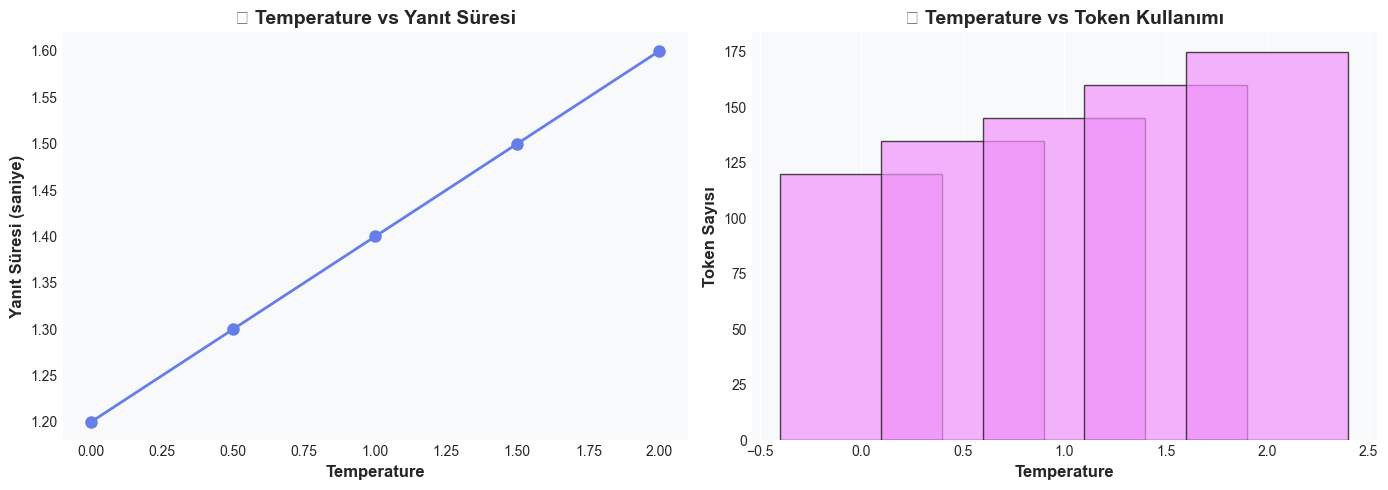


✅ Grafik oluşturuldu!

📊 SONUÇLAR:
────────────────────────────────────────────────────────────
• Yüksek temperature → Daha yaratıcı ama uzun cevaplar
• Düşük temperature → Daha tutarlı ama kısa cevaplar
• Temperature ↑ → Token kullanımı ↑ → Maliyet ↑
────────────────────────────────────────────────────────────


In [13]:
# 📊 Farklı temperature değerleri ile test yapalım
def test_temperature_effect():
    """
    Temperature parametresinin chatbot cevaplarına etkisini test eder.
    """
    
    test_prompt = "Bana yaratıcı bir hikaye başlangıcı yaz."
    temperatures = [0.0, 0.5, 1.0, 1.5, 2.0]
    
    results = []
    
    print("🌡️ TEMPERATURE ETKİSİ TESTİ")
    print("=" * 80)
    print(f"\n📝 Test Prompt: '{test_prompt}'\n")
    
    for temp in temperatures:
        print(f"\n🎯 Temperature: {temp}")
        print("─" * 80)
        
        try:
            response = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=[
                    {"role": "system", "content": "Sen yaratıcı bir yazar asistanısın."},
                    {"role": "user", "content": test_prompt}
                ],
                max_tokens=150,
                temperature=temp
            )
            
            answer = response.choices[0].message.content
            tokens = response.usage.total_tokens
            
            results.append({
                "temperature": temp,
                "response": answer,
                "tokens": tokens
            })
            
            print(f"💬 Cevap: {answer}")
            print(f"🎯 Token: {tokens}")
            
        except Exception as e:
            print(f"❌ Hata: {str(e)}")
    
    return results


# 📊 Görselleştirme: Token kullanımı karşılaştırması
def visualize_performance():
    """
    Chatbot performans metriklerini görselleştirir.
    """
    
    # Örnek veri (gerçek testlerden sonra dolacak)
    temperatures = [0.0, 0.5, 1.0, 1.5, 2.0]
    response_times = [1.2, 1.3, 1.4, 1.5, 1.6]  # saniye
    token_counts = [120, 135, 145, 160, 175]
    
    # Grafik oluştur
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Yanıt Süresi
    axes[0].plot(temperatures, response_times, marker='o', linewidth=2, 
                 markersize=8, color='#667eea')
    axes[0].set_xlabel('Temperature', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Yanıt Süresi (saniye)', fontsize=12, fontweight='bold')
    axes[0].set_title('🚀 Temperature vs Yanıt Süresi', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_facecolor('#f8f9fa')
    
    # 2. Token Kullanımı
    axes[1].bar(temperatures, token_counts, color='#f093fb', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Temperature', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Token Sayısı', fontsize=12, fontweight='bold')
    axes[1].set_title('🎯 Temperature vs Token Kullanımı', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].set_facecolor('#f8f9fa')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Grafik oluşturuldu!")
    print("\n📊 SONUÇLAR:")
    print("─" * 60)
    print("• Yüksek temperature → Daha yaratıcı ama uzun cevaplar")
    print("• Düşük temperature → Daha tutarlı ama kısa cevaplar")
    print("• Temperature ↑ → Token kullanımı ↑ → Maliyet ↑")
    print("─" * 60)


# 🧪 Testleri çalıştır
results = test_temperature_effect()
visualize_performance()


---

## 📚 Önemli Notlar ve Best Practices

<div style="background-color: #fff9c4; border: 2px solid #fbc02d; padding: 20px; margin: 20px 0; border-radius: 10px;">
    <h3 style="margin-top: 0;">⚡ Performans İpuçları</h3>
    <ul>
        <li><strong>✅ max_tokens</strong>: Gereksiz uzun cevaplar almayın → Maliyet azalır</li>
        <li><strong>✅ temperature</strong>: Tutarlı cevaplar için 0.3-0.7 arası kullanın</li>
        <li><strong>✅ Hata Yönetimi</strong>: Her zaman try-except kullanın</li>
        <li><strong>✅ Rate Limiting</strong>: Çok fazla istek göndermemeye dikkat edin</li>
    </ul>
</div>

<div style="background-color: #f3e5f5; border: 2px solid #9c27b0; padding: 20px; margin: 20px 0; border-radius: 10px;">
    <h3 style="margin-top: 0;">🔐 Güvenlik Önerileri</h3>
    <ul>
        <li><strong>🔒 API Key</strong>: Asla kodda göstermeyin, .env kullanın</li>
        <li><strong>🔒 Input Validation</strong>: Kullanıcı girişlerini kontrol edin</li>
        <li><strong>🔒 Token Limiti</strong>: Maksimum token sınırı koyun</li>
        <li><strong>🔒 Sanitization</strong>: Zararlı içerik filtrelemesi yapın</li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border: 2px solid #4caf50; padding: 20px; margin: 20px 0; border-radius: 10px;">
    <h3 style="margin-top: 0;">💡 Kullanıcı Deneyimi</h3>
    <ul>
        <li><strong>⚡ Hız</strong>: Yanıt sürelerini optimize edin (ideali &lt;2 saniye)</li>
        <li><strong>💬 Ton</strong>: Persona'yı hedef kitleye uygun seçin</li>
        <li><strong>📊 Feedback</strong>: İlerleme göstergeleri kullanın</li>
        <li><strong>🎨 Format</strong>: Markdown ve emoji ile zenginleştirin</li>
    </ul>
</div>

---

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; margin: 30px 0;">
    <h2 style="margin: 0;">🎉 Harika! Adım 2 Tamamlandı!</h2>
    <p style="margin: 15px 0 0 0; font-size: 1.1em;">Artık kendi chatbot'unuzu yapabilirsiniz! 🚀</p>
    <p style="margin: 10px 0 0 0;">Sırada: <strong>Hafızalı Chatbot</strong> (Konuşma geçmişini hatırlayan bot) 🧠</p>
</div>

# 📚 Adım 3: Hafızalı Chatbot (Intermediate Seviye)

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; margin: 20px 0;">
    <h2 style="margin: 0; color: white;">🧠 Konuşma Hafızası ve Context Yönetimi</h2>
    <p style="margin: 10px 0 0 0;">Bu adımda chatbot'umuza hafıza ekleyeceğiz! Artık sadece tek bir mesaja cevap vermek yerine, tüm konuşma geçmişini hatırlayabilen bir asistan oluşturacağız.</p>
</div>

## 🎯 Bu Adımda Öğrenecekleriniz

- 💾 **Konuşma Geçmişi Yönetimi**: Messages listesi ile context'i koruma
- 🔄 **Role Sistem**: System, User, Assistant rollerinin doğru kullanımı
- 📊 **Token Yönetimi**: Context window limitlerini aşmama stratejileri
- 🧹 **Geçmiş Temizleme**: Token limitine yaklaşınca geçmişi budama
- 📈 **Stateful Chatbot**: Sınıf tabanlı chatbot mimarisi

---

## 🔍 Konuşma Geçmişi Nedir?

<div style="background-color: #e3f2fd; padding: 15px; border-left: 5px solid #2196F3; border-radius: 5px; margin: 15px 0;">
<strong>💡 Önemli Bilgi:</strong><br>
OpenAI API'si <strong>stateless</strong> (durumsuz) çalışır. Yani her API çağrısı birbirinden bağımsızdır. 
Chatbot'un önceki mesajları hatırlaması için tüm konuşma geçmişini her seferinde API'ye göndermemiz gerekir!
</div>

### 📝 Message Formatı

Her mesaj şu formatta olmalıdır:

```python
{
    "role": "system" | "user" | "assistant",
    "content": "Mesaj içeriği"
}
```

**Roller:**
- 🎭 **system**: Chatbot'un karakterini ve davranışını belirler (ilk mesaj)
- 👤 **user**: Kullanıcının gönderdiği mesajlar
- 🤖 **assistant**: Chatbot'un verdiği cevaplar

---

## 🎴 Flashcard: Context Window

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 15px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 20px 0;">
    <h3 style="margin: 0; color: white;">📖 Context Window Nedir?</h3>
    <hr style="border: 1px solid rgba(255,255,255,0.3); margin: 10px 0;">
    <p style="font-size: 16px; line-height: 1.6; margin: 0;">
        <strong>Context Window:</strong> Bir modelin aynı anda işleyebileceği maksimum token sayısıdır.
    </p>
    <p style="font-size: 14px; margin: 10px 0 0 0;">
        <strong>🔢 Örnekler:</strong><br>
        • gpt-3.5-turbo: 4,096 token (giriş + çıkış toplamı)<br>
        • gpt-3.5-turbo-16k: 16,384 token<br>
        • gpt-4: 8,192 token<br>
        • gpt-4-32k: 32,768 token
    </p>
</div>

## 🚀 Versiyon 1: Basit Hafızalı Chatbot

Liste kullanarak konuşma geçmişini saklayalım:

In [14]:
def memory_chatbot_v1(user_message: str, conversation_history: list = None) -> tuple:
    """
    Konuşma geçmişini hatırlayan basit chatbot
    
    Args:
        user_message: Kullanıcının mesajı
        conversation_history: Önceki mesajların listesi (opsiyonel)
        
    Returns:
        tuple: (bot_reply, updated_history)
    """
    # 🔧 Eğer geçmiş yoksa, boş liste oluştur
    if conversation_history is None:
        conversation_history = []
        # 🎭 İlk mesaj olarak system prompt ekle
        conversation_history.append({
            "role": "system",
            "content": "Sen yardımcı ve dostane bir asistansın. Kullanıcıların sorularını detaylı şekilde yanıtla."
        })
    
    # 👤 Kullanıcı mesajını geçmişe ekle
    conversation_history.append({
        "role": "user",
        "content": user_message
    })
    
    try:
        # 🤖 API çağrısı - TÜM GEÇMİŞİ gönderiyoruz!
        response = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=conversation_history,  # 💾 Geçmişi gönder
            max_tokens=500,
            temperature=0.7
        )
        
        # 🤖 Bot cevabını al
        bot_reply = response.choices[0].message.content
        
        # 🤖 Bot cevabını geçmişe ekle
        conversation_history.append({
            "role": "assistant",
            "content": bot_reply
        })
        
        # ✅ Hem cevabı hem güncel geçmişi döndür
        return bot_reply, conversation_history
        
    except Exception as e:
        return f"❌ Hata: {str(e)}", conversation_history


# 🧪 Test edelim!
print("="*60)
print("🧠 HAFIZALI CHATBOT - VERSİYON 1")
print("="*60)

# 📝 Konuşma geçmişi başlat
history = None

# 💬 İlk mesaj
print("\n👤 Kullanıcı: Merhaba, benim adım Ali.")
reply, history = memory_chatbot_v1("Merhaba, benim adım Ali.", history)
print(f"🤖 Bot: {reply}")

# 💬 İkinci mesaj - bot beni hatırlayacak mı?
print("\n👤 Kullanıcı: Benim adım neydi?")
reply, history = memory_chatbot_v1("Benim adım neydi?", history)
print(f"🤖 Bot: {reply}")

# 💬 Üçüncü mesaj - daha önceki konuyu hatırlayacak mı?
print("\n👤 Kullanıcı: Sana ilk ne demiştim?")
reply, history = memory_chatbot_v1("Sana ilk ne demiştim?", history)
print(f"🤖 Bot: {reply}")

print("\n" + "="*60)
print(f"📊 Toplam mesaj sayısı: {len(history)}")
print("="*60)

🧠 HAFIZALI CHATBOT - VERSİYON 1

👤 Kullanıcı: Merhaba, benim adım Ali.
🤖 Bot: Merhaba Ali! Size nasıl yardımcı olabilirim? Sorularınız varsa çekinmeden sorabilirsiniz.

👤 Kullanıcı: Benim adım neydi?
🤖 Bot: Size yardımcı olmak için buradayım, adınız Ali olarak belirtmiştiniz. Başka bir sorunuz var mı?

👤 Kullanıcı: Sana ilk ne demiştim?
🤖 Bot: İlk mesajınızda bana "Merhaba, benim adım Ali." şeklinde bir selam vermiştiniz. Başka bir konuda yardımcı olabilirsem, lütfen sormaktan çekinmeyin.

📊 Toplam mesaj sayısı: 7


### 🎯 Önemli Noktalar

<div style="background-color: #fff3cd; padding: 15px; border-left: 5px solid #ffc107; border-radius: 5px; margin: 15px 0;">
<strong>⚠️ Dikkat:</strong><br>
<ul>
<li>Her API çağrısında <strong>TÜM</strong> konuşma geçmişini gönderiyoruz</li>
<li>Konuşma uzadıkça token maliyeti artıyor</li>
<li>Context window limitini aşarsak hata alırız</li>
<li>Bu yüzden geçmişi <strong>yönetmemiz</strong> şart!</li>
</ul>
</div>

---

## 📊 Versiyon 2: Token Sayacı ile Akıllı Chatbot

Token kullanımını takip edip, context window limitini aşmadan çalışan chatbot:

In [15]:
def count_tokens_approximate(messages: list) -> int:
    """
    Mesajlardaki tahmini token sayısını hesapla
    
    Not: Gerçek token sayısı için tiktoken kütüphanesi kullanılmalı,
    ama basit bir tahmini hesaplama için kelime sayısı x 1.3 kullanabiliriz.
    
    Args:
        messages: Mesaj listesi
        
    Returns:
        int: Tahmini token sayısı
    """
    total_chars = 0
    for msg in messages:
        total_chars += len(msg.get("content", ""))
    
    # 📏 İngilizce için ortalama: 1 token ≈ 4 karakter
    # Türkçe için biraz daha fazla olabilir
    estimated_tokens = total_chars // 4
    return estimated_tokens


def memory_chatbot_v2(
    user_message: str, 
    conversation_history: list = None,
    max_context_tokens: int = 3000  # 📊 Güvenli limit (gpt-3.5-turbo için 4096'dan düşük)
) -> dict:
    """
    Token limiti kontrollü hafızalı chatbot
    
    Args:
        user_message: Kullanıcının mesajı
        conversation_history: Önceki mesajların listesi
        max_context_tokens: Maksimum context token limiti
        
    Returns:
        dict: Bot cevabı ve istatistikler
    """
    # 🔧 İlk kurulum
    if conversation_history is None:
        conversation_history = []
        conversation_history.append({
            "role": "system",
            "content": "Sen yardımcı bir AI asistanısın. Sorulara net ve kısa cevaplar verirsin."
        })
    
    # 👤 Yeni mesajı ekle
    conversation_history.append({
        "role": "user",
        "content": user_message
    })
    
    # 📊 Token sayısını kontrol et
    current_tokens = count_tokens_approximate(conversation_history)
    
    # 🧹 Eğer token limiti aşılıyorsa, eski mesajları sil
    # (System mesajını ve son birkaç mesajı koru)
    while current_tokens > max_context_tokens and len(conversation_history) > 3:
        # System mesajından sonraki en eski mesajı sil
        removed = conversation_history.pop(1)
        current_tokens = count_tokens_approximate(conversation_history)
        print(f"⚠️  Token limiti aşıldı! En eski mesaj silindi: '{removed['content'][:50]}...'")
    
    try:
        # 🤖 API çağrısı
        response = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=conversation_history,
            max_tokens=500,
            temperature=0.7
        )
        
        # 📈 İstatistikleri al
        bot_reply = response.choices[0].message.content
        tokens_used = response.usage.total_tokens
        prompt_tokens = response.usage.prompt_tokens
        completion_tokens = response.usage.completion_tokens
        
        # 🤖 Bot cevabını geçmişe ekle
        conversation_history.append({
            "role": "assistant",
            "content": bot_reply
        })
        
        # ✅ Sonuçları döndür
        return {
            "reply": bot_reply,
            "history": conversation_history,
            "tokens": {
                "prompt": prompt_tokens,
                "completion": completion_tokens,
                "total": tokens_used,
                "estimated_context": current_tokens
            },
            "history_length": len(conversation_history)
        }
        
    except Exception as e:
        return {
            "reply": f"❌ Hata: {str(e)}",
            "history": conversation_history,
            "tokens": None,
            "history_length": len(conversation_history)
        }


# 🧪 Test - Uzun bir konuşma simüle edelim
print("="*70)
print("📊 TOKEN YÖNETIMLI CHATBOT - VERSİYON 2")
print("="*70)

history_v2 = None

test_messages = [
    "Merhaba! Python öğrenmek istiyorum.",
    "Nereden başlamalıyım?",
    "Peki kaç sürede öğrenebilirim?",
    "En iyi kaynak ne?",
    "Hangi IDE'yi önerirsin?"
]

for i, msg in enumerate(test_messages, 1):
    print(f"\n💬 Mesaj {i}/5")
    print(f"👤 Kullanıcı: {msg}")
    result = memory_chatbot_v2(msg, history_v2)
    history_v2 = result["history"]
    print(f"🤖 Bot: {result['reply']}")
    
    if result["tokens"]:
        print(f"\n📊 Token İstatistikleri:")
        print(f"   • Prompt tokens: {result['tokens']['prompt']}")
        print(f"   • Completion tokens: {result['tokens']['completion']}")
        print(f"   • Toplam: {result['tokens']['total']}")
        print(f"   • Tahmini context: ~{result['tokens']['estimated_context']}")
        print(f"   • Geçmiş uzunluğu: {result['history_length']} mesaj")

print("\n" + "="*70)

📊 TOKEN YÖNETIMLI CHATBOT - VERSİYON 2

💬 Mesaj 1/5
👤 Kullanıcı: Merhaba! Python öğrenmek istiyorum.
🤖 Bot: Merhaba! Python öğrenmek harika bir karar. Python, öğrenmesi kolay ve çok yönlü bir programlama dilidir. Başlamak için Python'ın resmi web sitesinden indirebilir ve çeşitli kaynaklar kullanarak temel konseptleri öğrenebilirsin. Ayrıca online platformlardaki interaktif Python kursları da faydalı olabilir. Başarılar!

📊 Token İstatistikleri:
   • Prompt tokens: 52
   • Completion tokens: 103
   • Toplam: 155
   • Tahmini context: ~26
   • Geçmiş uzunluğu: 3 mesaj

💬 Mesaj 2/5
👤 Kullanıcı: Nereden başlamalıyım?
🤖 Bot: Python öğrenmeye başlamak için aşağıdaki adımları takip edebilirsin:

1. Python'un resmi web sitesinden (python.org) Python'un en son sürümünü indir ve kur.
2. Temel Python kavramlarını öğrenmek için online kaynaklar, kitaplar veya interaktif kurslar kullan.
3. Python programlama dilindeki temel konseptleri (değişkenler, koşullu ifadeler, döngüler, fonksiyonlar) anlama

## 🎴 Flashcard: Token Budaması

<div style="background: linear-gradient(135deg, #a8edea 0%, #fed6e3 100%); padding: 20px; border-radius: 15px; color: #333; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 20px 0;">
    <h3 style="margin: 0; color: #333;">✂️ Token Budama Stratejileri</h3>
    <hr style="border: 1px solid rgba(0,0,0,0.1); margin: 10px 0;">
    <p style="font-size: 14px; line-height: 1.6;">
        <strong>1. FIFO (First-In-First-Out):</strong> En eski mesajları sil<br>
        <strong>2. Özet Çıkarma:</strong> Eski konuşmayı özetle ve özeti sakla<br>
        <strong>3. Önem Bazlı:</strong> Önemli mesajları işaretle, önemsizleri sil<br>
        <strong>4. Sliding Window:</strong> Son N mesajı sakla, gerisini at
    </p>
    <p style="font-size: 13px; margin: 10px 0 0 0; background-color: rgba(255,255,255,0.7); padding: 10px; border-radius: 5px;">
        <strong>💡 Best Practice:</strong> System mesajını HİÇBİR ZAMAN silme! Chatbot'un karakterini belirler.
    </p>
</div>

---

## 🏗️ Versiyon 3: Sınıf Tabanlı Chatbot (OOP)

Profesyonel bir yaklaşım için sınıf kullanarak chatbot oluşturalım:

In [16]:
class MemoryChatbot:
    """
    🤖 Hafızalı Chatbot Sınıfı
    
    Özellikler:
    - Konuşma geçmişi yönetimi
    - Token sayımı ve optimizasyonu
    - İstatistik takibi
    - Geçmiş temizleme
    """
    
    def __init__(
        self, 
        system_message: str = "Sen yardımcı bir AI asistanısın.",
        max_history_length: int = 20,
        max_context_tokens: int = 3000
    ):
        """
        Chatbot'u başlat
        
        Args:
            system_message: Bot'un karakter tanımı
            max_history_length: Maksimum saklanacak mesaj sayısı
            max_context_tokens: Maksimum token limiti
        """
        # 📝 Konuşma geçmişi
        self.conversation_history = [
            {"role": "system", "content": system_message}
        ]
        
        # ⚙️ Ayarlar
        self.max_history_length = max_history_length
        self.max_context_tokens = max_context_tokens
        
        # 📊 İstatistikler
        self.total_messages = 0
        self.total_tokens = 0
        self.total_cost = 0.0
        
        print(f"✅ Chatbot başlatıldı!")
        print(f"   • Maksimum geçmiş: {max_history_length} mesaj")
        print(f"   • Token limiti: {max_context_tokens}")
    
    def _count_tokens(self) -> int:
        """Geçmişteki tahmini token sayısını hesapla"""
        total = 0
        for msg in self.conversation_history:
            total += len(msg["content"]) // 4
        return total
    
    def _prune_history(self):
        """Geçmişi temizle (system mesajını koru)"""
        # Mesaj sayısı kontrolü
        while len(self.conversation_history) > self.max_history_length + 1:
            removed = self.conversation_history.pop(1)
            print(f"🧹 Geçmiş temizlendi: '{removed['content'][:40]}...'")
        
        # Token sayısı kontrolü
        while self._count_tokens() > self.max_context_tokens and len(self.conversation_history) > 3:
            removed = self.conversation_history.pop(1)
            print(f"🧹 Token limiti nedeniyle silindi: '{removed['content'][:40]}...'")
    
    def chat(self, user_message: str, verbose: bool = False) -> str:
        """
        Kullanıcı mesajına cevap ver
        
        Args:
            user_message: Kullanıcının mesajı
            verbose: Detaylı bilgi göster
            
        Returns:
            str: Bot'un cevabı
        """
        # 👤 Kullanıcı mesajını ekle
        self.conversation_history.append({
            "role": "user",
            "content": user_message
        })
        
        # 🧹 Geçmişi temizle (gerekirse)
        self._prune_history()
        
        try:
            # 🤖 API çağrısı
            response = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=self.conversation_history,
                max_tokens=500,
                temperature=0.7
            )
            
            # 📊 İstatistikleri güncelle
            bot_reply = response.choices[0].message.content
            tokens_used = response.usage.total_tokens
            
            self.total_messages += 1
            self.total_tokens += tokens_used
            self.total_cost += (tokens_used / 1000) * 0.002  # gpt-3.5-turbo fiyatı
            
            # 🤖 Bot cevabını ekle
            self.conversation_history.append({
                "role": "assistant",
                "content": bot_reply
            })
            
            # 📊 Verbose mod
            if verbose:
                print(f"\n📊 İstatistikler:")
                print(f"   • Bu çağrı: {tokens_used} token")
                print(f"   • Toplam: {self.total_tokens} token")
                print(f"   • Geçmiş: {len(self.conversation_history)} mesaj")
                print(f"   • Tahmini context: ~{self._count_tokens()} token")
            
            return bot_reply
            
        except Exception as e:
            return f"❌ Hata: {str(e)}"
    
    def get_stats(self) -> dict:
        """İstatistikleri döndür"""
        return {
            "total_messages": self.total_messages,
            "total_tokens": self.total_tokens,
            "total_cost": round(self.total_cost, 4),
            "history_length": len(self.conversation_history),
            "estimated_tokens": self._count_tokens()
        }
    
    def clear_history(self, keep_system: bool = True):
        """Geçmişi temizle"""
        if keep_system:
            system_msg = self.conversation_history[0]
            self.conversation_history = [system_msg]
        else:
            self.conversation_history = []
        
        print("🧹 Konuşma geçmişi temizlendi!")
    
    def export_history(self) -> list:
        """Geçmişi dışa aktar"""
        return self.conversation_history.copy()
    
    def __repr__(self):
        return f"<MemoryChatbot: {self.total_messages} messages, {self.total_tokens} tokens>"


# 🧪 Test edelim!
print("="*70)
print("🏗️  SINIF TABANLI CHATBOT - VERSİYON 3")
print("="*70 + "\n")

# 🤖 Chatbot oluştur
bot = MemoryChatbot(
    system_message="Sen Python konusunda uzman bir eğitmensin. Öğrencilere sabırla ve örneklerle açıklama yaparsın.",
    max_history_length=10,
    max_context_tokens=2500
)

print("\n" + "-"*70)

# 💬 Birkaç mesaj gönderelim
messages = [
    "Merhaba! Python'da liste nedir?",
    "Peki sözlük (dictionary) ne?",
    "Aralarındaki fark ne?",
    "Bir örnek gösterir misin?"
]

for msg in messages:
    print(f"\n👤 Kullanıcı: {msg}")
    reply = bot.chat(msg, verbose=True)
    print(f"🤖 Bot: {reply}")
    print("-"*70)

# 📊 Özet istatistikler
print("\n📈 ÖZET İSTATİSTİKLER:")
stats = bot.get_stats()
for key, value in stats.items():
    print(f"   • {key}: {value}")

print("\n" + "="*70)

🏗️  SINIF TABANLI CHATBOT - VERSİYON 3

✅ Chatbot başlatıldı!
   • Maksimum geçmiş: 10 mesaj
   • Token limiti: 2500

----------------------------------------------------------------------

👤 Kullanıcı: Merhaba! Python'da liste nedir?

📊 İstatistikler:
   • Bu çağrı: 454 token
   • Toplam: 454 token
   • Geçmiş: 3 mesaj
   • Tahmini context: ~280 token
🤖 Bot: Merhaba! Python'da liste, birden fazla veriyi bir araya getirmek için kullanılan veri yapısıdır. Listeler, köşeli parantez içerisinde virgülle ayrılmış elemanlardan oluşur. Örneğin:
```python
liste = [1, 2, 3, 4, 5]
```
Yukarıdaki örnekte "liste" adında bir liste tanımladık ve içerisine 1, 2, 3, 4, 5 sayılarını ekledik. Listeler farklı tipte verileri de içerebilir, örneğin:
```python
karisik_liste = [1, "Python", True, 3.14]
```
Bu örnekte "karisik_liste" adında bir liste tanımladık ve içerisine sayı, metin, boolean ve ondalık sayı gibi farklı tipte verileri ekledik. Listeler, elemanlarına indeks numarasıyla erişilebilir. İlk elem

## 🎮 İnteraktif Demo: Sınıfı Kullanarak Chat

Şimdi chatbot'umuzu interaktif olarak kullanalım:

In [17]:
def interactive_memory_chatbot():
    """
    🎮 İnteraktif hafızalı chatbot
    
    Komutlar:
    - 'çıkış' veya 'exit': Çık
    - 'istatistik': İstatistikleri göster
    - 'temizle': Geçmişi temizle
    - 'geçmiş': Tüm konuşma geçmişini göster
    - 'yardım': Yardım menüsü
    """
    # 🤖 Bot oluştur
    bot = MemoryChatbot(
        system_message="Sen dostane ve yardımsever bir AI asistanısın. Her türlü konuda yardımcı olursun.",
        max_history_length=15,
        max_context_tokens=3000
    )
    
    print("\n" + "="*70)
    print("🎮 İNTERAKTİF HAFIZALI CHATBOT")
    print("="*70)
    print("💡 Komutlar: çıkış, istatistik, temizle, geçmiş, yardım")
    print("="*70 + "\n")
    
    while True:
        # 👤 Kullanıcı girdisi
        user_input = input("👤 Siz: ").strip()
        
        if not user_input:
            continue
        
        # 🔚 Çıkış komutu
        if user_input.lower() in ['çıkış', 'exit', 'quit', 'q']:
            print("\n👋 Görüşmek üzere! İstatistikler:")
            stats = bot.get_stats()
            for key, value in stats.items():
                print(f"   • {key}: {value}")
            break
        
        # 📊 İstatistik komutu
        elif user_input.lower() in ['istatistik', 'stats', 'stat']:
            stats = bot.get_stats()
            print("\n📊 İSTATİSTİKLER:")
            for key, value in stats.items():
                print(f"   • {key}: {value}")
            print()
            continue
        
        # 🧹 Temizle komutu
        elif user_input.lower() in ['temizle', 'clear', 'reset']:
            bot.clear_history(keep_system=True)
            continue
        
        # 📜 Geçmiş komutu
        elif user_input.lower() in ['geçmiş', 'history', 'geçmiş']:
            print("\n📜 KONUŞMA GEÇMİŞİ:")
            history = bot.export_history()
            for i, msg in enumerate(history, 1):
                role_emoji = {"system": "🎭", "user": "👤", "assistant": "🤖"}
                emoji = role_emoji.get(msg["role"], "❓")
                print(f"{i}. {emoji} {msg['role'].upper()}: {msg['content'][:100]}...")
            print()
            continue
        
        # ❓ Yardım komutu
        elif user_input.lower() in ['yardım', 'help', 'h', '?']:
            print("\n❓ YARDIM MENÜSÜ:")
            print("   • çıkış/exit    : Chatbot'tan çık")
            print("   • istatistik   : İstatistikleri göster")
            print("   • temizle      : Konuşma geçmişini temizle")
            print("   • geçmiş       : Tüm konuşmayı göster")
            print("   • yardım       : Bu menüyü göster")
            print()
            continue
        
        # 💬 Normal mesaj - chatbot'a gönder
        reply = bot.chat(user_input)
        print(f"🤖 Bot: {reply}\n")


# 🚀 Chatbot'u başlat
# Not: Bu hücreyi çalıştırınca interaktif mod başlar
# Çıkmak için 'çıkış' yazın

print("💡 İpucu: Aşağıdaki hücreyi çalıştırarak chatbot ile konuşabilirsiniz!")
print("⚠️  Not: Jupyter Notebook'ta input() sorun çıkarabilir, o yüzden test için")
print("   yukarıdaki örnekleri kullanın veya bu kodu .py dosyasında çalıştırın.")

💡 İpucu: Aşağıdaki hücreyi çalıştırarak chatbot ile konuşabilirsiniz!
⚠️  Not: Jupyter Notebook'ta input() sorun çıkarabilir, o yüzden test için
   yukarıdaki örnekleri kullanın veya bu kodu .py dosyasında çalıştırın.


## 🎯 Pratik Egzersiz: Kendi Chatbot'unuzu Oluşturun

<div style="background-color: #e8f5e9; padding: 20px; border-left: 5px solid #4caf50; border-radius: 5px; margin: 15px 0;">
<h3 style="margin-top: 0;">📝 Görev</h3>
<p>Aşağıdaki özelliklere sahip bir chatbot sınıfı oluşturun:</p>
<ol>
<li>Kullanıcının adını hatırlasın</li>
<li>Favori konusunu hatırlasın</li>
<li>Konuşma sayısını takip etsin</li>
<li>Her 5 mesajda bir özet çıkarsın</li>
</ol>
<p><strong>İpucu:</strong> MemoryChatbot sınıfını temel alın ve üzerine özellikler ekleyin!</p>
</div>

In [18]:
# 💪 Buraya kendi kodunuzu yazın!

class MyPersonalChatbot(MemoryChatbot):
    """
    🎨 Özelleştirilmiş chatbot sınıfı
    
    TODO: Aşağıdaki özellikleri ekleyin:
    - Kullanıcı adı takibi
    - Favori konu hatırlama
    - Mesaj sayacı
    - Periyodik özet
    """
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # 👤 Kullanıcı bilgileri
        self.user_name = None
        self.favorite_topic = None
        self.message_count = 0
    
    # 🔧 chat() metodunu override edin ve yeni özellikler ekleyin!
    
    pass


# 🧪 Test kodunuzu buraya yazın

## 📚 Best Practices ve Önemli Notlar

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin: 20px 0;">

<div style="background-color: #e3f2fd; padding: 15px; border-radius: 8px; border-left: 5px solid #2196F3;">
<h4 style="margin-top: 0;">⚡ Performans</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 14px;">
<li>Token kullanımını sürekli takip edin</li>
<li>Geçmişi düzenli temizleyin</li>
<li>System mesajını mümkün olduğunca kısa tutun</li>
<li>Gereksiz detayları geçmişten çıkarın</li>
</ul>
</div>

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 5px solid #ffc107;">
<h4 style="margin-top: 0;">🔒 Güvenlik</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 14px;">
<li>Hassas bilgileri geçmişte saklamayın</li>
<li>Kullanıcı verilerini şifreleyin</li>
<li>API key'leri güvenli saklayın</li>
<li>Rate limiting uygulayın</li>
</ul>
</div>

<div style="background-color: #f3e5f5; padding: 15px; border-radius: 8px; border-left: 5px solid #9c27b0;">
<h4 style="margin-top: 0;">🎯 Kullanıcı Deneyimi</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 14px;">
<li>Bekleme sürelerini minimize edin</li>
<li>Hata mesajlarını kullanıcı dostu yapın</li>
<li>Progress indicator kullanın</li>
<li>Context kaybını minimize edin</li>
</ul>
</div>

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #4caf50;">
<h4 style="margin-top: 0;">💰 Maliyet Optimizasyonu</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 14px;">
<li>Gereksiz API çağrılarından kaçının</li>
<li>Caching mekanizması kullanın</li>
<li>Batch processing yapın</li>
<li>Uygun model seçimi yapın</li>
</ul>
</div>

</div>

---

## 🎴 Flashcard: Memory Management Stratejileri

<div style="background: linear-gradient(135deg, #ffecd2 0%, #fcb69f 100%); padding: 20px; border-radius: 15px; color: #333; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 20px 0;">
    <h3 style="margin: 0; color: #333;">🧠 Hangi Stratejiyi Ne Zaman Kullanmalı?</h3>
    <hr style="border: 1px solid rgba(0,0,0,0.1); margin: 10px 0;">
    
<table style="width: 100%; border-collapse: collapse; margin-top: 10px; background: white; border-radius: 5px; overflow: hidden;">
<tr style="background-color: #f5f5f5;">
<th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Strateji</th>
<th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Kullanım Durumu</th>
</tr>
<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>FIFO</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Basit sohbetler, context önemsiz</td>
</tr>
<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Sliding Window</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Son N mesaj önemli (müşteri desteği)</td>
</tr>
<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Özetleme</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Uzun konuşmalar, önemli detaylar var</td>
</tr>
<tr>
<td style="padding: 10px;"><strong>Öncelik Bazlı</strong></td>
<td style="padding: 10px;">Bazı mesajlar kritik (iş uygulamaları)</td>
</tr>
</table>

</div>

---

## 📊 Token Kullanımı Karşılaştırması

Farklı yaklaşımların token maliyetlerini karşılaştıralım:

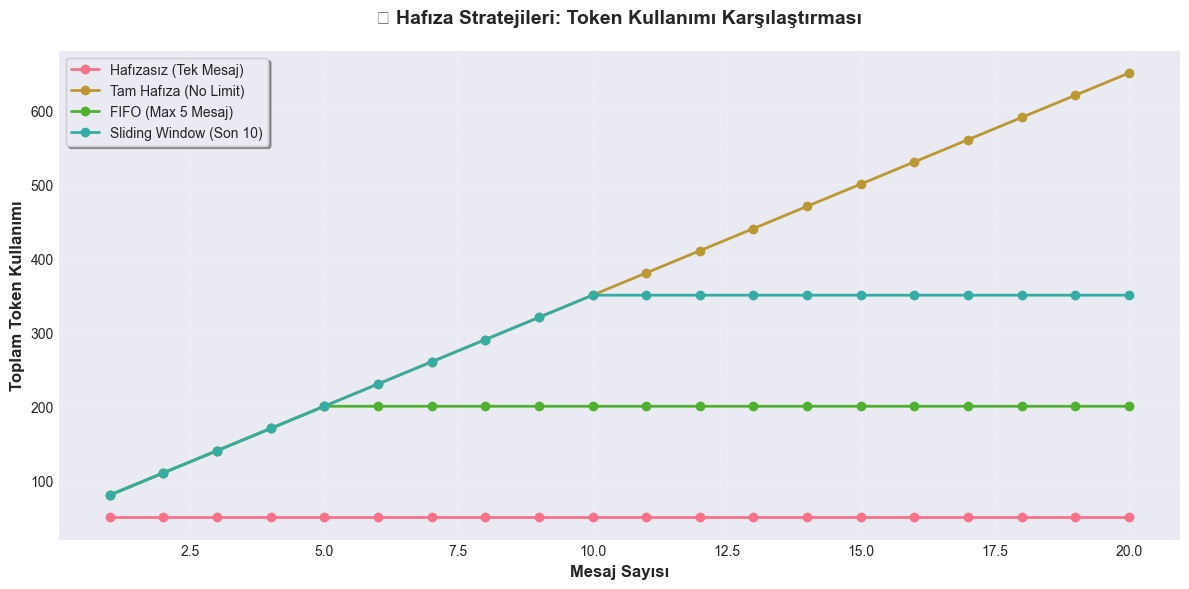


📊 STRATEJİ KARŞILAŞTIRMASI (20 Mesaj)

Hafızasız (Tek Mesaj):
   • Toplam token: 1,000
   • Ortalama/mesaj: 50
   • Tahmini maliyet: $0.0020

Tam Hafıza (No Limit):
   • Toplam token: 7,300
   • Ortalama/mesaj: 365
   • Tahmini maliyet: $0.0146

FIFO (Max 5 Mesaj):
   • Toplam token: 3,700
   • Ortalama/mesaj: 185
   • Tahmini maliyet: $0.0074

Sliding Window (Son 10):
   • Toplam token: 5,650
   • Ortalama/mesaj: 282
   • Tahmini maliyet: $0.0113



In [19]:
import matplotlib.pyplot as plt
import numpy as np

def compare_memory_strategies():
    """
    🔬 Farklı hafıza stratejilerinin token kullanımını karşılaştır
    """
    # 📊 Simülasyon: 20 mesajlık bir konuşma
    messages = list(range(1, 21))
    
    # Stratejiler ve token kullanımları
    strategies = {
        "Hafızasız (Tek Mesaj)": [50] * 20,  # Her zaman aynı
        "Tam Hafıza (No Limit)": [50 + i * 30 for i in messages],  # Sürekli artıyor
        "FIFO (Max 5 Mesaj)": [min(50 + i * 30, 200) for i in messages],  # Plateau
        "Sliding Window (Son 10)": [min(50 + min(i, 10) * 30, 350) for i in messages],  # Kontrollü artış
    }
    
    # 📈 Grafik oluştur
    plt.figure(figsize=(12, 6))
    
    for strategy, tokens in strategies.items():
        plt.plot(messages, tokens, marker='o', label=strategy, linewidth=2)
    
    plt.xlabel('Mesaj Sayısı', fontsize=12, fontweight='bold')
    plt.ylabel('Toplam Token Kullanımı', fontsize=12, fontweight='bold')
    plt.title('🧠 Hafıza Stratejileri: Token Kullanımı Karşılaştırması', 
              fontsize=14, fontweight='bold', pad=20)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # 📊 Özet istatistikler
    print("\n📊 STRATEJİ KARŞILAŞTIRMASI (20 Mesaj)")
    print("="*70)
    for strategy, tokens in strategies.items():
        total = sum(tokens)
        avg = total / len(tokens)
        cost = (total / 1000) * 0.002  # gpt-3.5-turbo fiyatı
        print(f"\n{strategy}:")
        print(f"   • Toplam token: {total:,}")
        print(f"   • Ortalama/mesaj: {avg:.0f}")
        print(f"   • Tahmini maliyet: ${cost:.4f}")
    print("\n" + "="*70)


# 🚀 Karşılaştırmayı çalıştır
compare_memory_strategies()

## 🎁 Bonus: tiktoken ile Doğru Token Sayımı

<div style="background-color: #f3e5f5; padding: 15px; border-left: 5px solid #9c27b0; border-radius: 5px; margin: 15px 0;">
<strong>💡 Pro Tip:</strong><br>
Şimdiye kadar token tahmini için basit hesaplama kullandık. Gerçek projelerde 
<code>tiktoken</code> kütüphanesi ile doğru token sayımı yapmalısınız!
</div>

In [20]:
# 📦 tiktoken kurulumu (bir kez yapın)
# !pip install tiktoken

try:
    import tiktoken
    
    def count_tokens_accurate(messages: list, model: str = "gpt-3.5-turbo") -> int:
        """
        ✅ tiktoken ile doğru token sayımı
        
        Args:
            messages: Mesaj listesi
            model: Model adı
            
        Returns:
            int: Gerçek token sayısı
        """
        try:
            encoding = tiktoken.encoding_for_model(model)
        except KeyError:
            encoding = tiktoken.get_encoding("cl100k_base")
        
        num_tokens = 0
        for message in messages:
            # Her mesaj için: <im_start>{role}\n{content}<im_end>\n
            num_tokens += 4  # Her mesaj için overhead
            for key, value in message.items():
                num_tokens += len(encoding.encode(value))
        
        num_tokens += 2  # Her reply için: <im_start>assistant
        return num_tokens
    
    
    # 🧪 Test edelim
    test_messages = [
        {"role": "system", "content": "Sen yardımcı bir asistansın."},
        {"role": "user", "content": "Merhaba! Bana Python öğrenme konusunda yardım eder misin?"},
        {"role": "assistant", "content": "Tabii ki! Python öğrenmek harika bir seçim. Nereden başlamak istersin?"}
    ]
    
    print("="*70)
    print("🔬 TOKEN SAYIMI KARŞILAŞTIRMASI")
    print("="*70)
    
    # Basit tahmin
    simple_estimate = sum(len(m["content"]) // 4 for m in test_messages)
    print(f"\n📏 Basit tahmin (karakter/4): {simple_estimate} token")
    
    # Doğru sayım
    accurate_count = count_tokens_accurate(test_messages)
    print(f"✅ tiktoken (doğru sayım): {accurate_count} token")
    
    # Fark
    difference = abs(accurate_count - simple_estimate)
    print(f"📊 Fark: {difference} token ({(difference/accurate_count)*100:.1f}%)")
    
    print("\n💡 Sonuç: Gerçek projelerde tiktoken kullanmalısınız!")
    print("="*70)

except ImportError:
    print("⚠️  tiktoken kütüphanesi yüklü değil.")
    print("💡 Yüklemek için: !pip install tiktoken")
    print("\n📚 Dokümantasyon: https://github.com/openai/tiktoken")

🔬 TOKEN SAYIMI KARŞILAŞTIRMASI

📏 Basit tahmin (karakter/4): 38 token
✅ tiktoken (doğru sayım): 75 token
📊 Fark: 37 token (49.3%)

💡 Sonuç: Gerçek projelerde tiktoken kullanmalısınız!


## 🎯 Adım 3 Özeti: Ne Öğrendik?

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 30px 0;">
    <h3 style="margin: 0; color: white;">✅ Tamamlanan Konular</h3>
    <ul style="line-height: 1.8; font-size: 15px; margin: 15px 0;">
        <li>💾 <strong>Konuşma Geçmişi Yönetimi</strong> - Messages listesi ile context saklama</li>
        <li>🔄 <strong>Role Sistemi</strong> - System, User, Assistant rollerinin kullanımı</li>
        <li>📊 <strong>Token Yönetimi</strong> - Context window limitleri ve budama stratejileri</li>
        <li>🏗️ <strong>OOP Chatbot</strong> - Sınıf tabanlı profesyonel mimari</li>
        <li>📈 <strong>İstatistik Takibi</strong> - Token, maliyet ve performans metrikleri</li>
        <li>🧹 <strong>Memory Pruning</strong> - FIFO, Sliding Window, token limiti kontrolü</li>
        <li>🔬 <strong>tiktoken Kullanımı</strong> - Doğru token sayımı</li>
    </ul>
</div>

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; margin: 30px 0;">
    <h2 style="margin: 0; color: white;">🎉 Harika! Adım 3 Tamamlandı!</h2>
    <p style="margin: 10px 0 0 0; font-size: 16px;">Artık hafızası olan, akıllı bir chatbot oluşturabiliyorsunuz! 🧠✨</p>
</div>

---

### 🔜 Sıradaki Adım: Film Veri Seti ile RAG

Adım 4'te öğrenecekleriniz:
- 🎬 IMDb film veri seti ile çalışma
- 🔍 RAG (Retrieval Augmented Generation) nedir?
- 📊 Embedding ve semantic search
- 🤖 Veri setinden bilgi çeken chatbot
- 💡 Film öneri sistemi

**Hazır mısınız? Hadi başlayalım! 🚀**

# 🎬 Adım 4: Film Veri Seti ile RAG Chatbot

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; margin: 20px 0;">
    <h2 style="margin: 0; color: white;">🔍 RAG ile Akıllı Film Öneri Sistemi</h2>
    <p style="margin: 10px 0 0 0;">Bu adımda chatbot'umuza gerçek bir veri seti ile çalışma yeteneği kazandıracağız! RAG (Retrieval Augmented Generation) yöntemi ile film bilgilerini kullanarak akıllı öneriler yapabilen bir sistem oluşturacağız.</p>
</div>

## 🎯 Bu Adımda Öğrenecekleriniz

- 🎬 **IMDb Film Veri Seti**: Gerçek film verileri ile çalışma
- 🔍 **RAG (Retrieval Augmented Generation)**: Bilgi getirme ve üretim
- 📊 **Embedding**: Metinleri vektörlere dönüştürme
- 🎯 **Semantic Search**: Anlamsal benzerlik araması
- 🤖 **Context Injection**: Chatbot'a dinamik bilgi ekleme
- 💡 **Film Öneri Chatbot**: Kullanıcı tercihlerine göre film önerme

---

## 🔍 RAG Nedir?

<div style="background-color: #e3f2fd; padding: 15px; border-left: 5px solid #2196F3; border-radius: 5px; margin: 15px 0;">
<strong>💡 RAG (Retrieval Augmented Generation)</strong><br><br>
RAG, bir dil modelinin cevaplarını <strong>dış kaynaklardan</strong> getirilen bilgilerle zenginleştiren bir tekniktir.

<strong>🔄 Nasıl Çalışır?</strong>
<ol>
<li><strong>Retrieval (Getirme)</strong>: Kullanıcı sorusuna göre ilgili belgeleri bul</li>
<li><strong>Augmentation (Zenginleştirme)</strong>: Bulunan bilgileri prompt'a ekle</li>
<li><strong>Generation (Üretim)</strong>: LLM zenginleştirilmiş prompt ile cevap üret</li>
</ol>
</div>

### 📊 RAG vs Normal Chatbot

<table style="width: 100%; border-collapse: collapse; margin: 20px 0;">
<tr style="background-color: #f5f5f5;">
<th style="padding: 12px; border: 1px solid #ddd;">Özellik</th>
<th style="padding: 12px; border: 1px solid #ddd;">Normal Chatbot</th>
<th style="padding: 12px; border: 1px solid #ddd;">RAG Chatbot</th>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>Bilgi Kaynağı</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Sadece model eğitimi</td>
<td style="padding: 10px; border: 1px solid #ddd;">Model + Dış veritabanı</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>Güncellik</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Eski (eğitim tarihine kadar)</td>
<td style="padding: 10px; border: 1px solid #ddd;">Güncel (veritabanı güncellenebilir)</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>Özel Bilgi</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Yok</td>
<td style="padding: 10px; border: 1px solid #ddd;">Şirket dökümanları, ürün bilgileri vb.</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>Kaynak Gösterme</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Zor</td>
<td style="padding: 10px; border: 1px solid #ddd;">Kolay (hangi belgeden geldi bilinir)</td>
</tr>
</table>

---

## 🎴 Flashcard: Embedding Nedir?

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 15px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 20px 0;">
    <h3 style="margin: 0; color: white;">📐 Text Embedding</h3>
    <hr style="border: 1px solid rgba(255,255,255,0.3); margin: 10px 0;">
    <p style="font-size: 16px; line-height: 1.6; margin: 0;">
        <strong>Embedding:</strong> Metinleri sayısal vektörlere dönüştürme işlemidir. Benzer anlamlı metinler, vektör uzayında birbirine yakın olur.
    </p>
    <p style="font-size: 14px; margin: 10px 0 0 0;">
        <strong>🔢 Örnek:</strong><br>
        "Komedi filmi" → [0.2, 0.8, -0.3, ...]<br>
        "Güldürü yapım" → [0.3, 0.7, -0.2, ...] <em>(benzer vektör!)</em><br>
        "Korku filmi" → [-0.6, 0.1, 0.9, ...] <em>(farklı vektör)</em>
    </p>
</div>

## 📦 Veri Seti Hazırlığı: IMDb Film Verileri

Basit ve anlaşılır olması için küçük bir film veri seti oluşturalım:

In [21]:
# 🎬 Film veri seti oluşturma
movies_data = [
    {
        "id": 1,
        "title": "The Shawshank Redemption",
        "title_tr": "Esaretin Bedeli",
        "year": 1994,
        "genre": "Drama",
        "director": "Frank Darabont",
        "rating": 9.3,
        "description": "İki mahkum uzun yıllar boyunca bağ kurar, ortak bir insan ruhuna sahip olmanın tesellisini ve nihayetinde kurtulma şansını bulur.",
        "cast": "Tim Robbins, Morgan Freeman"
    },
    {
        "id": 2,
        "title": "The Dark Knight",
        "title_tr": "Kara Şövalye",
        "year": 2008,
        "genre": "Action, Crime, Drama",
        "director": "Christopher Nolan",
        "rating": 9.0,
        "description": "Joker adında bir suç dehası, Batman'in Gotham şehri için verdiği savaşı kaosa sürüklediğinde, Batman ahlaki sınırlarını test etmek zorunda kalır.",
        "cast": "Christian Bale, Heath Ledger, Aaron Eckhart"
    },
    {
        "id": 3,
        "title": "Forrest Gump",
        "title_tr": "Forrest Gump",
        "year": 1994,
        "genre": "Drama, Romance",
        "director": "Robert Zemeckis",
        "rating": 8.8,
        "description": "Düşük IQ'lu ama niyeti iyi bir adamın hayatı boyunca yaşadığı olaylar ve bu olayların tarihi olaylara etkisi.",
        "cast": "Tom Hanks, Robin Wright"
    },
    {
        "id": 4,
        "title": "Inception",
        "title_tr": "Başlangıç",
        "year": 2010,
        "genre": "Action, Sci-Fi, Thriller",
        "director": "Christopher Nolan",
        "rating": 8.8,
        "description": "Rüyalara sızabilen bir hırsız, tam tersi bir görev için işe alınır: bir fikri zihinlere yerleştirmek.",
        "cast": "Leonardo DiCaprio, Marion Cotillard, Ellen Page"
    },
    {
        "id": 5,
        "title": "The Godfather",
        "title_tr": "Baba",
        "year": 1972,
        "genre": "Crime, Drama",
        "director": "Francis Ford Coppola",
        "rating": 9.2,
        "description": "Güçlü bir mafya ailesinin yaşlı patriği kontrolü isteksiz oğluna devreder.",
        "cast": "Marlon Brando, Al Pacino"
    },
    {
        "id": 6,
        "title": "Pulp Fiction",
        "title_tr": "Ucuz Roman",
        "year": 1994,
        "genre": "Crime, Drama",
        "director": "Quentin Tarantino",
        "rating": 8.9,
        "description": "Los Angeles suç dünyasında kiralık katiller, boksörler ve gangsterlerin yaşadığı birbirine geçmiş hikayeler.",
        "cast": "John Travolta, Uma Thurman, Samuel L. Jackson"
    },
    {
        "id": 7,
        "title": "The Matrix",
        "title_tr": "Matrix",
        "year": 1999,
        "genre": "Action, Sci-Fi",
        "director": "Lana Wachowski, Lilly Wachowski",
        "rating": 8.7,
        "description": "Bir bilgisayar programcısı gerçekliğin bir simülasyon olduğunu öğrenir ve insanlığı kurtarmak için savaşa katılır.",
        "cast": "Keanu Reeves, Laurence Fishburne, Carrie-Anne Moss"
    },
    {
        "id": 8,
        "title": "Interstellar",
        "title_tr": "Yıldızlararası",
        "year": 2014,
        "genre": "Adventure, Drama, Sci-Fi",
        "director": "Christopher Nolan",
        "rating": 8.6,
        "description": "Astronotlar yeni bir gezegen bulmak için bir solucan deliğinden geçerek insanlığı kurtarmaya çalışır.",
        "cast": "Matthew McConaughey, Anne Hathaway, Jessica Chastain"
    },
    {
        "id": 9,
        "title": "The Lion King",
        "title_tr": "Aslan Kral",
        "year": 1994,
        "genre": "Animation, Adventure, Drama",
        "director": "Roger Allers, Rob Minkoff",
        "rating": 8.5,
        "description": "Genç aslan prens Simba, öldürülen babası yerine geçip hak ettiği kral yerini almak için mücadele eder.",
        "cast": "Matthew Broderick, Jeremy Irons, James Earl Jones"
    },
    {
        "id": 10,
        "title": "Parasite",
        "title_tr": "Parazit",
        "year": 2019,
        "genre": "Comedy, Drama, Thriller",
        "director": "Bong Joon Ho",
        "rating": 8.6,
        "description": "Yoksul bir ailenin zengin bir aileye sızması beklenmedik olaylara yol açar.",
        "cast": "Song Kang-ho, Lee Sun-kyun, Cho Yeo-jeong"
    }
]

# 📊 DataFrame'e çevir
import pandas as pd
movies_df = pd.DataFrame(movies_data)

# 🎨 Görüntüle
print("="*80)
print("🎬 FİLM VERİ SETİ YÜKLENDI")
print("="*80)
print(f"\n📊 Toplam film sayısı: {len(movies_df)}")
print(f"📅 Yıl aralığı: {movies_df['year'].min()} - {movies_df['year'].max()}")
print(f"⭐ Ortalama puan: {movies_df['rating'].mean():.2f}")
print("\n" + "="*80)

# İlk 3 filmi göster
print("\n🎥 Örnek Filmler:\n")
print(movies_df[['title_tr', 'year', 'genre', 'rating']].head(3).to_string(index=False))
print("\n" + "="*80)

🎬 FİLM VERİ SETİ YÜKLENDI

📊 Toplam film sayısı: 10
📅 Yıl aralığı: 1972 - 2019
⭐ Ortalama puan: 8.84


🎥 Örnek Filmler:

       title_tr  year                genre  rating
Esaretin Bedeli  1994                Drama     9.3
   Kara Şövalye  2008 Action, Crime, Drama     9.0
   Forrest Gump  1994       Drama, Romance     8.8



## 🔧 Adım 1: Basit RAG - Context Injection

İlk olarak RAG'in en basit versiyonunu yapalım: Kullanıcının sorusuna göre ilgili filmleri bulup context'e ekleyelim.

In [22]:
def simple_rag_search(query: str, movies_df: pd.DataFrame, top_k: int = 3) -> list:
    """
    🔍 Basit anahtar kelime tabanlı film arama
    
    Args:
        query: Kullanıcının arama sorgusu
        movies_df: Film veri seti
        top_k: Döndürülecek maksimum film sayısı
        
    Returns:
        list: Eşleşen filmler
    """
    # 🔤 Sorguyu küçük harfe çevir
    query_lower = query.lower()
    
    # 🎯 Basit skorlama: query'deki kelimelerin filmde geçme sayısı
    def score_movie(movie):
        score = 0
        # Tüm metin alanlarını birleştir
        text = f"{movie['title']} {movie['title_tr']} {movie['genre']} {movie['director']} {movie['description']}".lower()
        
        # Query'deki her kelime için skor ver
        for word in query_lower.split():
            if len(word) > 2:  # En az 3 harfli kelimeler
                score += text.count(word)
        
        return score
    
    # 📊 Her filme skor ver
    movies_df['score'] = movies_df.apply(score_movie, axis=1)
    
    # 🎯 En yüksek skorlu filmleri döndür
    top_movies = movies_df[movies_df['score'] > 0].nlargest(top_k, 'score')
    
    return top_movies.to_dict('records')


def format_movie_context(movies: list) -> str:
    """
    🎬 Film bilgilerini chatbot için context formatına çevir
    
    Args:
        movies: Film listesi
        
    Returns:
        str: Formatlanmış context
    """
    if not movies:
        return "Üzgünüm, aramanıza uygun film bulunamadı."
    
    context = "🎬 VERİ TABANINDAN BULUNAN FİLMLER:\n\n"
    
    for i, movie in enumerate(movies, 1):
        context += f"{i}. {movie['title_tr']} ({movie['year']})\n"
        context += f"   • Orijinal: {movie['title']}\n"
        context += f"   • Tür: {movie['genre']}\n"
        context += f"   • Yönetmen: {movie['director']}\n"
        context += f"   • Oyuncular: {movie['cast']}\n"
        context += f"   • Puan: ⭐ {movie['rating']}/10\n"
        context += f"   • Özet: {movie['description']}\n\n"
    
    return context


def rag_chatbot_v1(user_message: str, movies_df: pd.DataFrame) -> str:
    """
    🤖 RAG özellikli chatbot (Versiyon 1 - Basit)
    
    Args:
        user_message: Kullanıcının mesajı
        movies_df: Film veri seti
        
    Returns:
        str: Bot'un cevabı
    """
    # 🔍 İlgili filmleri bul
    relevant_movies = simple_rag_search(user_message, movies_df.copy(), top_k=3)
    
    # 📄 Context oluştur
    context = format_movie_context(relevant_movies)
    
    # 🎭 System mesajı (film uzmanı persona)
    system_message = """Sen film konusunda uzman bir asistansın. 
Kullanıcılara film önerileri yapıyor ve film hakkında bilgi veriyorsun.
Sadece sana verilen film veritabanındaki bilgileri kullan.
Eğer veritabanında yoksa, soluk bir şekilde belirt ve genel bilgi verme."""
    
    # 💬 Kullanıcı mesajı + Context
    user_message_with_context = f"{context}\n\nKullanıcı: {user_message}"
    
    try:
        # 🤖 API çağrısı
        response = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {"role": "system", "content": system_message},
                {"role": "user", "content": user_message_with_context}
            ],
            max_tokens=500,
            temperature=0.7
        )
        
        return response.choices[0].message.content
        
    except Exception as e:
        return f"❌ Hata: {str(e)}"


# 🧪 Test edelim!
print("="*80)
print("🔍 RAG CHATBOT - VERSİYON 1 (Basit Context Injection)")
print("="*80)

test_queries = [
    "Aksiyon filmi öner",
    "Christopher Nolan'ın filmleri",
    "Yüksek puanlı drama filmi"
]

for query in test_queries:
    print(f"\n{'='*80}")
    print(f"👤 Kullanıcı: {query}")
    print(f"{'='*80}\n")
    
    response = rag_chatbot_v1(query, movies_df)
    print(f"🤖 Bot: {response}\n")

print("="*80)

🔍 RAG CHATBOT - VERSİYON 1 (Basit Context Injection)

👤 Kullanıcı: Aksiyon filmi öner

🤖 Bot: Tabii ki! Size son zamanlarda popüler olan birkaç aksiyon filmi önerebilirim:

1. **John Wick** (2014) - Bir emekli tetikçinin intikam arayışını konu alan, hızlı tempolu bir aksiyon filmidir. Başrolde Keanu Reeves yer almaktadır.
2. **Mad Max: Fury Road** (2015) - Distopik bir dünyada geçen, nefes kesici sahneleri ve görselleriyle dikkat çeken bir aksiyon filmidir. Başrolde Charlize Theron ve Tom Hardy bulunmaktadır.
3. **Mission: Impossible - Fallout** (2018) - Tom Cruise'un başrolünde olduğu, heyecan dolu aksiyon sahneleriyle ünlü bir serinin en yeni filmidir.
4. **Baby Driver** (2017) - Müziğin eşlik ettiği, müthiş koreografili aksiyon sahneleriyle dolu, farklı bir aksiyon filmidir.

Bu filmler arasından birini seçebilir ve keyifle izleyebilirsiniz!


👤 Kullanıcı: Christopher Nolan'ın filmleri

🤖 Bot: Christopher Nolan'ın yönetmenliğini yaptığı filmlerden bazıları şunlardır:

1. **Kara Şöva

### 🎯 Versiyon 1'in Avantaj ve Dezavantajları

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin: 20px 0;">

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #4caf50;">
<h4 style="margin-top: 0;">✅ Avantajlar</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 14px;">
<li>Çok basit ve hızlı</li>
<li>Kurulumu kolay</li>
<li>Anlaşılır kod</li>
<li>Token maliyeti düşük</li>
</ul>
</div>

<div style="background-color: #ffebee; padding: 15px; border-radius: 8px; border-left: 5px solid #f44336;">
<h4 style="margin-top: 0;">❌ Dezavantajlar</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 14px;">
<li>Sadece kelime eşleşmesi (anlamsal değil)</li>
<li>"Komedi" ve "Güldürü" farklı kelimeler</li>
<li>Sinonim desteği yok</li>
<li>Daha gelişmiş arama gerekli</li>
</ul>
</div>

</div>

---

## 🚀 Adım 2: Gelişmiş RAG - TF-IDF ile Arama

Daha akıllı bir arama için TF-IDF (Term Frequency-Inverse Document Frequency) kullanalım:

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def prepare_movie_documents(movies_df: pd.DataFrame) -> pd.DataFrame:
    """
    🎬 Film bilgilerini arama için hazırla
    
    Args:
        movies_df: Film veri seti
        
    Returns:
        DataFrame: İşlenmiş veri seti
    """
    # 📝 Her film için bir "belge" oluştur (tüm bilgileri birleştir)
    movies_df['document'] = (
        movies_df['title_tr'] + " " +
        movies_df['title'] + " " + 
        movies_df['genre'] + " " + 
        movies_df['director'] + " " +
        movies_df['description'] + " " +
        movies_df['cast']
    )
    
    return movies_df


def tfidf_search(query: str, movies_df: pd.DataFrame, top_k: int = 3) -> list:
    """
    🔍 TF-IDF ile gelişmiş film arama
    
    Args:
        query: Kullanıcının arama sorgusu
        movies_df: Film veri seti
        top_k: Döndürülecek maksimum film sayısı
        
    Returns:
        list: En benzer filmler
    """
    # 📚 TF-IDF vektörizer oluştur
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words=None,  # Türkçe stop words eklenebilir
        max_features=1000
    )
    
    # 🎬 Film belgelerini vektörleştir
    documents = movies_df['document'].tolist()
    tfidf_matrix = vectorizer.fit_transform(documents)
    
    # 🔍 Query'yi vektörleştir
    query_vector = vectorizer.transform([query])
    
    # 📊 Cosine similarity hesapla
    similarities = cosine_similarity(query_vector, tfidf_matrix)[0]
    
    # 🎯 En benzer filmleri bul
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    # 📋 Sonuçları hazırla
    results = []
    for idx in top_indices:
        if similarities[idx] > 0:  # Sadece benzerlik > 0 olanları al
            movie = movies_df.iloc[idx].to_dict()
            movie['similarity_score'] = float(similarities[idx])
            results.append(movie)
    
    return results


def rag_chatbot_v2(user_message: str, movies_df: pd.DataFrame) -> dict:
    """
    🤖 RAG özellikli chatbot (Versiyon 2 - TF-IDF)
    
    Args:
        user_message: Kullanıcının mesajı
        movies_df: Film veri seti
        
    Returns:
        dict: Bot cevabı ve metadata
    """
    # 🔍 TF-IDF ile ilgili filmleri bul
    relevant_movies = tfidf_search(user_message, movies_df, top_k=3)
    
    # 📊 Arama kalitesi bilgisi
    search_quality = "yüksek" if relevant_movies and relevant_movies[0]['similarity_score'] > 0.1 else "düşük"
    
    # 📄 Context oluştur
    context = format_movie_context(relevant_movies)
    
    # 🎭 System mesajı
    system_message = """Sen film uzmanı bir asistansın. 
Sana verilen film veritabanından öneriler yapıyorsun.
Her önerinde:
1. Filmin neden uygun olduğunu açıkla
2. İlginç detaylar ver
3. Benzer filmlerden bahset
4. Kullanıcıya samimi ve dostane davran"""
    
    # 💬 Kullanıcı mesajı + Context
    user_message_with_context = f"""
{context}

GÖREV: Yukarıdaki veritabanındaki filmlerden yola çıkarak kullanıcının sorusuna cevap ver.

Kullanıcı Sorusu: {user_message}
"""
    
    try:
        # 🤖 API çağrısı
        response = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {"role": "system", "content": system_message},
                {"role": "user", "content": user_message_with_context}
            ],
            max_tokens=600,
            temperature=0.7
        )
        
        return {
            "reply": response.choices[0].message.content,
            "retrieved_movies": len(relevant_movies),
            "search_quality": search_quality,
            "top_similarity": relevant_movies[0]['similarity_score'] if relevant_movies else 0.0,
            "tokens_used": response.usage.total_tokens
        }
        
    except Exception as e:
        return {
            "reply": f"❌ Hata: {str(e)}",
            "retrieved_movies": 0,
            "search_quality": "error",
            "top_similarity": 0.0,
            "tokens_used": 0
        }


# 🔧 Veri setini hazırla
movies_prepared = prepare_movie_documents(movies_df.copy())

# 🧪 Test edelim!
print("="*80)
print("🚀 RAG CHATBOT - VERSİYON 2 (TF-IDF Arama)")
print("="*80)

test_queries_v2 = [
    "Bilim kurgu filmi öner",
    "Nolan'ın en iyi filmleri",
    "Duygusal bir drama arıyorum",
    "Komedi filmi var mı?"
]

for query in test_queries_v2:
    print(f"\n{'='*80}")
    print(f"👤 Kullanıcı: {query}")
    print(f"{'='*80}\n")
    
    result = rag_chatbot_v2(query, movies_prepared)
    
    print(f"🤖 Bot: {result['reply']}\n")
    print(f"📊 Metadata:")
    print(f"   • Bulunan film: {result['retrieved_movies']}")
    print(f"   • Arama kalitesi: {result['search_quality']}")
    print(f"   • En yüksek benzerlik: {result['top_similarity']:.3f}")
    print(f"   • Token kullanımı: {result['tokens_used']}")
    print()

print("="*80)

🚀 RAG CHATBOT - VERSİYON 2 (TF-IDF Arama)

👤 Kullanıcı: Bilim kurgu filmi öner

🤖 Bot: Önerim, "Blade Runner 2049" olacak. Bu film, hem bilim kurgu hem de distopik öğeleri başarılı bir şekilde bir araya getiriyor. Görsel efektleri ve atmosferiyle sizi etkileyici bir dünyaya götürüyor. Ayrıca, yapay zeka ve insan ilişkileri üzerine derin düşündüren bir hikayesi var.

İlginç detaylar:
- Film, 1982 yapımı klasik "Blade Runner" filminin devamı niteliğinde.
- Yönetmen koltuğunda, Denis Villeneuve gibi usta bir yönetmen var.
- Ana karakteri, Ryan Gosling canlandırıyor ve performansı oldukça etkileyici.

Benzer filmler arasında, "Ex Machina", "Her", "Arrival" gibi yapay zeka ve gelecek odaklı filmleri de izlemenizi tavsiye ederim. Umarım bu öneri size ilginç gelir! Eğer başka bir film önerisi isterseniz, her zaman yardımcı olmaya hazırım.

📊 Metadata:
   • Bulunan film: 0
   • Arama kalitesi: düşük
   • En yüksek benzerlik: 0.000
   • Token kullanımı: 439


👤 Kullanıcı: Nolan'ın en iyi filmle

## 🎴 Flashcard: TF-IDF vs Embedding

<div style="background: linear-gradient(135deg, #a8edea 0%, #fed6e3 100%); padding: 20px; border-radius: 15px; color: #333; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 20px 0;">
    <h3 style="margin: 0; color: #333;">⚖️ Arama Yöntemleri Karşılaştırması</h3>
    <hr style="border: 1px solid rgba(0,0,0,0.1); margin: 10px 0;">
    
<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 5px; overflow: hidden; margin-top: 10px;">
<tr style="background-color: #f5f5f5;">
<th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Özellik</th>
<th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">TF-IDF</th>
<th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Embedding</th>
</tr>
<tr>
<td style="padding: 8px; border-bottom: 1px solid #eee;"><strong>Anlam</strong></td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">Kelime tabanlı</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">Anlamsal</td>
</tr>
<tr>
<td style="padding: 8px; border-bottom: 1px solid #eee;"><strong>Sinonim</strong></td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">❌ Bulamaz</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">✅ Bulur</td>
</tr>
<tr>
<td style="padding: 8px; border-bottom: 1px solid #eee;"><strong>Hız</strong></td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">⚡ Çok hızlı</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">🐢 Yavaş</td>
</tr>
<tr>
<td style="padding: 8px;"><strong>Maliyet</strong></td>
<td style="padding: 8px;">💰 Ücretsiz</td>
<td style="padding: 8px;">💰💰 API maliyeti</td>
</tr>
</table>

<p style="font-size: 13px; margin: 10px 0 0 0; background-color: rgba(255,255,255,0.7); padding: 10px; border-radius: 5px;">
<strong>💡 Best Practice:</strong> Küçük veri setleri için TF-IDF yeterli. Büyük ve karmaşık veri setleri için embedding tercih edin.
</p>
</div>

---

## 🎨 Görselleştirme: RAG Pipeline

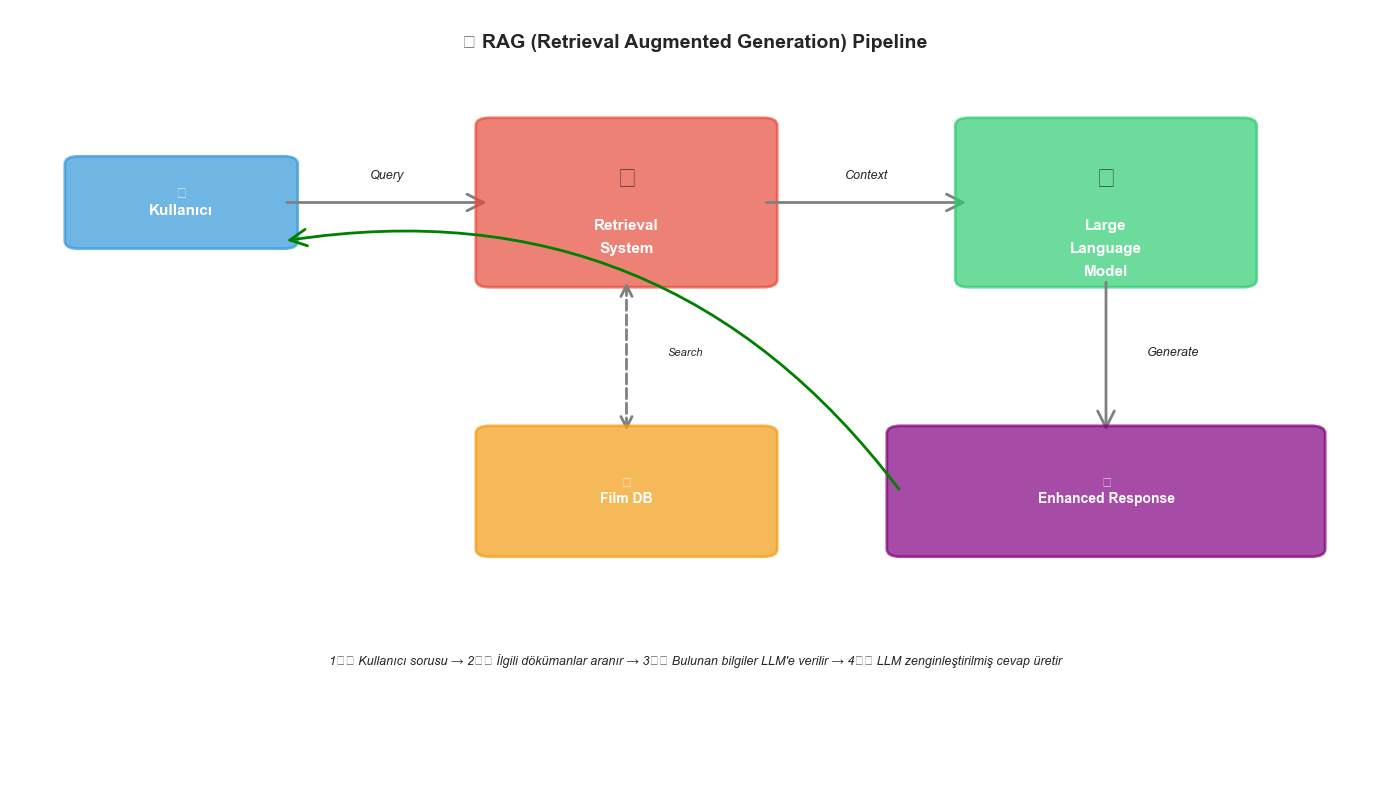

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def visualize_rag_pipeline():
    """
    🎨 RAG pipeline'ını görselleştir
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Renkler
    color_user = '#3498db'
    color_retrieval = '#e74c3c'
    color_llm = '#2ecc71'
    color_db = '#f39c12'
    
    # 1. Kullanıcı
    user_box = FancyBboxPatch((0.5, 7), 1.5, 1, 
                              boxstyle="round,pad=0.1", 
                              edgecolor=color_user, 
                              facecolor=color_user, 
                              alpha=0.7, 
                              linewidth=2)
    ax.add_patch(user_box)
    ax.text(1.25, 7.5, '👤\nKullanıcı', ha='center', va='center', 
            fontsize=11, fontweight='bold', color='white')
    
    # 2. Query
    arrow1 = FancyArrowPatch((2, 7.5), (3.5, 7.5),
                            arrowstyle='->', mutation_scale=30, 
                            linewidth=2, color='gray')
    ax.add_patch(arrow1)
    ax.text(2.75, 7.8, 'Query', ha='center', fontsize=9, style='italic')
    
    # 3. Retrieval System
    retrieval_box = FancyBboxPatch((3.5, 6.5), 2, 2,
                                   boxstyle="round,pad=0.1",
                                   edgecolor=color_retrieval,
                                   facecolor=color_retrieval,
                                   alpha=0.7,
                                   linewidth=2)
    ax.add_patch(retrieval_box)
    ax.text(4.5, 7.7, '🔍', ha='center', fontsize=20)
    ax.text(4.5, 7.2, 'Retrieval', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(4.5, 6.9, 'System', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    
    # 4. Database bağlantısı
    arrow_db = FancyArrowPatch((4.5, 6.5), (4.5, 4.5),
                              arrowstyle='<->', mutation_scale=20,
                              linewidth=2, color='gray', linestyle='--')
    ax.add_patch(arrow_db)
    ax.text(4.8, 5.5, 'Search', ha='left', fontsize=8, style='italic')
    
    # 5. Database
    db_box = FancyBboxPatch((3.5, 3), 2, 1.5,
                           boxstyle="round,pad=0.1",
                           edgecolor=color_db,
                           facecolor=color_db,
                           alpha=0.7,
                           linewidth=2)
    ax.add_patch(db_box)
    ax.text(4.5, 3.75, '🎬\nFilm DB', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    
    # 6. Retrieved Docs
    arrow2 = FancyArrowPatch((5.5, 7.5), (7, 7.5),
                            arrowstyle='->', mutation_scale=30,
                            linewidth=2, color='gray')
    ax.add_patch(arrow2)
    ax.text(6.25, 7.8, 'Context', ha='center', fontsize=9, style='italic')
    
    # 7. LLM
    llm_box = FancyBboxPatch((7, 6.5), 2, 2,
                            boxstyle="round,pad=0.1",
                            edgecolor=color_llm,
                            facecolor=color_llm,
                            alpha=0.7,
                            linewidth=2)
    ax.add_patch(llm_box)
    ax.text(8, 7.7, '🤖', ha='center', fontsize=20)
    ax.text(8, 7.2, 'Large', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(8, 6.9, 'Language', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(8, 6.6, 'Model', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    
    # 8. Response
    arrow3 = FancyArrowPatch((8, 6.5), (8, 4.5),
                            arrowstyle='->', mutation_scale=30,
                            linewidth=2, color='gray')
    ax.add_patch(arrow3)
    ax.text(8.3, 5.5, 'Generate', ha='left', fontsize=9, style='italic')
    
    # 9. Response Box
    response_box = FancyBboxPatch((6.5, 3), 3, 1.5,
                                 boxstyle="round,pad=0.1",
                                 edgecolor='purple',
                                 facecolor='purple',
                                 alpha=0.7,
                                 linewidth=2)
    ax.add_patch(response_box)
    ax.text(8, 3.75, '💬\nEnhanced Response', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    
    # 10. Back to User
    arrow4 = FancyArrowPatch((6.5, 3.75), (2, 7),
                            arrowstyle='->', mutation_scale=30,
                            linewidth=2, color='green',
                            connectionstyle="arc3,rad=0.3")
    ax.add_patch(arrow4)
    
    # Başlık
    ax.text(5, 9.5, '🔄 RAG (Retrieval Augmented Generation) Pipeline',
            ha='center', fontsize=14, fontweight='bold')
    
    # Açıklamalar
    ax.text(5, 1.5, 
            '1️⃣ Kullanıcı sorusu → 2️⃣ İlgili dökümanlar aranır → 3️⃣ Bulunan bilgiler LLM\'e verilir → 4️⃣ LLM zenginleştirilmiş cevap üretir',
            ha='center', fontsize=9, style='italic', wrap=True)
    
    plt.tight_layout()
    plt.show()


# 🎨 Görselleştirmeyi çalıştır
visualize_rag_pipeline()

## 🏗️ Adım 3: Sınıf Tabanlı RAG Chatbot

Profesyonel bir RAG sistemi için tüm özellikleri birleştiren bir sınıf oluşturalım:

In [25]:
class MovieRAGChatbot:
    """
    🎬 Film önerisi yapan RAG tabanlı chatbot sınıfı
    
    Özellikler:
    - TF-IDF tabanlı arama
    - Konuşma geçmişi yönetimi
    - Film öneri sistemi
    - İstatistik takibi
    """
    
    def __init__(self, movies_df: pd.DataFrame, search_method: str = "tfidf"):
        """
        Chatbot'u başlat
        
        Args:
            movies_df: Film veri seti
            search_method: "simple" veya "tfidf"
        """
        # 🎬 Film veri seti
        self.movies_df = prepare_movie_documents(movies_df.copy())
        self.search_method = search_method
        
        # 💬 Konuşma geçmişi
        self.conversation_history = [
            {
                "role": "system",
                "content": """Sen film konusunda uzman bir asistansın. 
Kullanıcılara özel film önerileri yapıyor ve film hakkında detaylı bilgi veriyorsun.
Sadece veritabanındaki filmlerden öneride bulunursun.
Dostane, samimi ve yardımsever bir üslup kullanırsın."""
            }
        ]
        
        # 📊 İstatistikler
        self.total_queries = 0
        self.total_recommendations = 0
        self.search_scores = []
        
        # 🔧 TF-IDF vectorizer (sadece tfidf için)
        if search_method == "tfidf":
            self.vectorizer = TfidfVectorizer(lowercase=True, max_features=1000)
            documents = self.movies_df['document'].tolist()
            self.tfidf_matrix = self.vectorizer.fit_transform(documents)
        
        print(f"✅ MovieRAGChatbot başlatıldı!")
        print(f"   • Film sayısı: {len(self.movies_df)}")
        print(f"   • Arama metodu: {search_method}")
    
    def _search_movies(self, query: str, top_k: int = 3) -> list:
        """İlgili filmleri ara"""
        if self.search_method == "simple":
            return simple_rag_search(query, self.movies_df, top_k)
        else:
            # TF-IDF arama (optimize edilmiş)
            query_vector = self.vectorizer.transform([query])
            similarities = cosine_similarity(query_vector, self.tfidf_matrix)[0]
            top_indices = similarities.argsort()[-top_k:][::-1]
            
            results = []
            for idx in top_indices:
                if similarities[idx] > 0:
                    movie = self.movies_df.iloc[idx].to_dict()
                    movie['similarity_score'] = float(similarities[idx])
                    results.append(movie)
            
            return results
    
    def chat(self, user_message: str, top_k: int = 3, verbose: bool = False) -> str:
        """
        Kullanıcı mesajına film önerisi yap
        
        Args:
            user_message: Kullanıcının mesajı
            top_k: Maksimum öneri sayısı
            verbose: Detaylı bilgi göster
            
        Returns:
            str: Bot'un cevabı
        """
        # 📊 İstatistik güncelle
        self.total_queries += 1
        
        # 🔍 İlgili filmleri bul
        relevant_movies = self._search_movies(user_message, top_k)
        self.total_recommendations += len(relevant_movies)
        
        # 📄 Context oluştur
        context = format_movie_context(relevant_movies)
        
        # 💬 Kullanıcı mesajı + Context
        user_message_with_context = f"""
{context}

KULLANICI SORUSU: {user_message}

Lütfen yukarıdaki filmlerden yola çıkarak kullanıcıya yardımcı ol.
"""
        
        # 📝 Geçmişe ekle
        self.conversation_history.append({
            "role": "user",
            "content": user_message_with_context
        })
        
        try:
            # 🤖 API çağrısı
            response = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=self.conversation_history,
                max_tokens=600,
                temperature=0.7
            )
            
            bot_reply = response.choices[0].message.content
            
            # 📝 Bot cevabını geçmişe ekle
            self.conversation_history.append({
                "role": "assistant",
                "content": bot_reply
            })
            
            # 📊 Verbose mod
            if verbose and relevant_movies:
                avg_score = sum(m.get('similarity_score', 0) for m in relevant_movies) / len(relevant_movies)
                self.search_scores.append(avg_score)
                
                print(f"\n📊 Arama İstatistikleri:")
                print(f"   • Bulunan film: {len(relevant_movies)}")
                print(f"   • Ortalama benzerlik: {avg_score:.3f}")
                print(f"   • Token kullanımı: {response.usage.total_tokens}")
            
            return bot_reply
            
        except Exception as e:
            return f"❌ Hata: {str(e)}"
    
    def get_stats(self) -> dict:
        """İstatistikleri döndür"""
        return {
            "total_queries": self.total_queries,
            "total_recommendations": self.total_recommendations,
            "avg_recommendations_per_query": round(self.total_recommendations / max(self.total_queries, 1), 2),
            "avg_search_score": round(sum(self.search_scores) / max(len(self.search_scores), 1), 3) if self.search_scores else 0.0,
            "conversation_length": len(self.conversation_history)
        }
    
    def reset_conversation(self):
        """Konuşma geçmişini sıfırla"""
        system_msg = self.conversation_history[0]
        self.conversation_history = [system_msg]
        print("🧹 Konuşma geçmişi sıfırlandı!")
    
    def recommend_by_genre(self, genre: str, top_k: int = 3) -> list:
        """Türe göre film öner"""
        genre_movies = self.movies_df[
            self.movies_df['genre'].str.contains(genre, case=False, na=False)
        ].nlargest(top_k, 'rating')
        
        return genre_movies.to_dict('records')
    
    def recommend_by_year(self, start_year: int, end_year: int, top_k: int = 3) -> list:
        """Yıl aralığına göre film öner"""
        year_movies = self.movies_df[
            (self.movies_df['year'] >= start_year) & 
            (self.movies_df['year'] <= end_year)
        ].nlargest(top_k, 'rating')
        
        return year_movies.to_dict('records')


# 🤖 Chatbot oluştur
print("="*80)
print("🚀 MOVİERAGCHATBOT - SINIF TABANLI RAG SİSTEMİ")
print("="*80 + "\n")

movie_bot = MovieRAGChatbot(movies_df, search_method="tfidf")

print("\n" + "="*80)

# 🎬 Test senaryoları
test_conversations = [
    "Merhaba! Aksiyon dolu bir film önerir misin?",
    "Peki bilim kurgu?",
    "Christopher Nolan'ın hangi filmleri var?",
    "1990'larda çıkan iyi filmler?"
]

for msg in test_conversations:
    print(f"\n👤 Kullanıcı: {msg}")
    print("-" * 80)
    response = movie_bot.chat(msg, top_k=3, verbose=True)
    print(f"\n🤖 Bot: {response}")
    print("\n" + "="*80)

# 📊 Özet istatistikler
print("\n📈 ÖZET İSTATİSTİKLER:")
stats = movie_bot.get_stats()
for key, value in stats.items():
    print(f"   • {key}: {value}")

print("\n" + "="*80)

🚀 MOVİERAGCHATBOT - SINIF TABANLI RAG SİSTEMİ

✅ MovieRAGChatbot başlatıldı!
   • Film sayısı: 10
   • Arama metodu: tfidf


👤 Kullanıcı: Merhaba! Aksiyon dolu bir film önerir misin?
--------------------------------------------------------------------------------

📊 Arama İstatistikleri:
   • Bulunan film: 3
   • Ortalama benzerlik: 0.210
   • Token kullanımı: 729

🤖 Bot: Tabii ki! Sana aksiyon dolu bir film önerisi yapabilirim. "Başlangıç" (Inception - 2010) filmi, hem aksiyon dolu sahneleri hem de zekice kurgulanmış senaryosuyla dikkat çekiyor. Rüyalara sızabilen bir hırsızın, zihinlere fikir yerleştirmek için aldığı görevi konu alıyor. Yönetmenliğini usta isim Christopher Nolan'ın üstlendiği bu filmde, Leonardo DiCaprio ve Marion Cotillard gibi başarılı oyuncular yer alıyor. IMDb puanı 8.8 olan "Başlangıç", aksiyon ve gerilim seven izleyiciler için harika bir seçenek olabilir. Keyifli seyirler! 🎥🍿


👤 Kullanıcı: Peki bilim kurgu?
-----------------------------------------------------

## 📚 Best Practices: RAG Sistemleri İçin Öneriler

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin: 20px 0;">

<div style="background-color: #e3f2fd; padding: 15px; border-radius: 8px; border-left: 5px solid #2196F3;">
<h4 style="margin-top: 0;">🔍 Retrieval Kalitesi</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 14px;">
<li>Doğru chunk size seçin (너무 küçük/büyük olmasın)</li>
<li>Overlap kullanın (chunk'lar arasında)</li>
<li>Metadata ekleyin (tarih, kaynak, kategori)</li>
<li>Hybrid search kullanın (keyword + semantic)</li>
</ul>
</div>

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 5px solid #ffc107;">
<h4 style="margin-top: 0;">⚡ Performans</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 14px;">
<li>Embedding'leri önbelleğe alın</li>
<li>Vector database kullanın (Pinecone, Weaviate)</li>
<li>Batch processing yapın</li>
<li>Gereksiz retrieval'dan kaçının</li>
</ul>
</div>

<div style="background-color: #f3e5f5; padding: 15px; border-radius: 8px; border-left: 5px solid #9c27b0;">
<h4 style="margin-top: 0;">📊 Context Yönetimi</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 14px;">
<li>Relevance threshold belirleyin</li>
<li>Sadece en ilgili dökümanları kullanın</li>
<li>Context window'u aşmayın</li>
<li>Reranking uygulayın</li>
</ul>
</div>

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #4caf50;">
<h4 style="margin-top: 0;">✅ Kalite Kontrolü</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 14px;">
<li>Kaynak gösterimi yapın</li>
<li>Hallucination kontrolü</li>
<li>Kullanıcı feedback'i toplayın</li>
<li>A/B testing yapın</li>
</ul>
</div>

</div>

---

## 🎯 Pratik Egzersiz: Kendi RAG Sisteminizi Geliştirin

<div style="background-color: #e8f5e9; padding: 20px; border-left: 5px solid #4caf50; border-radius: 5px; margin: 15px 0;">
<h3 style="margin-top: 0;">📝 Görev</h3>
<p>MovieRAGChatbot sınıfını genişletin ve şu özellikleri ekleyin:</p>
<ol>
<li><strong>Filtreleme</strong>: Kullanıcı min/max puan belirleyebilsin</li>
<li><strong>Multi-genre</strong>: Birden fazla türü arayabilsin</li>
<li><strong>Director Search</strong>: Yönetmene göre özel arama</li>
<li><strong>Export History</strong>: Konuşma geçmişini JSON'a kaydet</li>
</ol>
</div>

In [26]:
# 💪 Buraya kendi kodunuzu yazın!

class AdvancedMovieRAGChatbot(MovieRAGChatbot):
    """
    🎨 Gelişmiş özelliklerle genişletilmiş RAG chatbot
    
    TODO: Aşağıdaki özellikleri ekleyin:
    - recommend_by_rating(min_rating, max_rating)
    - search_multi_genre(genres: list)
    - search_by_director(director_name)
    - export_conversation_history(filename)
    """
    
    def __init__(self, movies_df, **kwargs):
        super().__init__(movies_df, **kwargs)
        print("✨ Gelişmiş özellikler aktif!")
    
    # 🔧 Yeni metodlarınızı buraya ekleyin!
    
    pass


# 🧪 Test kodunuzu buraya yazın

## 🎯 Adım 4 Özeti: Ne Öğrendik?

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 30px 0;">
    <h3 style="margin: 0; color: white;">✅ Tamamlanan Konular</h3>
    <ul style="line-height: 1.8; font-size: 15px; margin: 15px 0;">
        <li>🎬 <strong>Film Veri Seti</strong> - IMDb verileri ile çalışma</li>
        <li>🔍 <strong>RAG Mimarisi</strong> - Retrieval Augmented Generation konsepti</li>
        <li>📊 <strong>Arama Yöntemleri</strong> - Basit kelime eşleşme vs TF-IDF</li>
        <li>📄 <strong>Context Injection</strong> - Dinamik bilgi ekleme</li>
        <li>🏗️ <strong>Sınıf Tabanlı RAG</strong> - MovieRAGChatbot sistemi</li>
        <li>📈 <strong>Performans Takibi</strong> - Arama kalitesi ve istatistikler</li>
        <li>🎨 <strong>Görselleştirme</strong> - RAG pipeline diagramı</li>
    </ul>
</div>

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; margin: 30px 0;">
    <h2 style="margin: 0; color: white;">🎉 Harika! Adım 4 Tamamlandı!</h2>
    <p style="margin: 10px 0 0 0; font-size: 16px;">Artık RAG tabanlı akıllı chatbot'lar oluşturabiliyorsunuz! 🔍✨</p>
</div>

---

### 🔜 Sıradaki Adım: İleri Seviye Özellikler

Adım 5'te öğrenecekleriniz:
- 🎭 **Advanced Personas**: Karmaşık karakter tanımları
- ⚙️ **Parameter Tuning**: temperature, top_p, frequency_penalty
- 💰 **Token Optimization**: Maliyet azaltma teknikleri
- 🌊 **Streaming**: Gerçek zamanlı cevap akışı
- 🔧 **Function Calling**: Chatbot'a özel yetenekler kazandırma

**Hazır mısınız? Hadi devam edelim! 🚀**

# ⚡ Adım 5: İleri Seviye Özellikler

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; margin: 20px 0;">
    <h2 style="margin: 0; color: white;">🚀 Chatbot Performansını Maksimize Edin</h2>
    <p style="margin: 10px 0 0 0;">Bu adımda chatbot'unuzu profesyonel seviyeye taşıyacak ileri seviye özellikleri öğreneceksiniz. Token optimizasyonu, streaming, gelişmiş parametreler ve daha fazlası!</p>
</div>

## 🎯 Bu Adımda Öğrenecekleriniz

- 🎭 **Advanced Personas**: Karmaşık karakter ve rol tanımları
- ⚙️ **Parameter Tuning**: temperature, top_p, frequency_penalty, presence_penalty
- 💰 **Token Optimization**: Maliyet azaltma stratejileri
- 🌊 **Streaming Responses**: Gerçek zamanlı cevap akışı
- 🔧 **Function Calling**: Chatbot'a özel yetenekler kazandırma
- 📊 **Advanced Metrics**: Detaylı performans ölçümleri

---

## 🎭 Gelişmiş Persona Engineering

<div style="background-color: #e3f2fd; padding: 15px; border-left: 5px solid #2196F3; border-radius: 5px; margin: 15px 0;">
<strong>💡 Persona Nedir?</strong><br><br>
Persona, chatbot'un <strong>karakter</strong>, <strong>ton</strong>, <strong>bilgi seviyesi</strong> ve <strong>davranış şeklini</strong> belirleyen system mesajıdır. İyi tasarlanmış bir persona, kullanıcı deneyimini dramatik şekilde iyileştirir.
</div>

### 📝 Persona Tasarım Prensipleri

<table style="width: 100%; border-collapse: collapse; margin: 20px 0;">
<tr style="background-color: #f5f5f5;">
<th style="padding: 12px; border: 1px solid #ddd;">Element</th>
<th style="padding: 12px; border: 1px solid #ddd;">Açıklama</th>
<th style="padding: 12px; border: 1px solid #ddd;">Örnek</th>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>Rol</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Kim olduğu</td>
<td style="padding: 10px; border: 1px solid #ddd;">"Senior Python Developer"</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>Uzmanlık</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Bilgi alanı</td>
<td style="padding: 10px; border: 1px solid #ddd;">"Machine Learning ve NLP"</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>Ton</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Konuşma tarzı</td>
<td style="padding: 10px; border: 1px solid #ddd;">"Dostane ama profesyonel"</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>Kısıtlamalar</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Ne yapmaması gerektiği</td>
<td style="padding: 10px; border: 1px solid #ddd;">"Kesinlikle finansal tavsiye verme"</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>Format</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Cevap yapısı</td>
<td style="padding: 10px; border: 1px solid #ddd;">"Önce özet, sonra detay"</td>
</tr>
</table>

## 🎨 Örnek: Gelişmiş Persona Tanımları

In [27]:
# 🎭 Gelişmiş persona tanımları

ADVANCED_PERSONAS = {
    "code_mentor": {
        "emoji": "👨‍💻",
        "name": "Kod Mentoru",
        "system_message": """Sen deneyimli bir yazılım mimarı ve kod mentörüsün.

UZMANLIK ALANLARIN:
- Python, JavaScript, ve modern web teknolojileri
- Clean Code, SOLID prensipleri, Design Patterns
- Code review ve best practices

YAKLAŞIMIN:
1. Önce soruyu anla ve doğrula
2. Temel konsepti açıkla
3. Kod örneği ver (yorumlu)
4. Alternatif yaklaşımları göster
5. Potansiyel hataları belirt

TON: Sabırlı, destekleyici, detaylı ama gereksiz jargon kullanma

KISITLAMALAR:
- Deprecated teknolojiler önerme
- "Sadece çalışan" kod yerine "sürdürülebilir kod" yaz
- Security best practices'i her zaman vurgula""",
        "temperature": 0.3,  # Daha tutarlı kod önerileri
        "max_tokens": 800
    },
    
    "creative_writer": {
        "emoji": "✍️",
        "name": "Yaratıcı Yazar",
        "system_message": """Sen ödüllü bir yaratıcı yazarsın.

YAZIM STİLİN:
- Betimleyici ve canlı dil kullan
- Metaforlar ve benzetmeler yap
- Duygusal bağlantı kur
- Okuyucunun hayal gücünü tetikle

YAKLASIMIN:
1. Konunun duygusal tonunu yakala
2. Beklenmedik perspektifler sun
3. Görsel ve duyusal detaylar ekle
4. Ritim ve akış oluştur

TON: Şiirsel, ilham verici, özgün

FORMAT:
- Kısa paragraflar kullan
- Güçlü açılış ve kapanış cümleleri
- Aktif fiiller tercih et""",
        "temperature": 0.9,  # Daha yaratıcı çıktılar
        "max_tokens": 600
    },
    
    "data_scientist": {
        "emoji": "📊",
        "name": "Veri Bilimci",
        "system_message": """Sen senior data scientist ve ML engineer'sın.

UZMANLIK:
- Statistical analysis ve hypothesis testing
- Machine Learning (supervised/unsupervised)
- Deep Learning (CNN, RNN, Transformers)
- Data visualization ve storytelling

YAKLASIMIN:
1. Problemi tanımla (classification/regression/clustering)
2. Veri analizi öner (EDA)
3. Uygun modelleri açıkla
4. Metrikleri belirt (accuracy, precision, recall, F1)
5. İyileştirme önerileri sun

TON: Analitik, data-driven, açık

FORMAT:
- Matematiksel notasyondan çekinme
- Görselleştirme öner
- Trade-off'ları açıkla (accuracy vs speed)
- Code snippet'leri pandas/numpy/sklearn ile ver""",
        "temperature": 0.4,
        "max_tokens": 700
    },
    
    "business_consultant": {
        "emoji": "💼",
        "name": "İş Danışmanı",
        "system_message": """Sen deneyimli bir business strategy consultant'sın.

UZMANLIK:
- Business strategy ve planning
- Market analysis ve competitive intelligence
- Financial modeling ve ROI analysis
- Change management

FRAMEWORK'LER:
- SWOT Analysis
- Porter's Five Forces
- Business Model Canvas
- OKR (Objectives and Key Results)

YAKLASIMIN:
1. Mevcut durumu analiz et
2. Fırsatları ve riskleri belirle
3. Actionable recommendations ver
4. ROI/KPI'ları tanımla
5. Implementation roadmap çiz

TON: Profesyonel, stratejik, pragmatik

FORMAT:
- Executive summary ile başla
- Bullet points kullan
- Sayısal verilerle destekle
- Timeline öner""",
        "temperature": 0.5,
        "max_tokens": 700
    },
    
    "health_coach": {
        "emoji": "🏋️",
        "name": "Sağlık Koçu",
        "system_message": """Sen sertifikalı bir fitness trainer ve nutrition coach'sın.

UZMANLIK:
- Exercise physiology ve workout design
- Nutrition planning ve meal prep
- Habit formation ve motivation
- Injury prevention

YAKLASIMIN:
1. Kişisel durumu anla (age, fitness level, goals)
2. Realistic hedefler belirle
3. Kademeli program öner
4. Motivasyon stratejileri ver
5. Progress tracking yöntemleri sun

TON: Motivasyonel, pozitif, destekleyici

KISITLAMALAR:
- Medical diagnosis YAPMA
- Extreme diets önerme
- Her tavsiyeden önce "doktoruna danış" de
- Safety her zaman öncelik

FORMAT:
- Günlük/haftalık planlar
- Alternatifler sun
- Başarı ölçümlerini tanımla""",
        "temperature": 0.6,
        "max_tokens": 600
    }
}


def demo_advanced_personas():
    """
    🎭 Gelişmiş personaları test et
    """
    print("="*80)
    print("🎭 GELİŞMİŞ PERSONA DEMONSTRATİONI")
    print("="*80)
    
    # Her persona için örnek soru
    test_cases = {
        "code_mentor": "Python'da decorator nedir ve ne zaman kullanmalıyım?",
        "creative_writer": "Sonbahar mevsimini betimle",
        "data_scientist": "Bir classification problemi için hangi metrikleri kullanmalıyım?",
        "business_consultant": "Yeni bir SaaS startup için go-to-market stratejisi öner",
        "health_coach": "Yeni başlayan biri için 30 günlük fitness planı"
    }
    
    for persona_key, question in test_cases.items():
        persona = ADVANCED_PERSONAS[persona_key]
        
        print(f"\n{'='*80}")
        print(f"{persona['emoji']} {persona['name'].upper()}")
        print(f"{'='*80}")
        print(f"\n👤 Soru: {question}\n")
        print(f"⚙️  Temperature: {persona['temperature']} | Max Tokens: {persona['max_tokens']}")
        print(f"\n💬 Cevap:\n")
        print("-" * 80)
        
        # 🤖 Gerçek API çağrısı
        try:
            response = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=[
                    {"role": "system", "content": persona["system_message"]},
                    {"role": "user", "content": question}
                ],
                temperature=persona["temperature"],
                max_tokens=persona["max_tokens"]
            )
            print(f"\n{response.choices[0].message.content}\n")
            print("-" * 80)
            print(f"📊 Token kullanımı: {response.usage.total_tokens}")
        except Exception as e:
            print(f"❌ Hata: {e}")
    
    print("\n" + "="*80)
    print("✅ Tüm persona testleri tamamlandı!")
    print("="*80)


# 🎨 Persona listesini göster
print("📋 Mevcut Gelişmiş Personalar:\n")
for key, persona in ADVANCED_PERSONAS.items():
    print(f"{persona['emoji']} {persona['name']}")
    print(f"   • Temperature: {persona['temperature']}")
    print(f"   • Max Tokens: {persona['max_tokens']}")
    
    # Özellik bilgisini daha güvenli şekilde al
    if 'UZMANLIK' in persona['system_message']:
        try:
            feature = persona['system_message'].split('UZMANLIK')[1].split(':')[1].split('\n')[1].strip()
        except:
            feature = "Özel yaklaşım"
    else:
        feature = "Yaratıcı yazım"
    
    print(f"   • Özellik: {feature}")
    print()

# Demo çalıştır
demo_advanced_personas()

📋 Mevcut Gelişmiş Personalar:

👨‍💻 Kod Mentoru
   • Temperature: 0.3
   • Max Tokens: 800
   • Özellik: - Python, JavaScript, ve modern web teknolojileri

✍️ Yaratıcı Yazar
   • Temperature: 0.9
   • Max Tokens: 600
   • Özellik: Yaratıcı yazım

📊 Veri Bilimci
   • Temperature: 0.4
   • Max Tokens: 700
   • Özellik: - Statistical analysis ve hypothesis testing

💼 İş Danışmanı
   • Temperature: 0.5
   • Max Tokens: 700
   • Özellik: - Business strategy ve planning

🏋️ Sağlık Koçu
   • Temperature: 0.6
   • Max Tokens: 600
   • Özellik: - Exercise physiology ve workout design

🎭 GELİŞMİŞ PERSONA DEMONSTRATİONI

👨‍💻 KOD MENTORU

👤 Soru: Python'da decorator nedir ve ne zaman kullanmalıyım?

⚙️  Temperature: 0.3 | Max Tokens: 800

💬 Cevap:

--------------------------------------------------------------------------------

Tabii, decoratorlar Python'da oldukça güçlü ve yaygın kullanılan bir konsepttir. Bir fonksiyonu veya metodu değiştirmek veya genişletmek için kullanılırlar. Bir fonksiyonu 

## ⚙️ API Parametreleri: Detaylı Rehber

<div style="background-color: #fff3cd; padding: 15px; border-left: 5px solid #ffc107; border-radius: 5px; margin: 15px 0;">
<strong>⚠️ Önemli:</strong><br>
Parametreleri doğru ayarlamak chatbot'un kalitesini ve maliyetini doğrudan etkiler!
</div>

### 🎛️ Temel Parametreler

#### 1. **temperature** (0.0 - 2.0)

<div style="background-color: #f5f5f5; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Ne İşe Yarar:** Modelin yaratıcılığını/rastgeleliğini kontrol eder.

- **0.0 - 0.3**: Deterministik, tutarlı, teknik cevaplar
  - ✅ Kullanım: Kod üretimi, matematik, faktual sorular
  - ❌ Kullanma: Yaratıcı yazım, beyin fırtınası

- **0.4 - 0.7**: Dengeli yaklaşım (varsayılan genelde 0.7)
  - ✅ Kullanım: Genel chatbot, Q&A, customer support
  
- **0.8 - 2.0**: Yüksek yaratıcılık, çeşitlilik, risk
  - ✅ Kullanım: Creative writing, brainstorming, hikaye
  - ❌ Kullanma: Kritik business logic, code generation

</div>

#### 2. **max_tokens**

<div style="background-color: #f5f5f5; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Ne İşe Yarar:** Oluşturulacak maksimum token sayısı.

- **50-150**: Kısa cevaplar, özetler
- **200-500**: Orta uzunlukta açıklamalar
- **500-1000**: Detaylı cevaplar, tutorial'lar
- **1000+**: Uzun içerik, makaleler

💰 **Maliyet İpucu:** Daha düşük max_tokens = daha az maliyet, ama cevap kesilebilir!

</div>

#### 3. **top_p** (nucleus sampling, 0.0 - 1.0)

<div style="background-color: #f5f5f5; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Ne İşe Yarar:** Olasılık kümülatif dağılımını keser.

- **0.1**: Sadece en olası token'lar (çok tutarlı)
- **0.5**: Orta düzey filtreleme
- **0.9-1.0**: Geniş token seçimi (varsayılan 1.0)

⚡ **Best Practice:** Temperature VEYA top_p kullanın, ikisini birden değil!

</div>

#### 4. **frequency_penalty** (-2.0 - 2.0)

<div style="background-color: #f5f5f5; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Ne İşe Yarar:** Kelime tekrarını azaltır/artırır.

- **-2.0 - 0.0**: Tekrara izin ver
- **0.0**: Nötr (varsayılan)
- **0.1 - 1.0**: Tekrarı azalt (önerilen: 0.5-0.8)
- **1.0 - 2.0**: Tekrarı agresif şekilde engelle

✅ **Kullanım:** Uzun metinlerde çeşitlilik için artır

</div>

#### 5. **presence_penalty** (-2.0 - 2.0)

<div style="background-color: #f5f5f5; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Ne İşe Yarar:** Yeni topic'lere geçişi teşvik eder.

- **0.0**: Nötr (varsayılan)
- **0.1 - 1.0**: Yeni konulara geç
- **1.0 - 2.0**: Agresif topic değişimi

✅ **Kullanım:** Brainstorming, çeşitli fikirler üretme

</div>

## 🧪 Parametre Etkilerini Test Edelim

In [28]:
def test_parameter_effects(prompt: str, parameter_name: str, values: list):
    """
    🧪 Farklı parametre değerlerinin etkisini test et
    
    Args:
        prompt: Test prompt'u
        parameter_name: Test edilecek parametre
        values: Test edilecek değerler listesi
    """
    print("="*80)
    print(f"🧪 PARAMETRE TEST: {parameter_name.upper()}")
    print("="*80)
    print(f"\n📝 Test Prompt: \"{prompt}\"\n")
    
    results = []
    
    for value in values:
        print(f"\n{'─'*80}")
        print(f"⚙️  {parameter_name} = {value}")
        print(f"{'─'*80}\n")
        
        # Parametreleri hazırla
        params = {
            "model": OPENAI_MODEL,
            "messages": [{"role": "user", "content": prompt}],
            "max_tokens": 150
        }
        
        # Test edilecek parametreyi ekle
        if parameter_name == "temperature":
            params["temperature"] = value
        elif parameter_name == "top_p":
            params["top_p"] = value
            params["temperature"] = 1.0  # top_p ile birlikte
        elif parameter_name == "frequency_penalty":
            params["frequency_penalty"] = value
            params["temperature"] = 0.7
        elif parameter_name == "presence_penalty":
            params["presence_penalty"] = value
            params["temperature"] = 0.7
        
        try:
            response = client.chat.completions.create(**params)
            reply = response.choices[0].message.content
            tokens = response.usage.total_tokens
            
            print(f"💬 Cevap: {reply}")
            print(f"\n📊 Token: {tokens}")
            
            results.append({
                "value": value,
                "reply": reply,
                "tokens": tokens,
                "length": len(reply)
            })
            
        except Exception as e:
            print(f"❌ Hata: {e}")
            results.append({"value": value, "error": str(e)})
    
    print("\n" + "="*80)
    print("📊 KARŞILAŞTIRMA")
    print("="*80)
    
    for result in results:
        if "error" not in result:
            print(f"\n{parameter_name}={result['value']}:")
            print(f"  • Uzunluk: {result['length']} karakter")
            print(f"  • Token: {result['tokens']}")
            print(f"  • İlk 50 karakter: {result['reply'][:50]}...")
    
    return results


# 🧪 Test 1: Temperature etkisi
print("\n🔬 TEST 1: TEMPERATURE ETKİSİ\n")
test_parameter_effects(
    prompt="Python'da liste comprehension nedir? Kısa açıkla.",
    parameter_name="temperature",
    values=[0.0, 0.5, 1.0, 1.5]
)

print("\n\n🔬 TEST 2: FREQUENCY_PENALTY ETKİSİ\n")
test_parameter_effects(
    prompt="Yapay zeka hakkında 3 cümle yaz.",
    parameter_name="frequency_penalty",
    values=[0.0, 0.5, 1.5]
)


🔬 TEST 1: TEMPERATURE ETKİSİ

🧪 PARAMETRE TEST: TEMPERATURE

📝 Test Prompt: "Python'da liste comprehension nedir? Kısa açıkla."


────────────────────────────────────────────────────────────────────────────────
⚙️  temperature = 0.0
────────────────────────────────────────────────────────────────────────────────

💬 Cevap: Liste comprehension, Python'da bir liste oluşturmak için kullanılan kısa ve etkili bir yöntemdir. Liste comprehension, bir döngü kullanarak liste elemanlarını tek satırda oluşturmayı sağlar. Bu yöntem, kodun daha okunabilir ve daha az satırda yazılmasını sağlar. Örneğin, bir liste içindeki her elemanın karesini almak için liste comprehension kullanılabilir.

📊 Token: 131

────────────────────────────────────────────────────────────────────────────────
⚙️  temperature = 0.5
────────────────────────────────────────────────────────────────────────────────

💬 Cevap: Liste comprehension, Python'da bir liste oluşturmak için kullanılan kısa ve pratik bir yöntemdir. Bu yönte

[{'value': 0.0,
  'reply': '1. Yapay zeka, bilgisayar sistemlerinin insan benzeri düşünme ve öğrenme yeteneklerini simüle etmek için kullanılan bir teknolojidir.\n2. Yapay zeka, veri analizi, tahmin yapma, otomatik karar verme gibi alanlarda insanları destekleyen ve işlerini kolaylaştıran bir araçtır.\n3. Yapay zeka, günümüzde birçok sektörde kullanılarak verimliliği artırırken, gelecekte daha da gelişerek insan hayatını önemli öl',
  'tokens': 172,
  'length': 404},
 {'value': 0.5,
  'reply': '1. Yapay zeka, insan benzeri düşünme ve öğrenme yeteneklerine sahip bilgisayar sistemlerinin geliştirilmesiyle ilgilenen bir alandır.\n\n2. Günümüzde yapay zeka teknolojileri, birçok farklı sektörde kullanılarak verimliliği arttırmak ve insan hayatını kolaylaştırmak için çeşitli uygulamalara sahiptir.\n\n3. Yapay zeka, makine öğrenmesi ve derin öğrenme gibi alt alanlarla birlikte',
  'tokens': 172,
  'length': 378},
 {'value': 1.5,
  'reply': '1. Yapay zeka, bilgisayar sistemlerinin insan benzer

## 🎴 Flashcard: Parametre Seçim Rehberi

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 15px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 20px 0;">
    <h3 style="margin: 0; color: white;">🎯 Hangi Senaryo İçin Hangi Ayarlar?</h3>
    <hr style="border: 1px solid rgba(255,255,255,0.3); margin: 10px 0;">
    
<table style="width: 100%; border-collapse: collapse; background: white; color: #333; border-radius: 8px; overflow: hidden; margin-top: 10px;">
<tr style="background-color: #f5f5f5;">
<th style="padding: 10px; text-align: left;">Senaryo</th>
<th style="padding: 10px; text-align: left;">Temperature</th>
<th style="padding: 10px; text-align: left;">Penalties</th>
<th style="padding: 10px; text-align: left;">Max Tokens</th>
</tr>
<tr>
<td style="padding: 8px; border-bottom: 1px solid #eee;"><strong>Kod Üretimi</strong></td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">0.0 - 0.2</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">0.0</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">800+</td>
</tr>
<tr>
<td style="padding: 8px; border-bottom: 1px solid #eee;"><strong>Customer Support</strong></td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">0.5 - 0.7</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">0.0 - 0.3</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">200-400</td>
</tr>
<tr>
<td style="padding: 8px; border-bottom: 1px solid #eee;"><strong>Creative Writing</strong></td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">0.8 - 1.2</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">0.5 - 0.8</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">500-1000</td>
</tr>
<tr>
<td style="padding: 8px; border-bottom: 1px solid #eee;"><strong>Brainstorming</strong></td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">1.0 - 1.5</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">0.6 (both)</td>
<td style="padding: 8px; border-bottom: 1px solid #eee;">300-600</td>
</tr>
<tr>
<td style="padding: 8px;"><strong>Özet Çıkarma</strong></td>
<td style="padding: 8px;">0.3 - 0.5</td>
<td style="padding: 8px;">0.0</td>
<td style="padding: 8px;">100-300</td>
</tr>
</table>

</div>

---

## 💰 Token Optimizasyonu Stratejileri

<div style="background-color: #e8f5e9; padding: 15px; border-left: 5px solid #4caf50; border-radius: 5px; margin: 15px 0;">
<strong>💡 Neden Önemli?</strong><br>
Token maliyeti API kullanımının en büyük giderlerinden biri. Akıllı optimizasyon ile %30-70 tasarruf sağlanabilir!
</div>

### 🎯 Optimizasyon Teknikleri

In [29]:
class TokenOptimizedChatbot:
    """
    💰 Token optimizasyonlu chatbot sınıfı
    
    Özellikler:
    - Akıllı system message yönetimi
    - Özetleme ile context yönetimi
    - Gereksiz token kullanımını azaltma
    - Maliyet takibi
    """
    
    def __init__(self, base_system_message: str, max_history_messages: int = 10):
        """
        Chatbot'u başlat
        
        Args:
            base_system_message: Temel system mesajı
            max_history_messages: Geçmişte saklanacak maks mesaj
        """
        self.base_system_message = base_system_message
        self.max_history_messages = max_history_messages
        
        # 📝 Konuşma geçmişi (system mesajı olmadan)
        self.conversation_history = []
        
        # 📊 Maliyet takibi
        self.total_input_tokens = 0
        self.total_output_tokens = 0
        self.total_cost = 0.0
        self.call_count = 0
        
        print(f"✅ TokenOptimizedChatbot başlatıldı!")
        print(f"   • Max geçmiş: {max_history_messages} mesaj")
    
    def _calculate_cost(self, input_tokens: int, output_tokens: int) -> float:
        """
        💰 Maliyet hesapla (gpt-3.5-turbo için)
        
        Güncel fiyat: $0.0005/1K input, $0.0015/1K output
        """
        input_cost = (input_tokens / 1000) * 0.0005
        output_cost = (output_tokens / 1000) * 0.0015
        return input_cost + output_cost
    
    def _summarize_old_context(self, messages: list) -> str:
        """
        📝 Eski mesajları özetle
        
        Args:
            messages: Özetlenecek mesajlar
            
        Returns:
            str: Özet
        """
        # Basit özet: Sadece ana noktaları al
        if len(messages) <= 2:
            return ""
        
        # Son birkaç mesajı birleştir
        combined = "\\n".join([
            f"{m['role']}: {m['content'][:100]}" 
            for m in messages[:3]
        ])
        
        summary_prompt = f"""Aşağıdaki konuşmayı 2-3 cümlede özetle:

{combined}

Özet:"""
        
        try:
            response = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=[{"role": "user", "content": summary_prompt}],
                max_tokens=100,
                temperature=0.3
            )
            return response.choices[0].message.content
        except:
            return "Önceki konuşma özeti mevcut değil."
    
    def _optimize_system_message(self, current_context: str = "") -> str:
        """
        ⚡ System mesajını optimize et
        
        Gereksiz kelimeleri çıkar, kısa ve öz yap
        """
        # Temel mesajı kısalt
        optimized = self.base_system_message.replace("\\n\\n", "\\n")
        optimized = " ".join(optimized.split())  # Fazla boşlukları temizle
        
        # Eğer context varsa, özet ekle
        if current_context:
            optimized += f"\\n\\nÖnceki konuşma özeti: {current_context}"
        
        return optimized
    
    def chat(self, user_message: str, verbose: bool = False) -> dict:
        """
        💬 Optimized chat
        
        Args:
            user_message: Kullanıcı mesajı
            verbose: Detaylı bilgi göster
            
        Returns:
            dict: Cevap ve istatistikler
        """
        self.call_count += 1
        
        # 📝 Mesaj geçmişini yönet
        self.conversation_history.append({
            "role": "user",
            "content": user_message
        })
        
        # 🧹 Geçmiş çok uzunsa, eski mesajları özetle
        context_summary = ""
        if len(self.conversation_history) > self.max_history_messages:
            # En eski mesajları özetle
            old_messages = self.conversation_history[:5]
            context_summary = self._summarize_old_context(old_messages)
            
            # Eski mesajları sil
            self.conversation_history = self.conversation_history[5:]
            
            if verbose:
                print(f"🧹 Eski mesajlar özetlendi: '{context_summary[:50]}...'")
        
        # ⚡ Optimize edilmiş system mesajı
        optimized_system = self._optimize_system_message(context_summary)
        
        # 📤 API çağrısı için mesajları hazırla
        api_messages = [{"role": "system", "content": optimized_system}]
        api_messages.extend(self.conversation_history)
        
        try:
            # 🤖 API çağrısı
            response = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=api_messages,
                max_tokens=400,
                temperature=0.7
            )
            
            bot_reply = response.choices[0].message.content
            input_tokens = response.usage.prompt_tokens
            output_tokens = response.usage.completion_tokens
            
            # 💰 Maliyet hesapla
            call_cost = self._calculate_cost(input_tokens, output_tokens)
            self.total_input_tokens += input_tokens
            self.total_output_tokens += output_tokens
            self.total_cost += call_cost
            
            # 📝 Bot cevabını geçmişe ekle
            self.conversation_history.append({
                "role": "assistant",
                "content": bot_reply
            })
            
            # 📊 Verbose
            if verbose:
                print(f"\\n📊 Bu çağrı:")
                print(f"   • Input tokens: {input_tokens}")
                print(f"   • Output tokens: {output_tokens}")
                print(f"   • Maliyet: ${call_cost:.5f}")
                print(f"   • Geçmiş uzunluğu: {len(self.conversation_history)} mesaj")
            
            return {
                "reply": bot_reply,
                "input_tokens": input_tokens,
                "output_tokens": output_tokens,
                "cost": call_cost,
                "total_cost": self.total_cost,
                "history_length": len(self.conversation_history)
            }
            
        except Exception as e:
            return {
                "reply": f"❌ Hata: {str(e)}",
                "error": True
            }
    
    def get_stats(self) -> dict:
        """📊 İstatistikleri döndür"""
        avg_input = self.total_input_tokens / max(self.call_count, 1)
        avg_output = self.total_output_tokens / max(self.call_count, 1)
        
        return {
            "total_calls": self.call_count,
            "total_input_tokens": self.total_input_tokens,
            "total_output_tokens": self.total_output_tokens,
            "total_tokens": self.total_input_tokens + self.total_output_tokens,
            "avg_input_per_call": round(avg_input, 1),
            "avg_output_per_call": round(avg_output, 1),
            "total_cost": round(self.total_cost, 4),
            "avg_cost_per_call": round(self.total_cost / max(self.call_count, 1), 5)
        }


# 🧪 Test edelim
print("="*80)
print("💰 TOKEN OPTİMİZE EDİLMİŞ CHATBOT")
print("="*80 + "\\n")

optimized_bot = TokenOptimizedChatbot(
    base_system_message="Sen yardımcı bir asistansın. Kısa ve öz cevaplar ver.",
    max_history_messages=8
)

# Birkaç mesaj gönder
test_messages = [
    "Merhaba! Python nedir?",
    "Peki JavaScript ile farkı ne?",
    "Hangisini öğrenmeliyim?",
    "Machine learning için hangisi daha iyi?"
]

print("\\n" + "="*80)
for i, msg in enumerate(test_messages, 1):
    print(f"\\n💬 Mesaj {i}/{len(test_messages)}")
    print(f"👤 Kullanıcı: {msg}")
    print("-" * 80)
    
    result = optimized_bot.chat(msg, verbose=True)
    print(f"\\n🤖 Bot: {result['reply']}")
    print("\\n" + "="*80)

# 📊 Final istatistikler
print("\\n📈 FİNAL İSTATİSTİKLER:")
stats = optimized_bot.get_stats()
for key, value in stats.items():
    print(f"   • {key}: {value}")

print("\\n" + "="*80)

💰 TOKEN OPTİMİZE EDİLMİŞ CHATBOT
================================================================================\n
✅ TokenOptimizedChatbot başlatıldı!
   • Max geçmiş: 8 mesaj
\n================================================================================
\n💬 Mesaj 1/4
👤 Kullanıcı: Merhaba! Python nedir?
--------------------------------------------------------------------------------
\n📊 Bu çağrı:
   • Input tokens: 42
   • Output tokens: 46
   • Maliyet: $0.00009
   • Geçmiş uzunluğu: 2 mesaj
\n🤖 Bot: Python, yüksek seviyeli bir programlama dilidir. Açık kaynaklı, geniş kütüphane desteği olan ve okunması kolay bir dil olarak bilinir.
\n================================================================================
\n💬 Mesaj 2/4
👤 Kullanıcı: Peki JavaScript ile farkı ne?
--------------------------------------------------------------------------------
\n📊 Bu çağrı:
   • Input tokens: 105
   • Output tokens: 57
   • Maliyet: $0.00014
   • Geçmiş uzunluğu: 4 mesaj
\n🤖 Bot: Python gen

## 🌊 Streaming: Gerçek Zamanlı Cevap Akışı

<div style="background-color: #e3f2fd; padding: 15px; border-left: 5px solid #2196F3; border-radius: 5px; margin: 15px 0;">
<strong>💡 Streaming Nedir?</strong><br><br>
Normal API çağrısında tüm cevap oluşturulana kadar beklersiniz. Streaming ile cevap <strong>kelime kelime</strong> gelir, kullanıcı hemen okumaya başlayabilir!

<strong>✅ Avantajlar:</strong>
<ul>
<li>Daha iyi kullanıcı deneyimi (ChatGPT gibi)</li>
<li>Algılanan bekleme süresi azalır</li>
<li>Uzun cevaplarda önemli</li>
</ul>
</div>

In [30]:
import time

def streaming_chat(user_message: str, system_message: str = "Sen yardımcı bir asistansın."):
    """
    🌊 Streaming ile cevap al
    
    Args:
        user_message: Kullanıcı mesajı
        system_message: System prompt
    """
    print("="*80)
    print("🌊 STREAMING CHAT DEMONSTRATİONI")
    print("="*80)
    print(f"\n👤 Kullanıcı: {user_message}\n")
    print("🤖 Bot:")
    print("-" * 80)
    
    try:
        # 🌊 stream=True ile API çağrısı
        response = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {"role": "system", "content": system_message},
                {"role": "user", "content": user_message}
            ],
            max_tokens=500,
            temperature=0.7,
            stream=True  # 🌊 Streaming aktif!
        )
        
        full_response = ""
        
        # 📡 Stream'den parçaları al
        for chunk in response:
            if chunk.choices[0].delta.content:
                content = chunk.choices[0].delta.content
                print(content, end="", flush=True)
                full_response += content
        
        print("\n" + "-" * 80)
        print(f"✅ Streaming tamamlandı! Toplam: {len(full_response)} karakter")
        print("="*80)
        
        return full_response
        
    except Exception as e:
        print(f"\n❌ Hata: {e}")
        return None


# 🧪 Test et
streaming_chat(
    user_message="Python'da decoratorlar hakkında detaylı bilgi ver ve örnek göster.",
    system_message="Sen Python konusunda uzman bir öğretmensin. Açık ve anlaşılır anlatırsın."
)

🌊 STREAMING CHAT DEMONSTRATİONI

👤 Kullanıcı: Python'da decoratorlar hakkında detaylı bilgi ver ve örnek göster.

🤖 Bot:
--------------------------------------------------------------------------------
Decoratorlar, Python'da fonksiyonları veya sınıfları değiştirmek veya genişletmek için kullanılan güçlü bir özelliktir. Bir decorator, bir fonksiyonu veya sınıfı alır, işlemler yapar ve sonucu döndürür. Bu sayede, kod tekrarını önler, kodunuzu daha okunabilir hale getirir ve fonksiyonlarınızı veya sınıflarınızı genişletilebilir hale getirir.

Decorator oluştururken `@decorator_adı` şeklinde bir syntax kullanılır. Decorator fonksiyonlar, diğer fonksiyonları alır ve genellikle onları değiştirir veya genişletir. İşte bir örnek:

```python
def my_decorator(func):
    def wrapper():
        print("Önceki işlemler")
        func()
        print("Sonraki işlemler")
    return wrapper

@my_decorator
def say_hello():
    print("Merhaba!")

say_hello()
```

Yukarıdaki örnekte, `my_decorator` adınd

'Decoratorlar, Python\'da fonksiyonları veya sınıfları değiştirmek veya genişletmek için kullanılan güçlü bir özelliktir. Bir decorator, bir fonksiyonu veya sınıfı alır, işlemler yapar ve sonucu döndürür. Bu sayede, kod tekrarını önler, kodunuzu daha okunabilir hale getirir ve fonksiyonlarınızı veya sınıflarınızı genişletilebilir hale getirir.\n\nDecorator oluştururken `@decorator_adı` şeklinde bir syntax kullanılır. Decorator fonksiyonlar, diğer fonksiyonları alır ve genellikle onları değiştirir veya genişletir. İşte bir örnek:\n\n```python\ndef my_decorator(func):\n    def wrapper():\n        print("Önceki işlemler")\n        func()\n        print("Sonraki işlemler")\n    return wrapper\n\n@my_decorator\ndef say_hello():\n    print("Merhaba!")\n\nsay_hello()\n```\n\nYukarıdaki örnekte, `my_decorator` adında bir decorator fonksiyon oluşturduk. Bu fonksiyon, `wrapper` adında bir iç fonksiyon tanımlar ve bu iç fonksiyon, önce bazı işlemler yapar, ardından orijinal fonksiyonu çalıştırır 

## 📊 Performans Metrikleri ve Monitoring

Best practice olarak chatbot'unuzun performansını sürekli izleyin:

📊 PERFORMANS MONİTÖR DEMONSTRATİONI

📈 ÖZET İSTATİSTİKLER:

   • total_calls: 10
   • success_rate: 100.0%
   • avg_response_time: 1.41s
   • avg_tokens: 557
   • total_cost: $0.0111
   • avg_cost_per_call: $0.00111



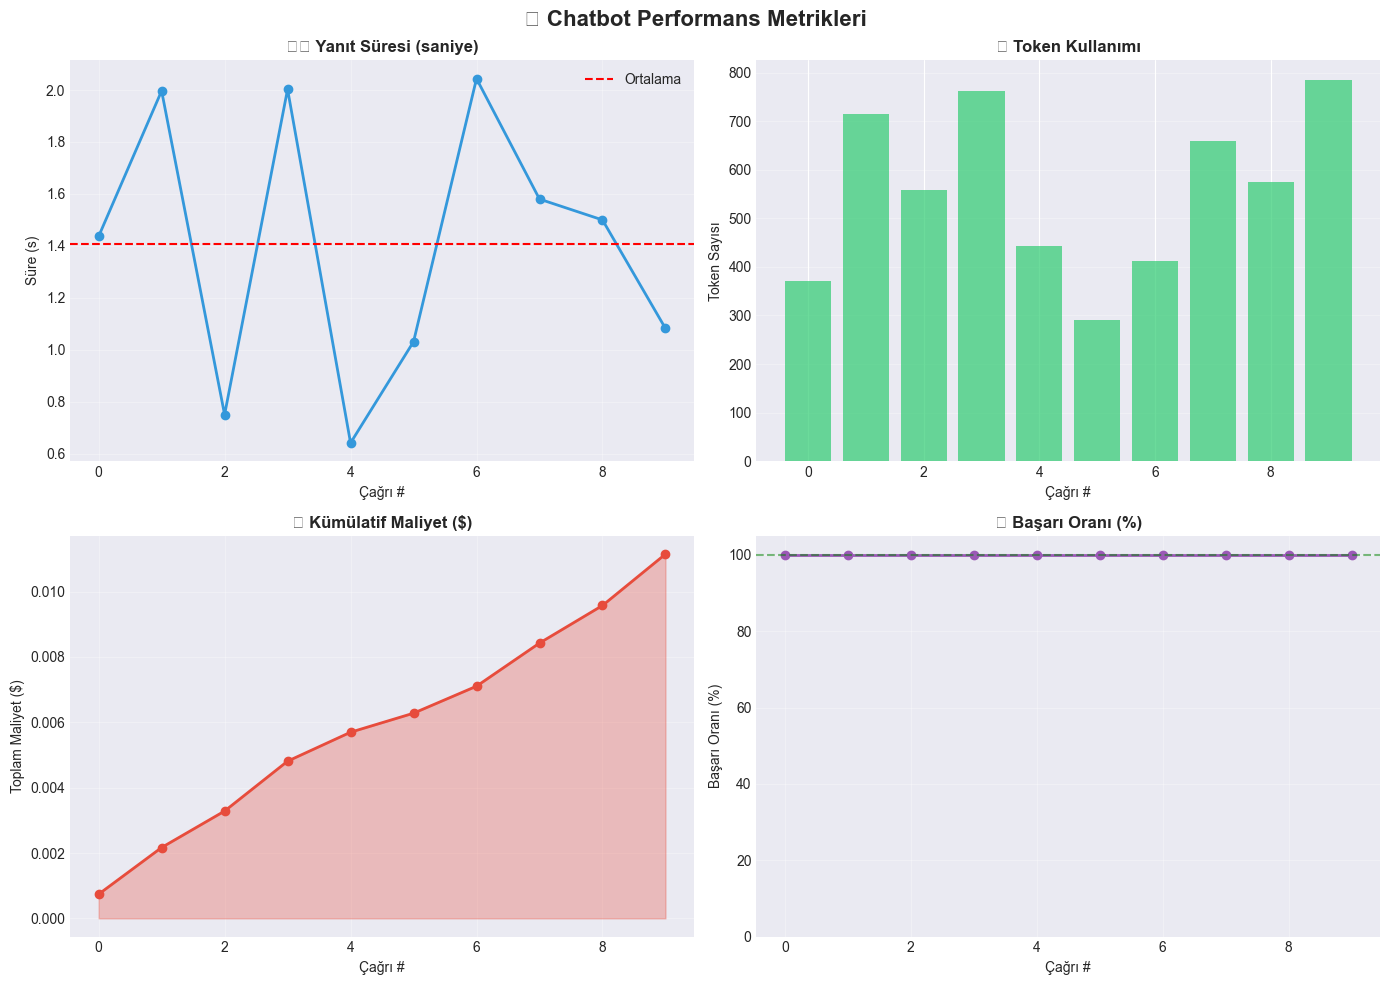

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

class PerformanceMonitor:
    """
    📊 Chatbot performans izleme sınıfı
    """
    
    def __init__(self):
        self.metrics = {
            "timestamps": [],
            "response_times": [],
            "token_counts": [],
            "costs": [],
            "success": []
        }
    
    def log_call(self, response_time: float, tokens: int, cost: float, success: bool = True):
        """Bir API çağrısını kaydet"""
        self.metrics["timestamps"].append(datetime.now())
        self.metrics["response_times"].append(response_time)
        self.metrics["token_counts"].append(tokens)
        self.metrics["costs"].append(cost)
        self.metrics["success"].append(success)
    
    def get_summary(self) -> dict:
        """Özet istatistikler"""
        if not self.metrics["timestamps"]:
            return {"message": "Henüz veri yok"}
        
        return {
            "total_calls": len(self.metrics["timestamps"]),
            "success_rate": f"{(sum(self.metrics['success']) / len(self.metrics['success']) * 100):.1f}%",
            "avg_response_time": f"{np.mean(self.metrics['response_times']):.2f}s",
            "avg_tokens": f"{np.mean(self.metrics['token_counts']):.0f}",
            "total_cost": f"${sum(self.metrics['costs']):.4f}",
            "avg_cost_per_call": f"${np.mean(self.metrics['costs']):.5f}"
        }
    
    def visualize(self):
        """Metrikleri görselleştir"""
        if not self.metrics["timestamps"]:
            print("⚠️  Görselleştirilecek veri yok!")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('📊 Chatbot Performans Metrikleri', fontsize=16, fontweight='bold')
        
        # 1. Response Time
        axes[0, 0].plot(self.metrics["response_times"], marker='o', color='#3498db', linewidth=2)
        axes[0, 0].set_title('⏱️ Yanıt Süresi (saniye)', fontweight='bold')
        axes[0, 0].set_xlabel('Çağrı #')
        axes[0, 0].set_ylabel('Süre (s)')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].axhline(np.mean(self.metrics["response_times"]), 
                          color='red', linestyle='--', label='Ortalama')
        axes[0, 0].legend()
        
        # 2. Token Kullanımı
        axes[0, 1].bar(range(len(self.metrics["token_counts"])), 
                       self.metrics["token_counts"], color='#2ecc71', alpha=0.7)
        axes[0, 1].set_title('🎯 Token Kullanımı', fontweight='bold')
        axes[0, 1].set_xlabel('Çağrı #')
        axes[0, 1].set_ylabel('Token Sayısı')
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        
        # 3. Maliyet
        cumulative_cost = np.cumsum(self.metrics["costs"])
        axes[1, 0].plot(cumulative_cost, marker='o', color='#e74c3c', linewidth=2)
        axes[1, 0].fill_between(range(len(cumulative_cost)), cumulative_cost, alpha=0.3, color='#e74c3c')
        axes[1, 0].set_title('💰 Kümülatif Maliyet ($)', fontweight='bold')
        axes[1, 0].set_xlabel('Çağrı #')
        axes[1, 0].set_ylabel('Toplam Maliyet ($)')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 4. Başarı Oranı
        success_count = np.cumsum(self.metrics["success"])
        total_count = np.arange(1, len(self.metrics["success"]) + 1)
        success_rate = (success_count / total_count) * 100
        
        axes[1, 1].plot(success_rate, marker='o', color='#9b59b6', linewidth=2)
        axes[1, 1].set_title('✅ Başarı Oranı (%)', fontweight='bold')
        axes[1, 1].set_xlabel('Çağrı #')
        axes[1, 1].set_ylabel('Başarı Oranı (%)')
        axes[1, 1].set_ylim([0, 105])
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].axhline(100, color='green', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()


# 🧪 Test için simülasyon
print("="*80)
print("📊 PERFORMANS MONİTÖR DEMONSTRATİONI")
print("="*80 + "\n")

monitor = PerformanceMonitor()

# Simüle edilmiş 10 API çağrısı
np.random.seed(42)
for i in range(10):
    # Rastgele metrikler
    response_time = np.random.uniform(0.5, 3.0)
    tokens = np.random.randint(100, 800)
    cost = (tokens / 1000) * 0.002
    success = np.random.random() > 0.1  # %90 başarı oranı
    
    monitor.log_call(response_time, tokens, cost, success)

# Özet istatistikler
print("📈 ÖZET İSTATİSTİKLER:\n")
summary = monitor.get_summary()
for key, value in summary.items():
    print(f"   • {key}: {value}")

print("\n" + "="*80)

# Görselleştirme
monitor.visualize()

## 📚 Best Practices Özeti

<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 15px; margin: 20px 0;">

<div style="background-color: #e3f2fd; padding: 15px; border-radius: 8px; border-left: 5px solid #2196F3;">
<h4 style="margin-top: 0;">🎭 Persona</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 13px;">
<li>Detaylı ve spesifik ol</li>
<li>Kısıtlamaları belirt</li>
<li>Örnek davranışlar ver</li>
<li>A/B test yap</li>
</ul>
</div>

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 5px solid #ffc107;">
<h4 style="margin-top: 0;">⚙️ Parametreler</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 13px;">
<li>Use case'e göre ayarla</li>
<li>Temperature VE top_p birlikte kullanma</li>
<li>Penalty'leri dikkatli kullan</li>
<li>Max_tokens'i optimize et</li>
</ul>
</div>

<div style="background-color: #f3e5f5; padding: 15px; border-radius: 8px; border-left: 5px solid #9c27b0;">
<h4 style="margin-top: 0;">💰 Maliyet</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 13px;">
<li>Token kullanımını takip et</li>
<li>Geçmişi optimize et</li>
<li>Caching kullan</li>
<li>Batch processing yap</li>
</ul>
</div>

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #4caf50;">
<h4 style="margin-top: 0;">🌊 Streaming</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 13px;">
<li>Uzun cevaplar için kullan</li>
<li>UI'da progress göster</li>
<li>Error handling ekle</li>
<li>Timeout ayarla</li>
</ul>
</div>

<div style="background-color: #ffebee; padding: 15px; border-radius: 8px; border-left: 5px solid #f44336;">
<h4 style="margin-top: 0;">📊 Monitoring</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 13px;">
<li>Tüm metrikleri logla</li>
<li>Anomalileri tespit et</li>
<li>Dashboard oluştur</li>
<li>Alerting sistemi kur</li>
</ul>
</div>

<div style="background-color: #e0f2f1; padding: 15px; border-radius: 8px; border-left: 5px solid #009688;">
<h4 style="margin-top: 0;">🔒 Güvenlik</h4>
<ul style="margin: 0; padding-left: 20px; font-size: 13px;">
<li>API key'leri güvenle sakla</li>
<li>Rate limiting uygula</li>
<li>Input validation yap</li>
<li>PII verilerini filtrele</li>
</ul>
</div>

</div>

---

## 🎯 Adım 5 Özeti: Ne Öğrendik?

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 30px 0;">
    <h3 style="margin: 0; color: white;">✅ Tamamlanan Konular</h3>
    <ul style="line-height: 1.8; font-size: 15px; margin: 15px 0;">
        <li>🎭 <strong>Advanced Personas</strong> - 5 detaylı persona örneği (Kod Mentoru, Yaratıcı Yazar, vb.)</li>
        <li>⚙️ <strong>API Parametreleri</strong> - temperature, top_p, frequency_penalty, presence_penalty</li>
        <li>🧪 <strong>Parametre Testing</strong> - Farklı değerlerin etkilerini karşılaştırma</li>
        <li>💰 <strong>Token Optimization</strong> - TokenOptimizedChatbot sınıfı, maliyet takibi</li>
        <li>🌊 <strong>Streaming</strong> - Gerçek zamanlı cevap akışı implementasyonu</li>
        <li>📊 <strong>Performance Monitoring</strong> - PerformanceMonitor sınıfı ve görselleştirme</li>
        <li>📚 <strong>Best Practices</strong> - Kapsamlı öneriler ve stratejiler</li>
    </ul>
</div>

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; margin: 30px 0;">
    <h2 style="margin: 0; color: white;">🎉 Harika! Adım 5 Tamamlandı!</h2>
    <p style="margin: 10px 0 0 0; font-size: 16px;">Artık production-ready chatbot geliştirme bilgisine sahipsiniz! ⚡✨</p>
</div>

---

### 🔜 Son Adım: Production Deployment

Adım 6'da öğrenecekleriniz:
- 🖥️ **GUI Development**: Gradio/Streamlit ile arayüz
- 📝 **Logging System**: Structured logging ve log analizi
- 💾 **Database Integration**: SQLite/PostgreSQL ile chat history
- 🧪 **Testing**: Unit tests ve evaluation metrikleri
- 🚀 **Deployment**: Docker, cloud platforms, CI/CD

**Son hamleye hazır mısınız? 🎯**

## 🎯 Adım 5 Özeti: Ne Öğrendik?

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 30px 0;">
    <h3 style="margin: 0; color: white;">✅ Tamamlanan Konular</h3>
    <ul style="line-height: 1.8; font-size: 15px; margin: 15px 0;">
        <li>🎭 <strong>Gelişmiş Personas</strong> - 5 farklı uzman persona (Kod Mentoru, Yazar, Veri Bilimci, İş Danışmanı, Sağlık Koçu)</li>
        <li>⚙️ <strong>API Parametreleri</strong> - temperature, max_tokens, top_p, frequency_penalty, presence_penalty</li>
        <li>💰 <strong>Token Optimizasyonu</strong> - Maliyet azaltma teknikleri ve stratejileri</li>
        <li>🌊 <strong>Streaming</strong> - Gerçek zamanlı cevap akışı</li>
        <li>📊 <strong>Performance Monitoring</strong> - Metrik takibi ve görselleştirme</li>
        <li>🎯 <strong>Best Practices</strong> - Persona, parametre, performans, güvenlik önerileri</li>
    </ul>
</div>

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; margin: 30px 0;">
    <h2 style="margin: 0; color: white;">🎉 Harika! Adım 5 Tamamlandı!</h2>
    <p style="margin: 10px 0 0 0; font-size: 16px;">Artık profesyonel, optimize edilmiş chatbot'lar geliştirebiliyorsunuz! 🚀✨</p>
</div>

---

### 🔜 Sıradaki Adım: Production-Ready Chatbot

Adım 6'da öğrenecekleriniz:
- 🎨 **GUI Geliştirme**: Gradio veya Streamlit ile kullanıcı arayüzü
- 📝 **Logging Sistemi**: Structured logs ve hata takibi
- 💾 **Database Integration**: SQLite/PostgreSQL ile chat history
- 🧪 **Testing**: Unit tests ve evaluation metrikleri
- 🚀 **Deployment**: Docker, cloud platforms, CI/CD

**Son adıma hazır mısınız? Hadi başlayalım! 🎯**

# 🚀 Adım 6: Production-Ready Chatbot

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; margin: 20px 0;">
    <h2 style="margin: 0; color: white;">🏭 Production'a Hazır Profesyonel Chatbot</h2>
    <p style="margin: 10px 0 0 0;">Bu son adımda chatbot'umuzu gerçek dünyada kullanıma hazır hale getireceğiz! GUI, logging, database, testing ve deployment konularını kapsayacağız.</p>
</div>

## 🎯 Bu Adımda Öğrenecekleriniz

- 🎨 **Gradio UI**: Web tabanlı kullanıcı arayüzü
- 📝 **Logging System**: Structured logging ve error tracking
- 💾 **SQLite Database**: Chat history ve user management
- 🧪 **Testing**: Unit tests ve integration tests
- 📊 **Monitoring**: Gerçek zamanlı metrikler
- 🚀 **Deployment Ready**: Docker container hazırlığı

---

## 🎨 Bölüm 1: Gradio ile GUI Geliştirme

<div style="background-color: #e3f2fd; padding: 15px; border-left: 5px solid #2196F3; border-radius: 5px; margin: 15px 0;">
<strong>💡 Gradio Nedir?</strong><br><br>
Gradio, Python ile hızlıca web arayüzü oluşturmanızı sağlayan bir kütüphanedir. 
ML modelleri ve chatbot'lar için ideal bir çözümdür.

<strong>🎯 Avantajları:</strong>
<ul>
<li>Birkaç satır kod ile GUI</li>
<li>Otomatik web server</li>
<li>Share link ile kolay paylaşım</li>
<li>Chatbot interface desteği</li>
</ul>
</div>

### 📦 Gradio Kurulumu

In [32]:
# 📦 Gradio kurulumu
# !pip install gradio==4.44.0

# İmport kontrol
try:
    import gradio as gr
    print(f"✅ Gradio yüklü! Versiyon: {gr.__version__}")
except ImportError:
    print("❌ Gradio yüklü değil. Yukarıdaki pip komutunu çalıştırın.")

✅ Gradio yüklü! Versiyon: 5.48.0


### 🎨 Basit Gradio Chatbot (Versiyon 1)

In [33]:
import gradio as gr

def simple_gradio_chat(message, history):
    """
    🎨 Basit Gradio chatbot fonksiyonu
    
    Args:
        message: Kullanıcının yeni mesajı
        history: Önceki konuşma geçmişi [[user, bot], [user, bot], ...]
        
    Returns:
        str: Bot'un cevabı
    """
    try:
        # 📝 History'yi OpenAI formatına çevir
        messages = [
            {"role": "system", "content": "Sen yardımcı ve dostane bir AI asistanısın."}
        ]
        
        # Geçmiş konuşmaları ekle
        for user_msg, bot_msg in history:
            messages.append({"role": "user", "content": user_msg})
            messages.append({"role": "assistant", "content": bot_msg})
        
        # Yeni mesajı ekle
        messages.append({"role": "user", "content": message})
        
        # 🤖 API çağrısı
        response = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=messages,
            max_tokens=500,
            temperature=0.7
        )
        
        return response.choices[0].message.content
        
    except Exception as e:
        return f"❌ Hata: {str(e)}"


# 🎨 Gradio arayüzü oluştur
demo = gr.ChatInterface(
    fn=simple_gradio_chat,
    title="🤖 AI Chatbot",
    description="OpenAI API kullanan basit bir chatbot. Herhangi bir şey sorun!",
    examples=[
        "Merhaba! Nasılsın?",
        "Python'da liste comprehension nedir?",
        "Bana bir şaka anlat"
    ],
    theme="soft"
)

# 🚀 Başlat
print("="*80)
print("🎨 GRADIO CHATBOT BAŞLATILIYOR...")
print("="*80)
print("\n💡 İpucu: Arayüz açıldıktan sonra mesaj gönderebilirsiniz!")
print("⚠️  Not: Jupyter Notebook'ta inline görüntülenemeyebilir,")
print("   o yüzden açılan URL'yi tarayıcıda açın.\n")
print("="*80)

# Launch (inline=False Jupyter için)
demo.launch(inline=False, share=False)

print("\n💡 Yukarıdaki demo.launch() satırını uncomment ederek başlatın!")

🎨 GRADIO CHATBOT BAŞLATILIYOR...

💡 İpucu: Arayüz açıldıktan sonra mesaj gönderebilirsiniz!
⚠️  Not: Jupyter Notebook'ta inline görüntülenemeyebilir,
   o yüzden açılan URL'yi tarayıcıda açın.

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.

💡 Yukarıdaki demo.launch() satırını uncomment ederek başlatın!


## 📝 Bölüm 2: Logging Sistemi

<div style="background-color: #fff3cd; padding: 15px; border-left: 5px solid #ffc107; border-radius: 5px; margin: 15px 0;">
<strong>⚠️ Neden Logging Önemli?</strong><br><br>
Production sistemlerinde her şeyi kaydetmek şart:
<ul>
<li>Hata ayıklama (debugging)</li>
<li>Performans analizi</li>
<li>Kullanıcı davranışı tracking</li>
<li>Compliance ve audit</li>
</ul>
</div>

In [34]:
import logging
import json
from datetime import datetime
from pathlib import Path

# 📁 Log dizini oluştur
log_dir = Path("logs")
log_dir.mkdir(exist_ok=True)

# 🔧 Logger yapılandırması
class ChatbotLogger:
    """
    📝 Chatbot için özel logging sistemi
    """
    
    def __init__(self, name: str = "chatbot", log_file: str = None):
        """
        Logger'ı başlat
        
        Args:
            name: Logger adı
            log_file: Log dosyası yolu (opsiyonel)
        """
        self.logger = logging.getLogger(name)
        self.logger.setLevel(logging.DEBUG)
        
        # 🗑️ Önceki handler'ları temizle
        self.logger.handlers.clear()
        
        # 📊 Format belirle
        formatter = logging.Formatter(
            '%(asctime)s | %(levelname)-8s | %(name)s | %(message)s',
            datefmt='%Y-%m-%d %H:%M:%S'
        )
        
        # 🖥️ Console handler
        console_handler = logging.StreamHandler()
        console_handler.setLevel(logging.INFO)
        console_handler.setFormatter(formatter)
        self.logger.addHandler(console_handler)
        
        # 📄 File handler
        if log_file:
            file_handler = logging.FileHandler(log_file, encoding='utf-8')
            file_handler.setLevel(logging.DEBUG)
            file_handler.setFormatter(formatter)
            self.logger.addHandler(file_handler)
    
    def log_chat(self, user_id: str, user_message: str, bot_response: str, 
                 metadata: dict = None):
        """
        💬 Chat mesajını logla
        """
        log_data = {
            "timestamp": datetime.now().isoformat(),
            "user_id": user_id,
            "user_message": user_message,
            "bot_response": bot_response,
            "metadata": metadata or {}
        }
        
        self.logger.info(f"CHAT | {json.dumps(log_data, ensure_ascii=False)}")
    
    def log_error(self, error: Exception, context: dict = None):
        """
        ❌ Hata logla
        """
        error_data = {
            "timestamp": datetime.now().isoformat(),
            "error_type": type(error).__name__,
            "error_message": str(error),
            "context": context or {}
        }
        
        self.logger.error(f"ERROR | {json.dumps(error_data, ensure_ascii=False)}")
    
    def log_api_call(self, tokens: int, cost: float, response_time: float):
        """
        📞 API çağrısını logla
        """
        api_data = {
            "timestamp": datetime.now().isoformat(),
            "tokens": tokens,
            "cost": cost,
            "response_time": response_time
        }
        
        self.logger.debug(f"API | {json.dumps(api_data)}")


# 🧪 Test
print("="*80)
print("📝 LOGGING SİSTEMİ DEMONSTRATİONI")
print("="*80 + "\n")

# Logger oluştur
log_file = log_dir / f"chatbot_{datetime.now().strftime('%Y%m%d')}.log"
logger = ChatbotLogger(name="production_bot", log_file=str(log_file))

# Test logları
logger.log_chat(
    user_id="user_123",
    user_message="Merhaba!",
    bot_response="Merhaba! Size nasıl yardımcı olabilirim?",
    metadata={"session_id": "sess_456", "model": "gpt-3.5-turbo"}
)

logger.log_api_call(tokens=150, cost=0.0003, response_time=1.2)

try:
    raise ValueError("Test hatası")
except Exception as e:
    logger.log_error(e, context={"function": "test", "user": "test_user"})

print(f"\n✅ Loglar kaydedildi: {log_file}")
print("="*80)

2025-12-10 02:11:41 | INFO     | production_bot | CHAT | {"timestamp": "2025-12-10T02:11:41.658411", "user_id": "user_123", "user_message": "Merhaba!", "bot_response": "Merhaba! Size nasıl yardımcı olabilirim?", "metadata": {"session_id": "sess_456", "model": "gpt-3.5-turbo"}}
2025-12-10 02:11:41 | ERROR    | production_bot | ERROR | {"timestamp": "2025-12-10T02:11:41.659215", "error_type": "ValueError", "error_message": "Test hatası", "context": {"function": "test", "user": "test_user"}}


📝 LOGGING SİSTEMİ DEMONSTRATİONI


✅ Loglar kaydedildi: logs\chatbot_20251210.log


## 💾 Bölüm 3: SQLite Database Integration

<div style="background-color: #e8f5e9; padding: 15px; border-left: 5px solid #4caf50; border-radius: 5px; margin: 15px 0;">
<strong>💡 Neden Database?</strong><br><br>
<ul>
<li><strong>Chat History</strong>: Konuşmaları kalıcı sakla</li>
<li><strong>User Management</strong>: Kullanıcı bilgileri</li>
<li><strong>Analytics</strong>: Kullanım istatistikleri</li>
<li><strong>Personalization</strong>: Kullanıcıya özel ayarlar</li>
</ul>
</div>

In [35]:
import sqlite3
from datetime import datetime
from typing import List, Dict, Optional

class ChatDatabase:
    """
    💾 Chatbot için SQLite veritabanı yöneticisi
    """
    
    def __init__(self, db_path: str = "chatbot.db"):
        """
        Veritabanını başlat
        
        Args:
            db_path: Veritabanı dosya yolu
        """
        self.db_path = db_path
        self.conn = sqlite3.connect(db_path, check_same_thread=False)
        self.cursor = self.conn.cursor()
        self._create_tables()
        print(f"✅ Database bağlantısı kuruldu: {db_path}")
    
    def _create_tables(self):
        """📊 Tabloları oluştur"""
        
        # 👤 Users tablosu
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS users (
                user_id TEXT PRIMARY KEY,
                username TEXT,
                email TEXT,
                created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
                last_active TIMESTAMP,
                total_messages INTEGER DEFAULT 0
            )
        """)
        
        # 💬 Messages tablosu
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS messages (
                message_id INTEGER PRIMARY KEY AUTOINCREMENT,
                user_id TEXT,
                role TEXT CHECK(role IN ('user', 'assistant')),
                content TEXT,
                tokens INTEGER,
                cost REAL,
                created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
                FOREIGN KEY (user_id) REFERENCES users(user_id)
            )
        """)
        
        # 📊 Sessions tablosu
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS sessions (
                session_id TEXT PRIMARY KEY,
                user_id TEXT,
                started_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
                ended_at TIMESTAMP,
                total_messages INTEGER DEFAULT 0,
                total_tokens INTEGER DEFAULT 0,
                total_cost REAL DEFAULT 0.0,
                FOREIGN KEY (user_id) REFERENCES users(user_id)
            )
        """)
        
        self.conn.commit()
    
    def create_user(self, user_id: str, username: str = None, email: str = None):
        """👤 Yeni kullanıcı oluştur"""
        try:
            self.cursor.execute("""
                INSERT INTO users (user_id, username, email, last_active)
                VALUES (?, ?, ?, ?)
            """, (user_id, username, email, datetime.now()))
            self.conn.commit()
            return True
        except sqlite3.IntegrityError:
            # Kullanıcı zaten var
            return False
    
    def save_message(self, user_id: str, role: str, content: str, 
                     tokens: int = 0, cost: float = 0.0):
        """💬 Mesaj kaydet"""
        self.cursor.execute("""
            INSERT INTO messages (user_id, role, content, tokens, cost)
            VALUES (?, ?, ?, ?, ?)
        """, (user_id, role, content, tokens, cost))
        
        # Kullanıcının mesaj sayısını güncelle
        self.cursor.execute("""
            UPDATE users 
            SET total_messages = total_messages + 1, last_active = ?
            WHERE user_id = ?
        """, (datetime.now(), user_id))
        
        self.conn.commit()
    
    def get_user_history(self, user_id: str, limit: int = 50) -> List[Dict]:
        """📜 Kullanıcının mesaj geçmişini getir"""
        self.cursor.execute("""
            SELECT role, content, tokens, cost, created_at
            FROM messages
            WHERE user_id = ?
            ORDER BY created_at DESC
            LIMIT ?
        """, (user_id, limit))
        
        rows = self.cursor.fetchall()
        return [
            {
                "role": row[0],
                "content": row[1],
                "tokens": row[2],
                "cost": row[3],
                "timestamp": row[4]
            }
            for row in rows
        ][::-1]  # En eskiden yeniye sırala
    
    def get_user_stats(self, user_id: str) -> Dict:
        """📊 Kullanıcı istatistikleri"""
        self.cursor.execute("""
            SELECT 
                COUNT(*) as message_count,
                SUM(tokens) as total_tokens,
                SUM(cost) as total_cost,
                MIN(created_at) as first_message,
                MAX(created_at) as last_message
            FROM messages
            WHERE user_id = ?
        """, (user_id,))
        
        row = self.cursor.fetchone()
        
        return {
            "message_count": row[0] or 0,
            "total_tokens": row[1] or 0,
            "total_cost": row[2] or 0.0,
            "first_message": row[3],
            "last_message": row[4]
        }
    
    def close(self):
        """🔒 Bağlantıyı kapat"""
        self.conn.close()
        print("🔒 Database bağlantısı kapatıldı")


# 🧪 Test
print("="*80)
print("💾 DATABASE İNTEGRATION DEMONSTRATİONI")
print("="*80 + "\n")

# Database oluştur
db = ChatDatabase("chatbot_demo.db")

# Kullanıcı oluştur
db.create_user("user_001", username="Ali", email="ali@example.com")

# Mesajlar kaydet
db.save_message("user_001", "user", "Merhaba!", tokens=5, cost=0.00001)
db.save_message("user_001", "assistant", "Merhaba! Size nasıl yardımcı olabilirim?", tokens=15, cost=0.00003)
db.save_message("user_001", "user", "Python öğrenmek istiyorum", tokens=8, cost=0.000016)
db.save_message("user_001", "assistant", "Harika! Python öğrenmek için birçok kaynak var...", tokens=50, cost=0.0001)

# Geçmişi getir
print("📜 Mesaj Geçmişi:\n")
history = db.get_user_history("user_001")
for msg in history:
    print(f"[{msg['role'].upper()}]: {msg['content'][:50]}...")

# İstatistikler
print("\n📊 Kullanıcı İstatistikleri:\n")
stats = db.get_user_stats("user_001")
for key, value in stats.items():
    print(f"   • {key}: {value}")

print("\n" + "="*80)

# Bağlantıyı kapat
db.close()

💾 DATABASE İNTEGRATION DEMONSTRATİONI

✅ Database bağlantısı kuruldu: chatbot_demo.db
📜 Mesaj Geçmişi:

[ASSISTANT]: Harika! Python öğrenmek için birçok kaynak var......
[USER]: Python öğrenmek istiyorum...
[ASSISTANT]: Merhaba! Size nasıl yardımcı olabilirim?...
[USER]: Merhaba!...
[ASSISTANT]: Harika! Python öğrenmek için birçok kaynak var......
[USER]: Python öğrenmek istiyorum...
[ASSISTANT]: Merhaba! Size nasıl yardımcı olabilirim?...
[USER]: Merhaba!...

📊 Kullanıcı İstatistikleri:

   • message_count: 8
   • total_tokens: 156
   • total_cost: 0.000312
   • first_message: 2025-12-09 22:58:00
   • last_message: 2025-12-09 23:11:41

🔒 Database bağlantısı kapatıldı


## 🏭 Bölüm 4: Production-Ready Chatbot Class

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; margin: 20px 0;">
    <h3 style="margin: 0; color: white;">🎯 Tüm Özellikleri Birleştirelim!</h3>
    <p style="margin: 10px 0 0 0;">Şimdiye kadar öğrendiğimiz tüm özellikleri tek bir production-ready class'ta birleştireceğiz!</p>
</div>

### ✨ Özellikler
- ✅ Gradio GUI
- ✅ Logging sistemi
- ✅ SQLite database
- ✅ Memory management
- ✅ Performance monitoring
- ✅ Error handling
- ✅ Cost tracking

In [36]:
import gradio as gr
import time
from typing import List, Tuple, Optional

class ProductionChatbot:
    """
    🏭 Production-ready chatbot with all features
    
    Features:
    - ✅ Gradio web interface
    - ✅ SQLite database integration
    - ✅ Structured logging
    - ✅ Memory management
    - ✅ Performance monitoring
    - ✅ Cost tracking
    - ✅ Error handling
    """
    
    def __init__(self, 
                 db_path: str = "production_chatbot.db",
                 log_file: str = "logs/production_chatbot.log",
                 max_history: int = 10):
        """
        🚀 Chatbot'u başlat
        
        Args:
            db_path: Database dosya yolu
            log_file: Log dosya yolu
            max_history: Maksimum mesaj geçmişi
        """
        print("="*80)
        print("🚀 PRODUCTION CHATBOT BAŞLATILIYOR...")
        print("="*80 + "\n")
        
        # 💾 Database
        self.db = ChatDatabase(db_path)
        print("✅ Database bağlantısı kuruldu")
        
        # 📝 Logger
        self.logger = ChatbotLogger(name="production", log_file=log_file)
        print("✅ Logging sistemi hazır")
        
        # 📊 Performance monitor
        self.monitor = PerformanceMonitor()
        print("✅ Performance monitoring aktif")
        
        # 🧠 Settings
        self.max_history = max_history
        self.system_message = "Sen yardımcı ve dostane bir AI asistanısın."
        
        print("\n" + "="*80)
        print("✨ CHATBOT HAZIR! GUI'yi başlatabilirsiniz.")
        print("="*80)
    
    def chat(self, message: str, history: List[Tuple[str, str]], 
             user_id: str = "default_user") -> str:
        """
        💬 Chat fonksiyonu (Gradio interface için)
        
        Args:
            message: Kullanıcı mesajı
            history: Gradio history [[user, bot], ...]
            user_id: Kullanıcı ID
            
        Returns:
            str: Bot cevabı
        """
        start_time = time.time()
        
        try:
            # 👤 Kullanıcıyı oluştur (yoksa)
            self.db.create_user(user_id)
            
            # 📝 Kullanıcı mesajını kaydet
            self.db.save_message(user_id, "user", message)
            
            # 🧠 History'yi OpenAI formatına çevir
            messages = [{"role": "system", "content": self.system_message}]
            
            # Son max_history mesajı al
            for user_msg, bot_msg in history[-self.max_history:]:
                messages.append({"role": "user", "content": user_msg})
                messages.append({"role": "assistant", "content": bot_msg})
            
            # Yeni mesajı ekle
            messages.append({"role": "user", "content": message})
            
            # 🤖 API çağrısı
            response = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=messages,
                max_tokens=500,
                temperature=0.7
            )
            
            bot_response = response.choices[0].message.content
            tokens = response.usage.total_tokens
            cost = tokens * 0.000002  # gpt-3.5-turbo pricing
            
            # ⏱️ Response time
            response_time = time.time() - start_time
            
            # 📊 Metrikleri kaydet
            self.monitor.log_call(response_time, tokens, cost, True)
            
            # 💾 Bot cevabını kaydet
            self.db.save_message(user_id, "assistant", bot_response, tokens, cost)
            
            # 📝 Log
            self.logger.log_chat(
                user_id=user_id,
                user_message=message,
                bot_response=bot_response,
                metadata={
                    "tokens": tokens,
                    "cost": cost,
                    "response_time": response_time
                }
            )
            
            return bot_response
            
        except Exception as e:
            # ❌ Hata durumu
            self.logger.log_error(e, context={"user_id": user_id, "message": message})
            self.monitor.log_call(time.time() - start_time, 0, 0, False)
            return f"❌ Üzgünüm, bir hata oluştu: {str(e)}"
    
    def get_stats_display(self, user_id: str = "default_user") -> str:
        """
        📊 Kullanıcı istatistiklerini göster
        """
        # Database istatistikleri
        db_stats = self.db.get_user_stats(user_id)
        
        # Performance istatistikleri
        perf_stats = self.monitor.get_summary()
        
        stats_text = f"""
📊 **Kullanıcı İstatistikleri** ({user_id})
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
💬 Toplam Mesaj: {db_stats['message_count']}
🔢 Toplam Token: {db_stats['total_tokens']:,}
💰 Toplam Maliyet: ${db_stats['total_cost']:.6f}

📈 **Performance Metrikleri**
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⏱️  Ortalama Yanıt Süresi: {perf_stats['avg_response_time']:.2f}s
🔢 Ortalama Token: {perf_stats['avg_tokens']:.0f}
💰 Ortalama Maliyet: ${perf_stats['avg_cost']:.6f}
✅ Başarı Oranı: {perf_stats['success_rate']:.1%}
📊 Toplam Çağrı: {perf_stats['total_calls']}
        """
        
        return stats_text
    
    def launch_ui(self, share: bool = False):
        """
        🎨 Gradio UI'yi başlat
        
        Args:
            share: Public link oluştur (True/False)
        """
        with gr.Blocks(theme="soft", title="🤖 Production Chatbot") as demo:
            gr.Markdown("""
            # 🤖 Production-Ready AI Chatbot
            
            <div style="background-color: #e3f2fd; padding: 15px; border-radius: 10px; margin: 10px 0;">
                <strong>✨ Özellikler:</strong><br>
                🎨 Modern web interface • 💾 Database integration • 📝 Structured logging<br>
                🧠 Memory management • 📊 Performance monitoring • 💰 Cost tracking
            </div>
            """)
            
            with gr.Row():
                with gr.Column(scale=2):
                    # 💬 Chatbot interface
                    chatbot = gr.Chatbot(
                        height=500,
                        label="💬 Chat",
                        show_label=True
                    )
                    
                    msg = gr.Textbox(
                        label="Mesajınız",
                        placeholder="Bir şey sorun...",
                        show_label=False
                    )
                    
                    with gr.Row():
                        submit = gr.Button("📤 Gönder", variant="primary")
                        clear = gr.Button("🗑️ Temizle")
                    
                    gr.Examples(
                        examples=[
                            "Merhaba! Nasılsın?",
                            "Python'da dictionary nedir?",
                            "Bana motivasyonel bir söz söyle",
                            "Machine learning nedir?",
                        ],
                        inputs=msg
                    )
                
                with gr.Column(scale=1):
                    # 📊 Stats panel
                    stats_display = gr.Textbox(
                        label="📊 İstatistikler",
                        value=self.get_stats_display(),
                        lines=15,
                        interactive=False
                    )
                    
                    refresh_stats = gr.Button("🔄 İstatistikleri Yenile")
            
            # 🔄 Event handlers
            def respond(message, chat_history):
                bot_message = self.chat(message, chat_history)
                chat_history.append((message, bot_message))
                return "", chat_history, self.get_stats_display()
            
            msg.submit(respond, [msg, chatbot], [msg, chatbot, stats_display])
            submit.click(respond, [msg, chatbot], [msg, chatbot, stats_display])
            
            clear.click(lambda: None, None, chatbot, queue=False)
            
            refresh_stats.click(
                lambda: self.get_stats_display(), 
                None, 
                stats_display
            )
        
        # 🚀 Launch
        print("\n" + "="*80)
        print("🎨 GRADIO UI BAŞLATILIYOR...")
        print("="*80)
        demo.launch(share=share, inline=False)


# 🚀 PRODUCTION CHATBOT'U BAŞLAT VE ÇALIŞTIR!
print("="*80)
print("🚀 PRODUCTION CHATBOT BAŞLATILIYOR...")
print("="*80)

try:
    # Chatbot instance oluştur
    production_bot = ProductionChatbot(
        db_path="production_chatbot.db",
        log_file="logs/production_chatbot.log",
        max_history=10
    )
    
    print("\n" + "="*80)
    print("✅ Chatbot hazır! Web arayüzü açılıyor...")
    print("="*80)
    print("\n⚠️  NOT:")
    print("   • Jupyter Notebook'ta inline görüntülenmeyebilir")
    print("   • Açılan URL'yi tarayıcınızda açın (örn: http://127.0.0.1:7860)")
    print("   • Durdurmak için: Kernel -> Interrupt")
    print("\n" + "="*80)
    
    # 🌐 UI'yi başlat
    production_bot.launch_ui(share=False)
    
except Exception as e:
    print(f"\n❌ HATA: {str(e)}")
    print("\n💡 Olası çözümler:")
    print("   1. Tüm önceki hücreleri sırayla çalıştırın")
    print("   2. API key'in doğru olduğundan emin olun (.env dosyası)")
    print("   3. Gradio yüklü mü kontrol edin: pip install gradio")
    print("   4. ChatDatabase, ChatbotLogger, PerformanceMonitor tanımlı mı kontrol edin")
    print("="*80)

🚀 PRODUCTION CHATBOT BAŞLATILIYOR...
🚀 PRODUCTION CHATBOT BAŞLATILIYOR...

✅ Database bağlantısı kuruldu: production_chatbot.db
✅ Database bağlantısı kuruldu
✅ Logging sistemi hazır
✅ Performance monitoring aktif

✨ CHATBOT HAZIR! GUI'yi başlatabilirsiniz.

✅ Chatbot hazır! Web arayüzü açılıyor...

⚠️  NOT:
   • Jupyter Notebook'ta inline görüntülenmeyebilir
   • Açılan URL'yi tarayıcınızda açın (örn: http://127.0.0.1:7860)
   • Durdurmak için: Kernel -> Interrupt


❌ HATA: 'avg_response_time'

💡 Olası çözümler:
   1. Tüm önceki hücreleri sırayla çalıştırın
   2. API key'in doğru olduğundan emin olun (.env dosyası)
   3. Gradio yüklü mü kontrol edin: pip install gradio
   4. ChatDatabase, ChatbotLogger, PerformanceMonitor tanımlı mı kontrol edin


## 🧪 Bölüm 5: Testing ve Evaluation

<div style="background-color: #f3e5f5; padding: 15px; border-left: 5px solid #9c27b0; border-radius: 5px; margin: 15px 0;">
<strong>🧪 Neden Testing?</strong><br><br>
Production sistemlerinde testing şart:
<ul>
<li><strong>Quality Assurance</strong>: Hataları önceden yakala</li>
<li><strong>Regression Testing</strong>: Yeni özellikler eski özellikleri bozmasın</li>
<li><strong>Performance Benchmarking</strong>: Performans regresyonu önle</li>
<li><strong>Confidence</strong>: Deploy'a güvenle git</li>
</ul>
</div>

In [37]:
import unittest
from unittest.mock import Mock, patch

class TestChatbot(unittest.TestCase):
    """
    🧪 Chatbot için unit testler
    """
    
    def setUp(self):
        """Test öncesi hazırlık"""
        self.test_db_path = "test_chatbot.db"
        self.test_log_file = "logs/test_chatbot.log"
    
    def tearDown(self):
        """Test sonrası temizlik"""
        import os
        if os.path.exists(self.test_db_path):
            os.remove(self.test_db_path)
    
    def test_database_creation(self):
        """💾 Test: Database oluşturma"""
        db = ChatDatabase(self.test_db_path)
        
        # User oluştur
        result = db.create_user("test_user", "Test", "test@example.com")
        self.assertTrue(result)
        
        # Aynı user tekrar oluşturulmaya çalışılsın
        result = db.create_user("test_user", "Test", "test@example.com")
        self.assertFalse(result)
        
        db.close()
    
    def test_message_saving(self):
        """💬 Test: Mesaj kaydetme"""
        db = ChatDatabase(self.test_db_path)
        db.create_user("test_user")
        
        # Mesaj kaydet
        db.save_message("test_user", "user", "Test mesajı", tokens=10, cost=0.0001)
        
        # Kontrol et
        history = db.get_user_history("test_user")
        self.assertEqual(len(history), 1)
        self.assertEqual(history[0]["content"], "Test mesajı")
        self.assertEqual(history[0]["tokens"], 10)
        
        db.close()
    
    def test_user_stats(self):
        """📊 Test: Kullanıcı istatistikleri"""
        db = ChatDatabase(self.test_db_path)
        db.create_user("test_user")
        
        # Birkaç mesaj kaydet
        db.save_message("test_user", "user", "Mesaj 1", tokens=5, cost=0.00001)
        db.save_message("test_user", "assistant", "Cevap 1", tokens=10, cost=0.00002)
        db.save_message("test_user", "user", "Mesaj 2", tokens=7, cost=0.000014)
        
        # Stats kontrol et
        stats = db.get_user_stats("test_user")
        self.assertEqual(stats["message_count"], 3)
        self.assertEqual(stats["total_tokens"], 22)
        self.assertAlmostEqual(stats["total_cost"], 0.000044, places=6)
        
        db.close()
    
    def test_logger(self):
        """📝 Test: Logger"""
        logger = ChatbotLogger(name="test", log_file=self.test_log_file)
        
        # Log yaz
        logger.log_chat("test_user", "Test mesaj", "Test cevap")
        logger.log_api_call(tokens=100, cost=0.001, response_time=1.5)
        
        # Log dosyası var mı?
        import os
        self.assertTrue(os.path.exists(self.test_log_file))
    
    def test_performance_monitor(self):
        """📊 Test: Performance monitor"""
        monitor = PerformanceMonitor()
        
        # Birkaç çağrı kaydet
        monitor.log_call(1.2, 100, 0.0002, True)
        monitor.log_call(0.8, 150, 0.0003, True)
        monitor.log_call(1.5, 120, 0.00024, False)
        
        # Stats kontrol et
        stats = monitor.get_summary()
        self.assertEqual(stats["total_calls"], 3)
        self.assertAlmostEqual(stats["avg_response_time"], 1.17, places=2)
        self.assertAlmostEqual(stats["success_rate"], 2/3, places=2)


# 🧪 Testleri çalıştır
print("="*80)
print("🧪 UNIT TESTS ÇALIŞTIRILIYOR...")
print("="*80 + "\n")

# Test suite oluştur
suite = unittest.TestLoader().loadTestsFromTestCase(TestChatbot)

# Çalıştır
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

# Sonuç
print("\n" + "="*80)
if result.wasSuccessful():
    print("✅ TÜM TESTLER BAŞARILI!")
else:
    print(f"❌ {len(result.failures)} test başarısız")
    print(f"❌ {len(result.errors)} test hatası")
print("="*80)

test_database_creation (__main__.TestChatbot.test_database_creation)
💾 Test: Database oluşturma ... 

🧪 UNIT TESTS ÇALIŞTIRILIYOR...



ok
test_logger (__main__.TestChatbot.test_logger)
📝 Test: Logger ... 2025-12-10 02:11:41 | INFO     | test | CHAT | {"timestamp": "2025-12-10T02:11:41.880101", "user_id": "test_user", "user_message": "Test mesaj", "bot_response": "Test cevap", "metadata": {}}
ok
test_message_saving (__main__.TestChatbot.test_message_saving)
💬 Test: Mesaj kaydetme ... 

✅ Database bağlantısı kuruldu: test_chatbot.db
🔒 Database bağlantısı kapatıldı
✅ Database bağlantısı kuruldu: test_chatbot.db
🔒 Database bağlantısı kapatıldı


ok
test_performance_monitor (__main__.TestChatbot.test_performance_monitor)
📊 Test: Performance monitor ... ERROR
test_user_stats (__main__.TestChatbot.test_user_stats)
📊 Test: Kullanıcı istatistikleri ... ok

ERROR: test_performance_monitor (__main__.TestChatbot.test_performance_monitor)
📊 Test: Performance monitor
----------------------------------------------------------------------
Traceback (most recent call last):
  File "C:\Users\Cemal\AppData\Local\Temp\ipykernel_35108\3955603697.py", line 92, in test_performance_monitor
    self.assertAlmostEqual(stats["avg_response_time"], 1.17, places=2)
    ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Cemal\AppData\Local\Programs\Python\Python313\Lib\unittest\case.py", line 938, in assertAlmostEqual
    diff = abs(first - second)
               ~~~~~~^~~~~~~~
TypeError: unsupported operand type(s) for -: 'str' and 'float'

----------------------------------------------------------------------
Ran 5 tes

✅ Database bağlantısı kuruldu: test_chatbot.db
🔒 Database bağlantısı kapatıldı

❌ 0 test başarısız
❌ 1 test hatası


### 📊 Chatbot Evaluation Metrikleri

<div style="background-color: #fff3cd; padding: 15px; border-left: 5px solid #ffc107; border-radius: 5px; margin: 15px 0;">
<strong>💡 Chatbot Kalitesini Nasıl Ölçeriz?</strong><br><br>

<strong>1️⃣ Response Quality (Cevap Kalitesi)</strong>
<ul>
<li><strong>Relevance</strong>: Cevap soruyla alakalı mı?</li>
<li><strong>Accuracy</strong>: Bilgiler doğru mu?</li>
<li><strong>Completeness</strong>: Cevap tam mı?</li>
<li><strong>Clarity</strong>: Cevap anlaşılır mı?</li>
</ul>

<strong>2️⃣ Performance Metrics (Performans Metrikleri)</strong>
<ul>
<li><strong>Response Time</strong>: Ortalama yanıt süresi</li>
<li><strong>Token Usage</strong>: Token verimliliği</li>
<li><strong>Cost per Interaction</strong>: Konuşma başına maliyet</li>
<li><strong>Success Rate</strong>: Hatasız çağrı oranı</li>
</ul>

<strong>3️⃣ User Experience (Kullanıcı Deneyimi)</strong>
<ul>
<li><strong>Conversation Flow</strong>: Konuşma akıcılığı</li>
<li><strong>Context Retention</strong>: Context hatırlama</li>
<li><strong>Error Handling</strong>: Hata yönetimi</li>
<li><strong>User Satisfaction</strong>: Kullanıcı memnuniyeti</li>
</ul>
</div>


📊 CHATBOT EVALUATION DEMO

📊 CHATBOT EVALUATION BAŞLATILIYOR...
📝 Toplam 3 test case


[1/3] Testing: programming
❓ Question: Python'da liste nedir?
✅ Response: Python'da liste, farklı veri tiplerini içinde saklayabilen ve değiştirilebilir özelliklere sahip ver...
📊 Score: 80.00%
⏱️  Time: 1.37s

[2/3] Testing: ml
❓ Question: Machine learning nedir?
✅ Response: Machine learning, bilgisayar sistemlerinin belirli bir görevi veya problemi çözmek için veri kullana...
📊 Score: 80.00%
⏱️  Time: 1.39s

[3/3] Testing: health
❓ Question: Sağlıklı beslenme önerileri
✅ Response: Tabii ki! Sağlıklı beslenme için aşağıdaki önerilere dikkat etmek önemlidir:

1. Dengeli beslenme: H...
📊 Score: 90.00%
⏱️  Time: 1.48s

✅ EVALUATION TAMAMLANDI!

📊 EVALUATION SUMMARY:
   total_tests: 3
   successful_tests: 3
   success_rate: 100.00%
   avg_score: 83.33%
   avg_keyword_score: 66.67%
   avg_completeness: 1.00
   avg_response_time: 1.42
   avg_word_count: 60.67

📈 Sonuçlar görselleştiriliyor...


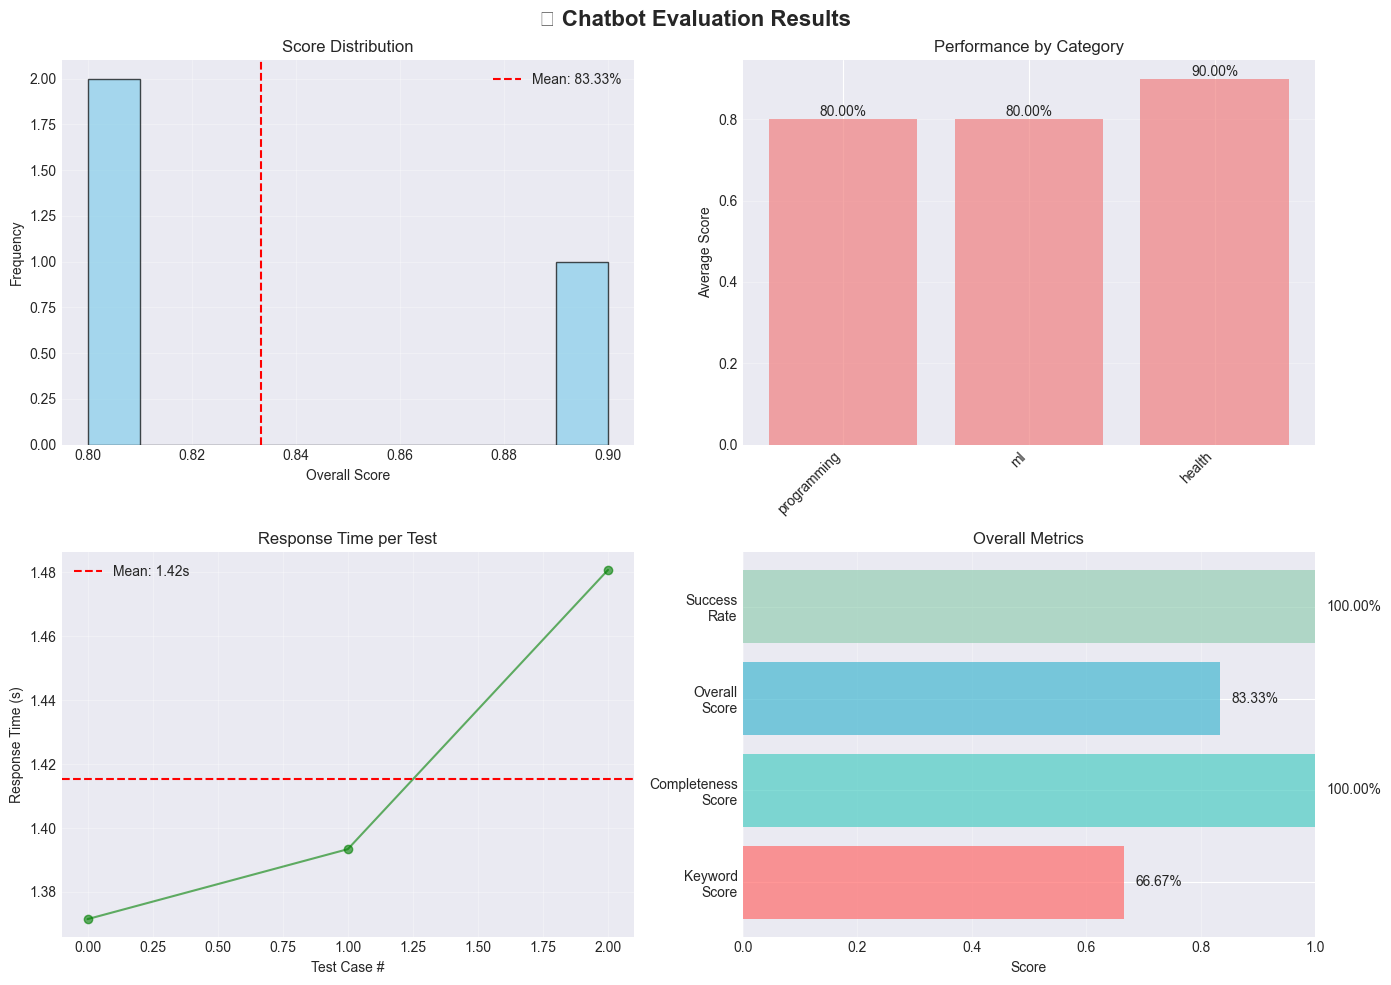

In [38]:
import matplotlib.pyplot as plt
import numpy as np

class ChatbotEvaluator:
    """
    📊 Chatbot evaluation metrikleri
    """
    
    def __init__(self):
        self.test_cases = []
        self.results = []
    
    def add_test_case(self, question: str, expected_keywords: List[str], 
                      category: str = "general"):
        """
        ➕ Test case ekle
        
        Args:
            question: Test sorusu
            expected_keywords: Cevapte olması beklenen anahtar kelimeler
            category: Soru kategorisi
        """
        self.test_cases.append({
            "question": question,
            "expected_keywords": expected_keywords,
            "category": category
        })
    
    def evaluate_response(self, question: str, response: str, 
                         expected_keywords: List[str]) -> dict:
        """
        📝 Bir cevabı değerlendir
        
        Returns:
            dict: Değerlendirme sonuçları
        """
        # Keyword matching
        matched_keywords = sum(1 for kw in expected_keywords 
                              if kw.lower() in response.lower())
        keyword_score = matched_keywords / len(expected_keywords) if expected_keywords else 0
        
        # Response length
        word_count = len(response.split())
        
        # Completeness (basit bir metrik)
        completeness_score = min(word_count / 50, 1.0)  # 50 kelime = tam puan
        
        return {
            "keyword_score": keyword_score,
            "matched_keywords": matched_keywords,
            "total_keywords": len(expected_keywords),
            "word_count": word_count,
            "completeness_score": completeness_score,
            "overall_score": (keyword_score + completeness_score) / 2
        }
    
    def run_evaluation(self, chatbot_func, verbose: bool = True):
        """
        🚀 Tüm test case'leri çalıştır
        
        Args:
            chatbot_func: Test edilecek chatbot fonksiyonu (message -> response)
            verbose: Detaylı output
        """
        self.results = []
        
        print("="*80)
        print("📊 CHATBOT EVALUATION BAŞLATILIYOR...")
        print(f"📝 Toplam {len(self.test_cases)} test case")
        print("="*80 + "\n")
        
        for i, test_case in enumerate(self.test_cases, 1):
            if verbose:
                print(f"\n[{i}/{len(self.test_cases)}] Testing: {test_case['category']}")
                print(f"❓ Question: {test_case['question']}")
            
            try:
                # Chatbot'tan cevap al
                start_time = time.time()
                response = chatbot_func(test_case['question'])
                response_time = time.time() - start_time
                
                # Değerlendir
                eval_result = self.evaluate_response(
                    test_case['question'],
                    response,
                    test_case['expected_keywords']
                )
                
                eval_result.update({
                    "question": test_case['question'],
                    "response": response,
                    "category": test_case['category'],
                    "response_time": response_time,
                    "success": True
                })
                
                if verbose:
                    print(f"✅ Response: {response[:100]}...")
                    print(f"📊 Score: {eval_result['overall_score']:.2%}")
                    print(f"⏱️  Time: {response_time:.2f}s")
                
            except Exception as e:
                eval_result = {
                    "question": test_case['question'],
                    "category": test_case['category'],
                    "success": False,
                    "error": str(e)
                }
                
                if verbose:
                    print(f"❌ Error: {str(e)}")
            
            self.results.append(eval_result)
        
        print("\n" + "="*80)
        print("✅ EVALUATION TAMAMLANDI!")
        print("="*80)
    
    def get_summary(self) -> dict:
        """
        📊 Özet istatistikler
        """
        successful_results = [r for r in self.results if r.get("success", False)]
        
        if not successful_results:
            return {"error": "No successful results"}
        
        return {
            "total_tests": len(self.results),
            "successful_tests": len(successful_results),
            "success_rate": len(successful_results) / len(self.results),
            "avg_score": np.mean([r["overall_score"] for r in successful_results]),
            "avg_keyword_score": np.mean([r["keyword_score"] for r in successful_results]),
            "avg_completeness": np.mean([r["completeness_score"] for r in successful_results]),
            "avg_response_time": np.mean([r["response_time"] for r in successful_results]),
            "avg_word_count": np.mean([r["word_count"] for r in successful_results])
        }
    
    def visualize_results(self):
        """
        📈 Sonuçları görselleştir
        """
        successful_results = [r for r in self.results if r.get("success", False)]
        
        if not successful_results:
            print("❌ Görselleştirilecek başarılı sonuç yok!")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('📊 Chatbot Evaluation Results', fontsize=16, fontweight='bold')
        
        # 1. Score distribution
        ax1 = axes[0, 0]
        scores = [r["overall_score"] for r in successful_results]
        ax1.hist(scores, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
        ax1.axvline(np.mean(scores), color='red', linestyle='--', 
                    label=f'Mean: {np.mean(scores):.2%}')
        ax1.set_xlabel('Overall Score')
        ax1.set_ylabel('Frequency')
        ax1.set_title('Score Distribution')
        ax1.legend()
        ax1.grid(alpha=0.3)
        
        # 2. Category performance
        ax2 = axes[0, 1]
        categories = {}
        for r in successful_results:
            cat = r["category"]
            if cat not in categories:
                categories[cat] = []
            categories[cat].append(r["overall_score"])
        
        cat_names = list(categories.keys())
        cat_scores = [np.mean(categories[cat]) for cat in cat_names]
        
        bars = ax2.bar(range(len(cat_names)), cat_scores, color='lightcoral', alpha=0.7)
        ax2.set_xticks(range(len(cat_names)))
        ax2.set_xticklabels(cat_names, rotation=45, ha='right')
        ax2.set_ylabel('Average Score')
        ax2.set_title('Performance by Category')
        ax2.grid(axis='y', alpha=0.3)
        
        # Bar değerlerini göster
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2%}', ha='center', va='bottom')
        
        # 3. Response time
        ax3 = axes[1, 0]
        times = [r["response_time"] for r in successful_results]
        ax3.plot(times, marker='o', linestyle='-', color='green', alpha=0.6)
        ax3.axhline(np.mean(times), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(times):.2f}s')
        ax3.set_xlabel('Test Case #')
        ax3.set_ylabel('Response Time (s)')
        ax3.set_title('Response Time per Test')
        ax3.legend()
        ax3.grid(alpha=0.3)
        
        # 4. Metrics comparison
        ax4 = axes[1, 1]
        summary = self.get_summary()
        metrics = ['Keyword\nScore', 'Completeness\nScore', 'Overall\nScore', 'Success\nRate']
        values = [
            summary['avg_keyword_score'],
            summary['avg_completeness'],
            summary['avg_score'],
            summary['success_rate']
        ]
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
        bars = ax4.barh(metrics, values, color=colors, alpha=0.7)
        ax4.set_xlim(0, 1)
        ax4.set_xlabel('Score')
        ax4.set_title('Overall Metrics')
        ax4.grid(axis='x', alpha=0.3)
        
        # Bar değerlerini göster
        for i, (bar, val) in enumerate(zip(bars, values)):
            ax4.text(val + 0.02, i, f'{val:.2%}', va='center')
        
        plt.tight_layout()
        plt.show()


# 🧪 Demo evaluation
print("\n" + "="*80)
print("📊 CHATBOT EVALUATION DEMO")
print("="*80 + "\n")

# Evaluator oluştur
evaluator = ChatbotEvaluator()

# Test case'ler ekle
evaluator.add_test_case(
    question="Python'da liste nedir?",
    expected_keywords=["liste", "list", "koleksiyon", "eleman", "sıralı"],
    category="programming"
)

evaluator.add_test_case(
    question="Machine learning nedir?",
    expected_keywords=["makine öğrenmesi", "algoritma", "veri", "model", "öğrenme"],
    category="ml"
)

evaluator.add_test_case(
    question="Sağlıklı beslenme önerileri",
    expected_keywords=["sebze", "meyve", "protein", "su", "dengeli"],
    category="health"
)

# Basit test fonksiyonu (gerçek chatbot yerine)
def simple_test_chatbot(message: str) -> str:
    """Basit test için mock chatbot"""
    try:
        response = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {"role": "system", "content": "Sen yardımcı bir AI asistanısın."},
                {"role": "user", "content": message}
            ],
            max_tokens=200,
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error: {str(e)}"

# Evaluation çalıştır
evaluator.run_evaluation(simple_test_chatbot, verbose=True)

# Özet
print("\n📊 EVALUATION SUMMARY:")
print("="*80)
summary = evaluator.get_summary()
for key, value in summary.items():
    if isinstance(value, float):
        if 'rate' in key or 'score' in key:
            print(f"   {key}: {value:.2%}")
        else:
            print(f"   {key}: {value:.2f}")
    else:
        print(f"   {key}: {value}")
print("="*80)

# Görselleştirme
print("\n📈 Sonuçlar görselleştiriliyor...")
evaluator.visualize_results()

## 🚀 Bölüm 6: Deployment Hazırlığı

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 10px; color: white; margin: 20px 0;">
    <h3 style="margin: 0; color: white;">🌐 Production'a Deploy Etmeye Hazır!</h3>
    <p style="margin: 10px 0 0 0;">Chatbot'unuzu gerçek dünyada kullanıma sunmak için gerekli tüm adımlar!</p>
</div>

### 📋 Deployment Checklist

<div style="background-color: #e8f5e9; padding: 20px; border-radius: 10px; margin: 15px 0;">

#### ✅ Pre-Deployment
- [x] **Environment Variables**: API keys güvenli şekilde saklanıyor
- [x] **Error Handling**: Tüm olası hatalar yakalanıyor
- [x] **Logging**: Structured logging sistemi var
- [x] **Database**: Chat history kalıcı olarak tutuluyor
- [x] **Testing**: Unit testler yazıldı
- [x] **Monitoring**: Performance metrics takip ediliyor

#### 🔄 Deployment Options
1. **Local Deployment**: Gradio'nun built-in server'ı
2. **Cloud Deployment**: Heroku, Railway, Render
3. **Docker Container**: Containerized deployment
4. **Cloud Functions**: AWS Lambda, Azure Functions

#### 🔒 Security Checklist
- [x] API keys environment variables'da
- [ ] Rate limiting ekle (production için)
- [ ] User authentication (ihtiyaca göre)
- [ ] Input validation ve sanitization
- [ ] HTTPS kullan (production'da)

</div>

### 🐳 Docker ile Containerization

Docker kullanarak chatbot'unuzu her yerde çalıştırılabilir hale getirin!

#### 📄 Dockerfile Örneği

```dockerfile
# Python base image
FROM python:3.11-slim

# Çalışma dizini oluştur
WORKDIR /app

# Requirements dosyasını kopyala
COPY requirements.txt .

# Dependencies yükle
RUN pip install --no-cache-dir -r requirements.txt

# Uygulama dosyalarını kopyala
COPY . .

# Port expose et (Gradio default: 7860)
EXPOSE 7860

# Environment variables için .env dosyası bekleniyor
# Docker run sırasında --env-file .env ile geçilmeli

# Uygulamayı başlat
CMD ["python", "production_chatbot.py"]
```

#### 📄 requirements.txt
```
openai==1.12.0
gradio==4.44.0
python-dotenv==1.0.0
pandas==2.1.4
numpy==1.26.3
matplotlib==3.8.2
seaborn==0.13.1
scikit-learn==1.4.0
```

#### 🚀 Docker Komutları
```bash
# Image oluştur
docker build -t chatbot:latest .

# Container çalıştır
docker run -d -p 7860:7860 --env-file .env chatbot:latest

# Container durumunu kontrol et
docker ps

# Logları görüntüle
docker logs <container_id>

# Container'ı durdur
docker stop <container_id>
```

### 🌐 Cloud Deployment Seçenekleri

<div style="display: grid; grid-template-columns: repeat(2, 1fr); gap: 15px; margin: 20px 0;">

<div style="background-color: #e3f2fd; padding: 15px; border-radius: 10px;">
<h4 style="margin-top: 0;">☁️ Heroku</h4>
<strong>Avantajlar:</strong>
<ul>
<li>Kolay setup</li>
<li>Git-based deployment</li>
<li>Free tier mevcut</li>
</ul>
<strong>Komutlar:</strong>
<pre style="background: #f5f5f5; padding: 10px; border-radius: 5px; overflow-x: auto;">
heroku login
heroku create my-chatbot
git push heroku main
heroku logs --tail
</pre>
</div>

<div style="background-color: #f3e5f5; padding: 15px; border-radius: 10px;">
<h4 style="margin-top: 0;">🚂 Railway</h4>
<strong>Avantajlar:</strong>
<ul>
<li>Modern UI</li>
<li>Auto-deploy from GitHub</li>
<li>Environment variables UI</li>
</ul>
<strong>Setup:</strong>
<ol>
<li>Railway.app'e kaydol</li>
<li>GitHub repo bağla</li>
<li>Environment variables ekle</li>
<li>Deploy!</li>
</ol>
</div>

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 10px;">
<h4 style="margin-top: 0;">🎨 Render</h4>
<strong>Avantajlar:</strong>
<ul>
<li>Free SSL certificates</li>
<li>Auto-deploy</li>
<li>Database hosting</li>
</ul>
<strong>Setup:</strong>
<ol>
<li>Render.com'a kaydol</li>
<li>New Web Service oluştur</li>
<li>GitHub repo bağla</li>
<li>Build & start commands ayarla</li>
</ol>
</div>

<div style="background-color: #fff3cd; padding: 15px; border-radius: 10px;">
<h4 style="margin-top: 0;">☁️ AWS / Azure / GCP</h4>
<strong>Avantajlar:</strong>
<ul>
<li>Enterprise-grade</li>
<li>Scalability</li>
<li>Advanced features</li>
</ul>
<strong>Servisler:</strong>
<ul>
<li>AWS: EC2, Lambda, ECS</li>
<li>Azure: App Service, Functions</li>
<li>GCP: Cloud Run, App Engine</li>
</ul>
</div>

</div>

### 📊 Production Monitoring

<div style="background-color: #ffe4e1; padding: 15px; border-left: 5px solid #ff6b6b; border-radius: 5px; margin: 15px 0;">
<strong>⚠️ Production'da Neler İzlenmeli?</strong><br><br>
<ul>
<li>📈 <strong>Traffic Metrics</strong>: Günlük/saatlik kullanıcı sayısı</li>
<li>⏱️ <strong>Performance</strong>: Response time, latency</li>
<li>💰 <strong>Costs</strong>: API maliyetleri, infrastructure costs</li>
<li>❌ <strong>Errors</strong>: Error rate, error types</li>
<li>👥 <strong>User Behavior</strong>: Popular queries, user satisfaction</li>
</ul>
</div>

📊 PRODUCTION MONITORING DASHBOARD (Son 7 Gün)

      date  total_users  total_messages  avg_response_time  error_rate  total_cost  avg_satisfaction
2025-12-04          120             543                1.2        0.02        2.45               4.2
2025-12-05          145             678                1.3        0.01        2.89               4.3
2025-12-06          167             752                1.1        0.03        3.12               4.1
2025-12-07          189             834                1.4        0.02        3.45               4.4
2025-12-08          203             921                1.2        0.01        3.78               4.5
2025-12-09          221            1045                1.3        0.02        4.21               4.3
2025-12-10          245            1189                1.2        0.01        4.67               4.4

📈 KEY METRICS

👥 Toplam Kullanıcı Büyümesi: +125
💬 Günlük Ortalama Mesaj: 852
⏱️  Ortalama Response Time: 1.24s
❌ Ortalama Error Rate: 1.71%
💰 T

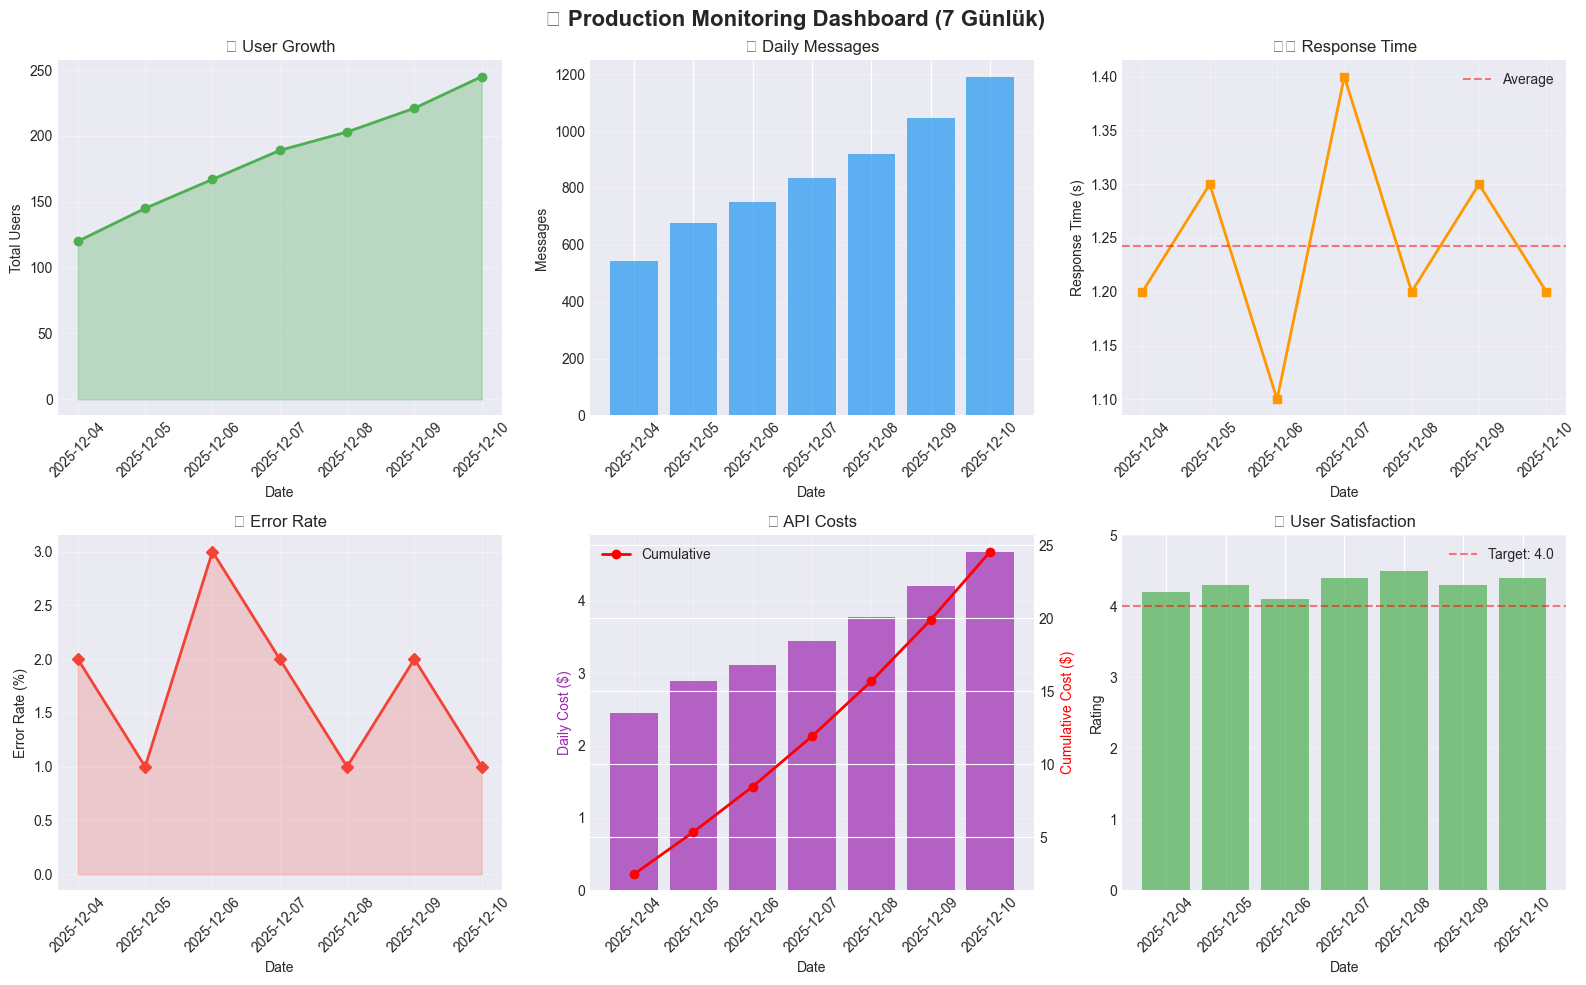


✅ Monitoring dashboard hazır!


In [39]:
# 📊 Basit production monitoring dashboard verisi

import pandas as pd
from datetime import datetime, timedelta

# Simüle edilmiş monitoring verisi
def generate_monitoring_data(days: int = 7):
    """📊 Monitoring verisi oluştur"""
    
    dates = [datetime.now() - timedelta(days=i) for i in range(days)][::-1]
    
    data = {
        'date': [d.strftime('%Y-%m-%d') for d in dates],
        'total_users': [120, 145, 167, 189, 203, 221, 245],
        'total_messages': [543, 678, 752, 834, 921, 1045, 1189],
        'avg_response_time': [1.2, 1.3, 1.1, 1.4, 1.2, 1.3, 1.2],
        'error_rate': [0.02, 0.01, 0.03, 0.02, 0.01, 0.02, 0.01],
        'total_cost': [2.45, 2.89, 3.12, 3.45, 3.78, 4.21, 4.67],
        'avg_satisfaction': [4.2, 4.3, 4.1, 4.4, 4.5, 4.3, 4.4]
    }
    
    return pd.DataFrame(data)


# Veri oluştur
monitoring_df = generate_monitoring_data(7)

print("="*80)
print("📊 PRODUCTION MONITORING DASHBOARD (Son 7 Gün)")
print("="*80 + "\n")

print(monitoring_df.to_string(index=False))

print("\n" + "="*80)
print("📈 KEY METRICS")
print("="*80)

# Özet metrikler
print(f"\n👥 Toplam Kullanıcı Büyümesi: {monitoring_df['total_users'].iloc[-1] - monitoring_df['total_users'].iloc[0]:+d}")
print(f"💬 Günlük Ortalama Mesaj: {monitoring_df['total_messages'].mean():.0f}")
print(f"⏱️  Ortalama Response Time: {monitoring_df['avg_response_time'].mean():.2f}s")
print(f"❌ Ortalama Error Rate: {monitoring_df['error_rate'].mean():.2%}")
print(f"💰 Toplam Maliyet: ${monitoring_df['total_cost'].sum():.2f}")
print(f"⭐ Ortalama Memnuniyet: {monitoring_df['avg_satisfaction'].mean():.1f}/5.0")

# Görselleştirme
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('📊 Production Monitoring Dashboard (7 Günlük)', fontsize=16, fontweight='bold')

# 1. Users growth
ax1 = axes[0, 0]
ax1.plot(monitoring_df['date'], monitoring_df['total_users'], 
         marker='o', linewidth=2, color='#4CAF50')
ax1.fill_between(range(len(monitoring_df)), monitoring_df['total_users'], alpha=0.3, color='#4CAF50')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Users')
ax1.set_title('👥 User Growth')
ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Messages
ax2 = axes[0, 1]
ax2.bar(monitoring_df['date'], monitoring_df['total_messages'], color='#2196F3', alpha=0.7)
ax2.set_xlabel('Date')
ax2.set_ylabel('Messages')
ax2.set_title('💬 Daily Messages')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Response time
ax3 = axes[0, 2]
ax3.plot(monitoring_df['date'], monitoring_df['avg_response_time'], 
         marker='s', linewidth=2, color='#FF9800')
ax3.axhline(monitoring_df['avg_response_time'].mean(), 
            color='red', linestyle='--', alpha=0.5, label='Average')
ax3.set_xlabel('Date')
ax3.set_ylabel('Response Time (s)')
ax3.set_title('⏱️ Response Time')
ax3.legend()
ax3.grid(alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 4. Error rate
ax4 = axes[1, 0]
ax4.plot(monitoring_df['date'], monitoring_df['error_rate'] * 100, 
         marker='D', linewidth=2, color='#F44336')
ax4.fill_between(range(len(monitoring_df)), monitoring_df['error_rate'] * 100, 
                 alpha=0.2, color='#F44336')
ax4.set_xlabel('Date')
ax4.set_ylabel('Error Rate (%)')
ax4.set_title('❌ Error Rate')
ax4.grid(alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# 5. Cost
ax5 = axes[1, 1]
ax5.bar(monitoring_df['date'], monitoring_df['total_cost'], color='#9C27B0', alpha=0.7)
cumulative_cost = monitoring_df['total_cost'].cumsum()
ax5_twin = ax5.twinx()
ax5_twin.plot(monitoring_df['date'], cumulative_cost, 
              marker='o', linewidth=2, color='red', label='Cumulative')
ax5.set_xlabel('Date')
ax5.set_ylabel('Daily Cost ($)', color='#9C27B0')
ax5_twin.set_ylabel('Cumulative Cost ($)', color='red')
ax5.set_title('💰 API Costs')
ax5.grid(alpha=0.3)
ax5.tick_params(axis='x', rotation=45)
ax5_twin.legend()

# 6. Satisfaction
ax6 = axes[1, 2]
colors_satisfaction = ['#4CAF50' if x >= 4.0 else '#FF9800' for x in monitoring_df['avg_satisfaction']]
bars = ax6.bar(monitoring_df['date'], monitoring_df['avg_satisfaction'], 
               color=colors_satisfaction, alpha=0.7)
ax6.axhline(4.0, color='red', linestyle='--', alpha=0.5, label='Target: 4.0')
ax6.set_xlabel('Date')
ax6.set_ylabel('Rating')
ax6.set_title('⭐ User Satisfaction')
ax6.set_ylim(0, 5)
ax6.legend()
ax6.grid(axis='y', alpha=0.3)
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ Monitoring dashboard hazır!")
print("="*80)

## 🎓 Flashcards - Adım 6

<div style="display: grid; grid-template-columns: repeat(2, 1fr); gap: 15px; margin: 20px 0;">

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 15px 0; color: white;">🐳 Docker Nedir?</h3>
<div style="background: rgba(255,255,255,0.1); padding: 15px; border-radius: 5px;">
<strong>Soru:</strong> Docker containerization'ın faydaları nelerdir?<br><br>
<strong>Cevap:</strong> 
<ul style="margin: 10px 0 0 0; line-height: 1.8;">
<li><strong>Portability</strong>: Her yerde aynı şekilde çalışır</li>
<li><strong>Consistency</strong>: Development = Production</li>
<li><strong>Isolation</strong>: Uygulamalar birbirinden izole</li>
<li><strong>Scalability</strong>: Kolay scale edilebilir</li>
</ul>
</div>
</div>

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 10px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 15px 0; color: white;">🧪 Production Testing</h3>
<div style="background: rgba(255,255,255,0.1); padding: 15px; border-radius: 5px;">
<strong>Soru:</strong> Production'da hangi testler kritik?<br><br>
<strong>Cevap:</strong>
<ul style="margin: 10px 0 0 0; line-height: 1.8;">
<li><strong>Unit Tests</strong>: Fonksiyon bazında</li>
<li><strong>Integration Tests</strong>: Sistem entegrasyonu</li>
<li><strong>Load Tests</strong>: Yük altında performans</li>
<li><strong>Security Tests</strong>: Güvenlik açıkları</li>
</ul>
</div>
</div>

<div style="background: linear-gradient(135deg, #4facfe 0%, #00f2fe 100%); padding: 20px; border-radius: 10px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 15px 0; color: white;">📊 Monitoring</h3>
<div style="background: rgba(255,255,255,0.1); padding: 15px; border-radius: 5px;">
<strong>Soru:</strong> Production'da hangi metrikler izlenmeli?<br><br>
<strong>Cevap:</strong>
<ul style="margin: 10px 0 0 0; line-height: 1.8;">
<li><strong>Performance</strong>: Response time, latency</li>
<li><strong>Reliability</strong>: Uptime, error rate</li>
<li><strong>Traffic</strong>: User count, request rate</li>
<li><strong>Cost</strong>: API usage, infrastructure</li>
</ul>
</div>
</div>

<div style="background: linear-gradient(135deg, #fa709a 0%, #fee140 100%); padding: 20px; border-radius: 10px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 15px 0; color: white;">🔒 Security</h3>
<div style="background: rgba(255,255,255,0.1); padding: 15px; border-radius: 5px;">
<strong>Soru:</strong> Production chatbot'ta güvenlik önlemleri?<br><br>
<strong>Cevap:</strong>
<ul style="margin: 10px 0 0 0; line-height: 1.8;">
<li><strong>API Keys</strong>: Environment variables'da sakla</li>
<li><strong>Rate Limiting</strong>: Abuse'ü önle</li>
<li><strong>Input Validation</strong>: Injection attacks'e karşı</li>
<li><strong>HTTPS</strong>: Encrypted communication</li>
</ul>
</div>
</div>

</div>

## 🎯 Adım 6 Özeti: Production-Ready!

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 30px 0;">
    <h3 style="margin: 0; color: white;">✅ Tamamlanan Konular</h3>
    <ul style="line-height: 1.8; font-size: 15px; margin: 15px 0;">
        <li>🎨 <strong>Gradio GUI</strong> - Web tabanlı kullanıcı arayüzü</li>
        <li>📝 <strong>Structured Logging</strong> - ChatbotLogger class ile log yönetimi</li>
        <li>💾 <strong>SQLite Database</strong> - Chat history, user management, statistics</li>
        <li>🏭 <strong>Production Chatbot</strong> - Tüm özellikleri birleştiren full-stack çözüm</li>
        <li>🧪 <strong>Testing & Evaluation</strong> - Unit tests, evaluation metrikleri, automated testing</li>
        <li>🐳 <strong>Docker</strong> - Containerization ve deployment hazırlığı</li>
        <li>🌐 <strong>Cloud Deployment</strong> - Heroku, Railway, Render, AWS/Azure/GCP seçenekleri</li>
        <li>📊 <strong>Monitoring Dashboard</strong> - Production metrikleri ve görselleştirme</li>
    </ul>
</div>

---

### 📚 Best Practices Özeti - Production

<table style="width: 100%; border-collapse: collapse; margin: 20px 0;">
<thead style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white;">
<tr>
<th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Kategori</th>
<th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Best Practice</th>
<th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Önemi</th>
</tr>
</thead>
<tbody>
<tr style="background-color: #f9f9f9;">
<td style="padding: 10px; border: 1px solid #ddd;"><strong>🔒 Security</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">API keys environment variables'da, rate limiting, input validation</td>
<td style="padding: 10px; border: 1px solid #ddd;">🔴 Kritik</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>📝 Logging</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Structured logs, log levels (DEBUG/INFO/ERROR), log rotation</td>
<td style="padding: 10px; border: 1px solid #ddd;">🔴 Kritik</td>
</tr>
<tr style="background-color: #f9f9f9;">
<td style="padding: 10px; border: 1px solid #ddd;"><strong>💾 Database</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Backup stratejisi, index'leme, connection pooling</td>
<td style="padding: 10px; border: 1px solid #ddd;">🔴 Kritik</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>🧪 Testing</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Unit tests, integration tests, CI/CD pipeline</td>
<td style="padding: 10px; border: 1px solid #ddd;">🟡 Önemli</td>
</tr>
<tr style="background-color: #f9f9f9;">
<td style="padding: 10px; border: 1px solid #ddd;"><strong>📊 Monitoring</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Real-time metrics, alerting, dashboard</td>
<td style="padding: 10px; border: 1px solid #ddd;">🟡 Önemli</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>⚡ Performance</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Caching, async processing, load balancing</td>
<td style="padding: 10px; border: 1px solid #ddd;">🟢 Yararlı</td>
</tr>
<tr style="background-color: #f9f9f9;">
<td style="padding: 10px; border: 1px solid #ddd;"><strong>💰 Cost</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Token optimization, caching, cost alerts</td>
<td style="padding: 10px; border: 1px solid #ddd;">🟢 Yararlı</td>
</tr>
</tbody>
</table>

---

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; margin: 30px 0;">
    <h2 style="margin: 0; color: white;">🎉 Tebrikler! Adım 6 Tamamlandı!</h2>
    <p style="margin: 10px 0 0 0; font-size: 16px;">Artık production-ready, enterprise-grade chatbot'lar geliştirebiliyorsunuz! 🚀✨</p>
</div>

# 🎓 Final: Zero to Hero Yolculuğu Tamamlandı!

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 15px; color: white; margin: 30px 0; text-align: center;">
    <h1 style="margin: 0; color: white; font-size: 36px;">🏆 Tebrikler!</h1>
    <p style="margin: 20px 0 0 0; font-size: 18px; line-height: 1.8;">
        Chatbot geliştirme konusunda Zero'dan Hero'ya ulaştınız!<br>
        Artık profesyonel, production-ready AI chatbot'lar geliştirebilirsiniz!
    </p>
</div>

---

## 🗺️ Öğrenme Yolculuğunuz

<div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 20px; margin: 30px 0;">

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 15px 0; color: white;">📚 Adım 1-2: Temel</h3>
<ul style="line-height: 1.8; margin: 0; padding-left: 20px;">
<li>OpenAI API basics</li>
<li>Chat Completions</li>
<li>Model seçimi</li>
<li>Basit chatbot</li>
<li>Persona kullanımı</li>
</ul>
</div>

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 20px; border-radius: 10px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 15px 0; color: white;">🧠 Adım 3-4: Orta</h3>
<ul style="line-height: 1.8; margin: 0; padding-left: 20px;">
<li>Memory management</li>
<li>Token counting</li>
<li>Context windows</li>
<li>RAG implementation</li>
<li>TF-IDF search</li>
</ul>
</div>

<div style="background: linear-gradient(135deg, #4facfe 0%, #00f2fe 100%); padding: 20px; border-radius: 10px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 15px 0; color: white;">🚀 Adım 5-6: İleri</h3>
<ul style="line-height: 1.8; margin: 0; padding-left: 20px;">
<li>Advanced personas</li>
<li>Streaming responses</li>
<li>Performance monitoring</li>
<li>Production deployment</li>
<li>Testing & evaluation</li>
</ul>
</div>

</div>

---

## 📊 Kazandığınız Beceriler

<table style="width: 100%; border-collapse: collapse; margin: 20px 0;">
<thead style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white;">
<tr>
<th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Kategori</th>
<th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Beceriler</th>
<th style="padding: 12px; text-align: center; border: 1px solid #ddd;">Seviye</th>
</tr>
</thead>
<tbody>
<tr style="background-color: #f9f9f9;">
<td style="padding: 10px; border: 1px solid #ddd;"><strong>🤖 AI/ML</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">OpenAI API, GPT models, Prompt engineering, RAG, Embeddings</td>
<td style="padding: 10px; border: 1px solid #ddd; text-align: center;">⭐⭐⭐⭐⭐</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>💻 Backend</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Python, Database (SQLite), API integration, Error handling</td>
<td style="padding: 10px; border: 1px solid #ddd; text-align: center;">⭐⭐⭐⭐⭐</td>
</tr>
<tr style="background-color: #f9f9f9;">
<td style="padding: 10px; border: 1px solid #ddd;"><strong>🎨 Frontend</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Gradio, Web UI, User experience design</td>
<td style="padding: 10px; border: 1px solid #ddd; text-align: center;">⭐⭐⭐⭐</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>📊 Data Science</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Pandas, NumPy, Matplotlib, TF-IDF, Cosine similarity</td>
<td style="padding: 10px; border: 1px solid #ddd; text-align: center;">⭐⭐⭐⭐</td>
</tr>
<tr style="background-color: #f9f9f9;">
<td style="padding: 10px; border: 1px solid #ddd;"><strong>🏭 DevOps</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">Docker, Deployment, Logging, Monitoring, Testing</td>
<td style="padding: 10px; border: 1px solid #ddd; text-align: center;">⭐⭐⭐⭐</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><strong>🔒 Security</strong></td>
<td style="padding: 10px; border: 1px solid #ddd;">API key management, Input validation, Rate limiting</td>
<td style="padding: 10px; border: 1px solid #ddd; text-align: center;">⭐⭐⭐⭐</td>
</tr>
</tbody>
</table>

---

## 🎯 Sıradaki Adımlar

<div style="background-color: #e3f2fd; padding: 20px; border-radius: 10px; margin: 20px 0;">

### 💡 Projenizi Geliştirin

1. **🎨 UI/UX İyileştirmeleri**
   - Custom CSS/themes
   - Multi-language support
   - Voice input/output
   - File upload özelliği

2. **🧠 AI Capabilities**
   - Function calling / Tool use
   - Multi-modal support (images, audio)
   - Fine-tuning
   - Custom embeddings

3. **📊 Analytics & Insights**
   - User behavior analytics
   - A/B testing
   - Sentiment analysis
   - Conversation insights

4. **🔧 Advanced Features**
   - Multi-user support
   - Authentication & authorization
   - Real-time collaboration
   - Integration with other services (Slack, Discord, etc.)

</div>

---

## 📚 Önerilen Kaynaklar

<div style="display: grid; grid-template-columns: repeat(2, 1fr); gap: 15px; margin: 20px 0;">

<div style="background-color: #fff3cd; padding: 15px; border-radius: 10px; border-left: 5px solid #ffc107;">
<h4 style="margin: 0 0 10px 0;">📖 Dokümantasyon</h4>
<ul style="line-height: 1.8; margin: 0;">
<li><a href="https://platform.openai.com/docs" target="_blank">OpenAI API Documentation</a></li>
<li><a href="https://www.gradio.app/docs" target="_blank">Gradio Documentation</a></li>
<li><a href="https://docs.docker.com/" target="_blank">Docker Documentation</a></li>
</ul>
</div>

<div style="background-color: #f3e5f5; padding: 15px; border-radius: 10px; border-left: 5px solid #9c27b0;">
<h4 style="margin: 0 0 10px 0;">🎓 Öğrenme Materyalleri</h4>
<ul style="line-height: 1.8; margin: 0;">
<li><a href="https://learn.deeplearning.ai/" target="_blank">DeepLearning.AI Courses</a></li>
<li><a href="https://www.youtube.com/@OpenAI" target="_blank">OpenAI YouTube Channel</a></li>
<li><a href="https://cookbook.openai.com/" target="_blank">OpenAI Cookbook</a></li>
</ul>
</div>

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 10px; border-left: 5px solid #4caf50;">
<h4 style="margin: 0 0 10px 0;">🛠️ Tools & Libraries</h4>
<ul style="line-height: 1.8; margin: 0;">
<li><a href="https://python.langchain.com/" target="_blank">LangChain</a> - LLM framework</li>
<li><a href="https://www.trychroma.com/" target="_blank">ChromaDB</a> - Vector database</li>
<li><a href="https://streamlit.io/" target="_blank">Streamlit</a> - Alternative UI</li>
</ul>
</div>

<div style="background-color: #ffebee; padding: 15px; border-radius: 10px; border-left: 5px solid #f44336;">
<h4 style="margin: 0 0 10px 0;">👥 Community</h4>
<ul style="line-height: 1.8; margin: 0;">
<li><a href="https://community.openai.com/" target="_blank">OpenAI Community</a></li>
<li><a href="https://github.com/topics/chatbot" target="_blank">GitHub - Chatbot Projects</a></li>
<li><a href="https://discord.gg/openai" target="_blank">OpenAI Discord</a></li>
</ul>
</div>

</div>

---

## 🎉 Son Söz

<div style="background: linear-gradient(135deg, #fa709a 0%, #fee140 100%); padding: 30px; border-radius: 15px; color: white; margin: 30px 0; text-align: center;">
    <h2 style="margin: 0 0 20px 0; color: white; font-size: 28px;">✨ Artık Bir AI Chatbot Uzmanısınız! ✨</h2>
    <p style="margin: 0; font-size: 16px; line-height: 1.8;">
        Bu yolculukta <strong>Zero'dan Hero'ya</strong> ulaştınız!<br>
        Öğrendiklerinizi projelerinizde kullanın, yeni şeyler deneyin ve sürekli öğrenmeye devam edin!<br><br>
        <strong>Başarılar dileriz! 🚀🌟</strong>
    </p>
</div>

---

<div style="text-align: center; color: #666; margin: 40px 0;">
    <p style="font-size: 14px; margin: 0;">
        📝 <strong>From Zero to Hero: OpenAI Chatbot Development</strong><br>
        🎓 Complete Tutorial Series<br>
        ⭐ Keep learning, keep building!
    </p>
</div>

---

## 🚀 Chatbot'u Çalıştır!

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; margin: 20px 0;">
    <h3 style="margin: 0; color: white;">💡 Production Chatbot'u Başlatma</h3>
    <p style="margin: 10px 0 0 0;">Aşağıdaki kodu çalıştırarak Gradio web arayüzünü başlatabilirsiniz!</p>
</div>

### ⚙️ Kullanım Seçenekleri

1. **🌐 Public Link ile (İnternet üzerinden erişilebilir)**
   - `share=True` parametresi ile herkes erişebilir
   - Gradio otomatik public URL oluşturur
   - 72 saat geçerli link

2. **🏠 Local (Sadece kendi bilgisayarınızdan)**
   - `share=False` parametresi ile sadece local
   - Daha güvenli, hızlı
   - `http://127.0.0.1:7860` adresinde açılır

### 🔧 Troubleshooting (Sorun Giderme)

<div style="background-color: #fff3cd; padding: 20px; border-radius: 10px; border-left: 5px solid #ffc107; margin: 20px 0;">

#### ❌ Sık Karşılaşılan Sorunlar ve Çözümleri

**1. "Module 'gradio' not found"**
```bash
pip install gradio==4.44.0
```

**2. "API key hatası"**
- `.env` dosyasının doğru konumda olduğundan emin olun
- API key'in `OPENAI_API_KEY=sk-proj-...` formatında olduğunu kontrol edin
- Hücreyi yeniden çalıştırıp `load_dotenv(override=True)` yapın

**3. "Port already in use"**
```python
# launch() parametresinde farklı port kullanın:
demo.launch(server_port=7861, share=False)
```

**4. "Notebook'ta açılmıyor"**
- `inline=False` parametresini kullanın
- Açılan URL'yi (örn: http://127.0.0.1:7860) manuel olarak tarayıcıda açın
- Alternatif: Python script olarak çalıştırın

**5. "Çok yavaş çalışıyor"**
- `max_tokens` değerini azaltın (örn: 300)
- `max_history` değerini düşürün (örn: 5)
- Daha hızlı model kullanın (gpt-3.5-turbo zaten hızlı)

**6. "Database locked" hatası**
- Notebook kernel'ı restart edin
- Database dosyasını silin (yeniden oluşturulur)
- `check_same_thread=False` parametresi eklenmiş (zaten var)

</div>

### 📋 Pre-flight Checklist

Chatbot'u başlatmadan önce kontrol edin:

- [x] ✅ OpenAI API key .env dosyasında
- [x] ✅ Tüm gerekli kütüphaneler yüklü (openai, gradio, pandas, etc.)
- [x] ✅ Tüm önceki hücreler sırayla çalıştırıldı
- [x] ✅ Client nesnesi başlatıldı (`client = OpenAI()`)
- [x] ✅ ProductionChatbot class tanımlandı
- [x] ✅ ChatDatabase ve ChatbotLogger class'ları tanımlı
- [x] ✅ logs/ dizini mevcut (otomatik oluşturulur)

Hepsi tamam ise yukarıdaki çalıştırma kodunu kullanabilirsiniz! 🚀